# 8. Volatility Surface and Local Volatility model

In [1]:
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from matplotlib.colors import TwoSlopeNorm as two_slope_norm
from scipy.interpolate import PchipInterpolator as pchip_interpolator
from scipy.interpolate import BSpline as bspline
from scipy.linalg import LinAlgError as linear_error
from scipy.linalg import lstsq as linear_lstsq
from scipy.linalg import solve as linear_solve
from scipy.stats import norm
from sklearn.decomposition import PCA as pca_estimator
from sklearn.preprocessing import StandardScaler as standard_scaler
import jax
import jax.numpy as jnp
from IPython.display import display

from quantfinlab.dataio import load_par_yield_curve, load_spx_option_pairs
from quantfinlab.fixed_income.bootstrap import build_zero_curve_panel_from_par_yields
from quantfinlab.fixed_income.discounting import discount_factor_from_rate, map_curve_rates_to_dates_and_taus
from quantfinlab.options.bsm import black76_price
from quantfinlab.options.greeks import compute_greeks_jax
from quantfinlab.options.iv import compute_iv_table
from quantfinlab.options.parity import infer_forwards_from_paired_quotes
from quantfinlab.plotting import LAB_COLORS as lab_colors, set_plot_style
from quantfinlab.plotting.options import plot_forward_vs_spot

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
pd.set_option("display.max_columns", 120)
set_plot_style(lab_colors)
plt.rcParams["axes.prop_cycle"] = cycler(color=lab_colors)
plt.rcParams.update({"figure.figsize": (7.4, 4.2), "figure.dpi": 180, "savefig.dpi": 300})
seed = 7
rng = np.random.default_rng(seed)


In [2]:
root = Path.cwd()
if root.name.lower() == "notebooks":
    root = root.parent

data_dir = root / "data"
spx_chain_path = data_dir / "spx_options_chain.parquet"
rates_path = data_dir / "us_treasury_yields.csv"

ann_days = 365.25
k_fit_grid = np.linspace(-0.38, 0.38, 65)
tau_fit_grid = np.linspace(7.0 / ann_days, 180.0 / ann_days, 33)
k_raw_grid = np.linspace(-0.38, 0.38, 61)
tau_raw_grid = np.linspace(7.0 / ann_days, 180.0 / ann_days, 17)
k_safe_grid = np.linspace(-0.25, 0.10, 49)
tau_safe_grid = np.linspace(21.0 / ann_days, 150.0 / ann_days, 25)
k_lv_grid = np.linspace(-0.25, 0.10, 49)
tau_lv_grid = np.linspace(21.0 / ann_days, 150.0 / ann_days, 33)
k_risk_grid = np.linspace(-0.20, 0.08, 35)
tau_risk_grid = np.array([21.0, 35.0, 60.0, 90.0, 120.0, 150.0]) / ann_days
shape_k_down = -0.20
shape_k_down_hist = -0.125
shape_k_atm = 0.00
shape_k_up = 0.08


In [3]:
q_pair = load_spx_option_pairs(
    spx_chain_path,
    annualization_days=ann_days,
    max_rel_spread=0.60,
    tau_min_days=7.0,
    tau_max_days=180.0,
    k_over_s_range=(0.62, 1.62),
    top_n_per_expiry=90,
    min_pairs_per_expiry=5,
)
q_pair["dte_days"] = q_pair["tau"] * ann_days
q_pair["moneyness"] = q_pair["strike"] / q_pair["spot"]
display(q_pair[["date", "expiry", "spot", "strike", "dte_days", "c_mid", "p_mid", "c_rel_spread", "p_rel_spread"]].head(8))


,date,expiry,spot,strike,dte_days,c_mid,p_mid,c_rel_spread,p_rel_spread
0,2022-01-03,2022-01-12,"4,795.570000","4,535.000000",8.333333,258.900000,1.925000,0.023175,0.077922
1,2022-01-03,2022-01-12,"4,795.570000","4,540.000000",8.333333,256.000000,1.975000,0.024219,0.075949
2,2022-01-03,2022-01-12,"4,795.570000","4,545.000000",8.333333,251.100000,2.025000,0.024691,0.074074
3,2022-01-03,2022-01-12,"4,795.570000","4,550.000000",8.333333,246.100000,2.100000,0.025193,0.047619
4,2022-01-03,2022-01-12,"4,795.570000","4,555.000000",8.333333,239.100000,2.175000,0.076955,0.068966
5,2022-01-03,2022-01-12,"4,795.570000","4,560.000000",8.333333,236.300000,2.225000,0.026238,0.067416
6,2022-01-03,2022-01-12,"4,795.570000","4,565.000000",8.333333,228.200000,2.325000,0.070990,0.064516
7,2022-01-03,2022-01-12,"4,795.570000","4,570.000000",8.333333,226.450000,2.400000,0.026938,0.041667


In [4]:
def curve_on_tau(q, value_col, tau_values, fallback=np.nan):
    tau_values = np.asarray(tau_values, dtype=float)
    out = np.full(tau_values.shape, float(fallback), dtype=float)
    if q is None or len(q) == 0 or value_col not in q.columns or "tau" not in q.columns:
        return out
    z = q[["tau", value_col]].copy()
    z["tau"] = pd.to_numeric(z["tau"], errors="coerce")
    z[value_col] = pd.to_numeric(z[value_col], errors="coerce")
    z = z[np.isfinite(z["tau"]) & np.isfinite(z[value_col]) & (z["tau"] > 0)].copy()
    if z.empty:
        return out
    g = z.groupby("tau", as_index=False)[value_col].median().sort_values("tau")
    x = g["tau"].to_numpy(dtype=float)
    y = g[value_col].to_numpy(dtype=float)
    if len(x) == 1:
        return np.full(tau_values.shape, float(y[0]), dtype=float)
    return np.interp(tau_values, x, y, left=y[0], right=y[-1])


def rate_on_tau(q, tau_values):
    r = curve_on_tau(q, "rate", tau_values, fallback=np.nan)
    if np.isfinite(r).any():
        fill = float(np.nanmedian(r[np.isfinite(r)]))
        return np.where(np.isfinite(r), r, fill)
    return np.zeros_like(np.asarray(tau_values, dtype=float))


def carry_on_tau(q, tau_values, spot_value):
    tau_values = np.asarray(tau_values, dtype=float)
    b = curve_on_tau(q, "implied_carry", tau_values, fallback=np.nan)
    if np.isfinite(b).any():
        fill = float(np.nanmedian(b[np.isfinite(b)]))
        return np.where(np.isfinite(b), b, fill)
    if q is not None and len(q) and "forward" in q.columns:
        z = q[["tau", "forward"]].copy()
        z["tau"] = pd.to_numeric(z["tau"], errors="coerce")
        z["forward"] = pd.to_numeric(z["forward"], errors="coerce")
        z = z[np.isfinite(z["tau"]) & np.isfinite(z["forward"]) & (z["tau"] > 0) & (z["forward"] > 0)].copy()
        if not z.empty and np.isfinite(spot_value) and spot_value > 0:
            z["carry"] = np.log(z["forward"] / float(spot_value)) / z["tau"]
            b = curve_on_tau(z.rename(columns={"carry": "implied_carry"}), "implied_carry", tau_values, fallback=np.nan)
            if np.isfinite(b).any():
                fill = float(np.nanmedian(b[np.isfinite(b)]))
                return np.where(np.isfinite(b), b, fill)
    return np.zeros_like(tau_values)


def quote_support(q, k_q=(0.01, 0.99)):
    z = q[np.isfinite(q["k"]) & np.isfinite(q["tau"])].copy()
    if z.empty:
        return {"k_lo": np.nan, "k_hi": np.nan, "tau_lo": np.nan, "tau_hi": np.nan}
    return {
        "k_lo": float(z["k"].quantile(k_q[0])),
        "k_hi": float(z["k"].quantile(k_q[1])),
        "tau_lo": float(z["tau"].min()),
        "tau_hi": float(z["tau"].max()),
    }


def support_mask_from_limits(limits, k_values, tau_values):
    k_arr, tau_arr = np.broadcast_arrays(np.asarray(k_values, dtype=float), np.asarray(tau_values, dtype=float))
    return (
        np.isfinite(k_arr)
        & np.isfinite(tau_arr)
        & (k_arr >= limits["k_lo"])
        & (k_arr <= limits["k_hi"])
        & (tau_arr >= limits["tau_lo"])
        & (tau_arr <= limits["tau_hi"])
    )


def support_mask_for_grid(q, k_values, tau_values):
    limits = quote_support(q)
    kk, tt = np.meshgrid(np.asarray(k_values, dtype=float), np.asarray(tau_values, dtype=float))
    return support_mask_from_limits(limits, kk, tt)


def masked_grid(arr, mask):
    out = np.asarray(arr, dtype=float).copy()
    out[~mask] = np.nan
    return out


def robust_abs_limit(arr, mask=None, q=0.98, floor=1e-10):
    x = np.asarray(arr, dtype=float)
    if mask is not None:
        x = x[np.asarray(mask, dtype=bool)]
    x = np.abs(x[np.isfinite(x)])
    if len(x) == 0:
        return float(floor)
    lim = float(np.nanquantile(x, q))
    return lim if np.isfinite(lim) and lim > floor else float(floor)


def xlim_from_mask(x_values, mask=None, pad=0.03):
    x = np.asarray(x_values, dtype=float)
    if mask is not None:
        m = np.asarray(mask, dtype=bool)
        if m.ndim > 1:
            m = m.any(axis=0)
        x = x[m]
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None
    lo = float(np.nanmin(x))
    hi = float(np.nanmax(x))
    span = max(hi - lo, 1e-6)
    return lo - pad * span, hi + pad * span


def set_supported_xlim(ax, x_values, mask=None, pad=0.03):
    lim = xlim_from_mask(x_values, mask=mask, pad=pad)
    if lim is not None:
        ax.set_xlim(*lim)


In [5]:
par_yields = load_par_yield_curve(rates_path, source="us_treasury")
rate_curve = build_zero_curve_panel_from_par_yields(par_yields, method="pchip", as_continuous=True)
q_pair["rate"], q_pair["rate_source_date"] = map_curve_rates_to_dates_and_taus(
    rate_curve,
    dates=q_pair["date"],
    taus=q_pair["tau"],
    method="previous",
    interpolation="linear",
    return_source_dates=True,
)
q_pair["discount_factor"] = discount_factor_from_rate(q_pair["rate"], q_pair["tau"])
carry_curve = infer_forwards_from_paired_quotes(q_pair).rename(columns={"n_pairs": "fwd_pairs"})
carry_curve["fwd_ok"] = (
    np.isfinite(carry_curve["forward"])
    & (carry_curve["forward"] > 0)
    & (carry_curve["fwd_pairs"] >= 5)
)
use_cols = ["date", "expiry", "forward", "implied_carry", "fwd_pairs", "parity_error_iqr", "fwd_ok"]
q_pair = q_pair.merge(carry_curve[use_cols], on=["date", "expiry"], how="inner")
q_pair = q_pair[
    q_pair["fwd_ok"].fillna(False)
    & (q_pair["forward"] > 0)
    & (q_pair["discount_factor"] > 0)
].copy()
q_pair["k_pair"] = np.log(q_pair["strike"] / q_pair["forward"])
display(carry_curve[["date", "expiry", "tau", "spot", "rate", "forward", "implied_carry", "fwd_pairs", "parity_error_iqr"]].head(8))


,date,expiry,tau,spot,rate,forward,implied_carry,fwd_pairs,parity_error_iqr
0,2022-01-03,2022-01-12,0.022815,"4,795.570000",0.000500,"4,794.051044",-0.013885,90,0.489915
1,2022-01-03,2022-01-14,0.028291,"4,795.570000",0.000500,"4,793.923676",-0.012137,90,0.448981
2,2022-01-03,2022-01-18,0.039243,"4,795.570000",0.000500,"4,793.952334",-0.008597,90,0.801119
3,2022-01-03,2022-01-19,0.041980,"4,795.570000",0.000500,"4,793.933175",-0.008132,90,0.635388
4,2022-01-03,2022-01-21,0.047456,"4,795.570000",0.000500,"4,794.047901",-0.006689,90,0.398230
5,2022-01-03,2022-01-24,0.055670,"4,795.570000",0.000500,"4,793.848785",-0.006448,90,0.678255
6,2022-01-03,2022-01-26,0.061145,"4,795.570000",0.000500,"4,793.852258",-0.005859,90,0.751628
7,2022-01-03,2022-01-28,0.066621,"4,795.570000",0.000500,"4,793.599287",-0.006170,90,0.583023


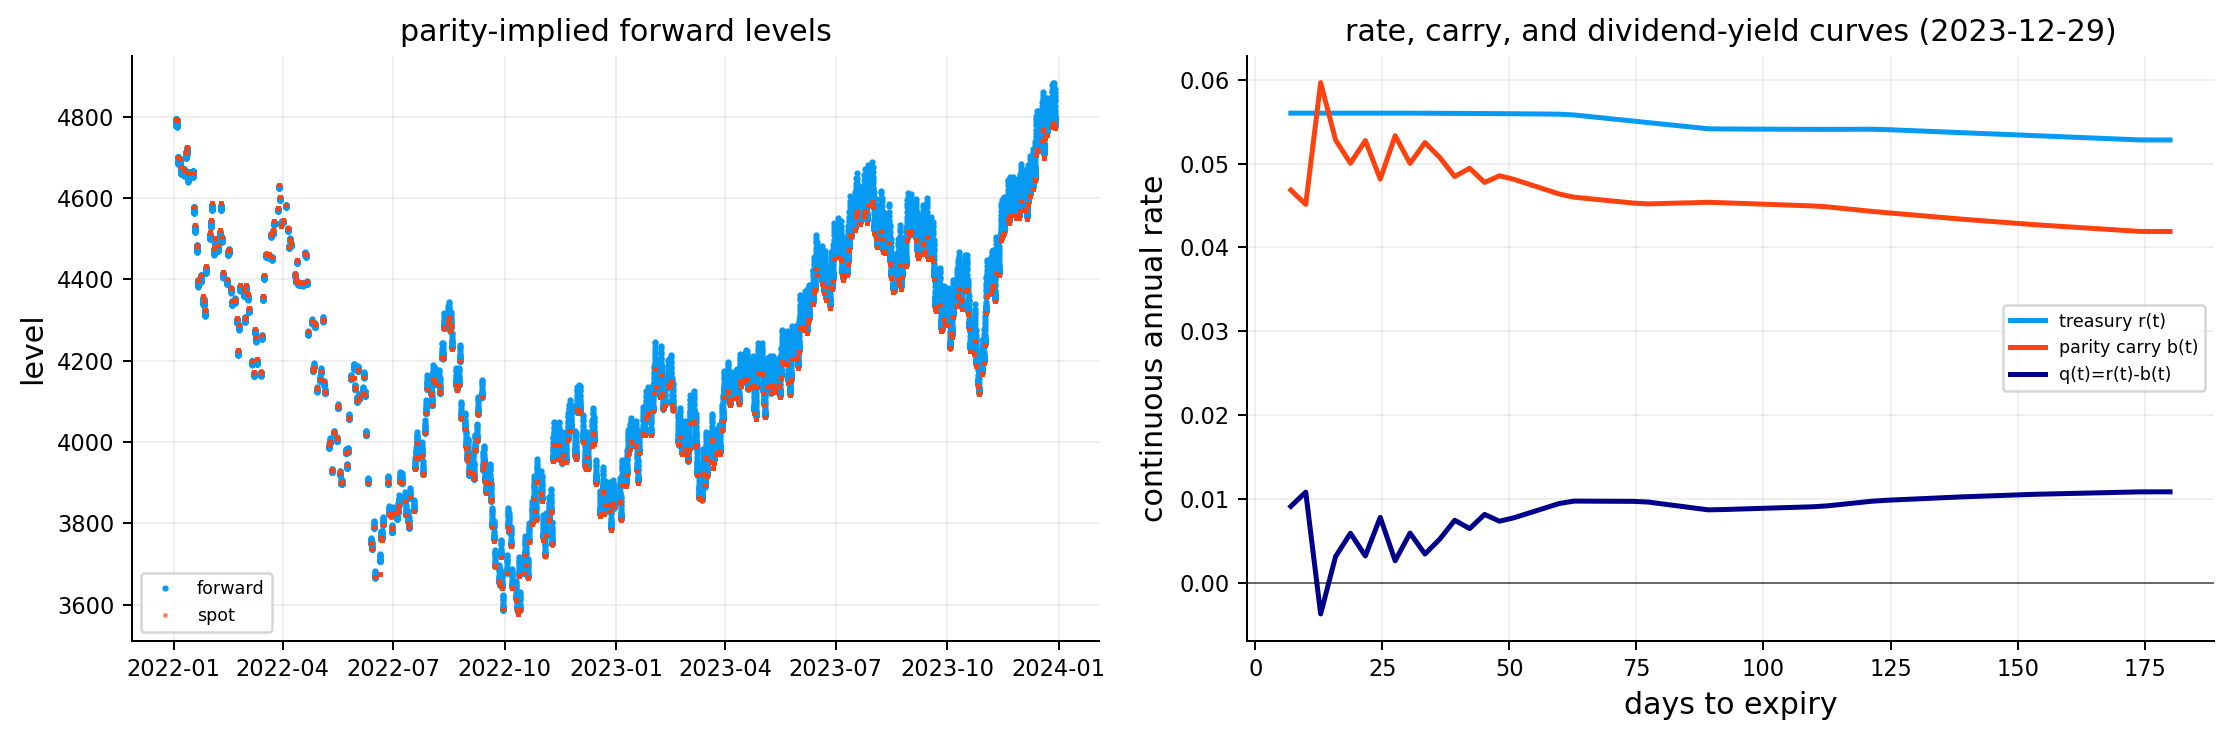

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
plot_forward_vs_spot(carry_curve[carry_curve["fwd_ok"].fillna(False)], ax=axes[0], title="parity-implied forward levels")
last_rate_date = q_pair["date"].max()
q_rate = q_pair[q_pair["date"].eq(last_rate_date)].copy()
tau_line = np.linspace(7.0 / ann_days, 180.0 / ann_days, 60)
r_line = rate_on_tau(q_rate, tau_line)
b_line = carry_on_tau(q_rate, tau_line, float(q_rate["spot"].median()))
axes[1].plot(tau_line * ann_days, r_line, lw=2.0, label="treasury r(t)")
axes[1].plot(tau_line * ann_days, b_line, lw=2.0, label="parity carry b(t)")
axes[1].plot(tau_line * ann_days, r_line - b_line, lw=2.0, label="q(t)=r(t)-b(t)")
axes[1].axhline(0.0, color="black", lw=0.8, alpha=0.55)
axes[1].set_title(f"rate, carry, and dividend-yield curves ({pd.Timestamp(last_rate_date).date()})")
axes[1].set_xlabel("days to expiry")
axes[1].set_ylabel("continuous annual rate")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()


In [7]:
base_cols = [
    "date", "timestamp", "expiry", "underlying", "spot", "strike", "tau", "dte_days",
    "rate", "rate_source_date", "discount_factor", "forward", "implied_carry",
    "fwd_pairs", "parity_error_iqr", "k_pair",
]
q_call = q_pair[base_cols + ["c_bid", "c_ask", "c_mid", "c_spread", "c_rel_spread", "c_volume"]].copy()
q_call = q_call.rename(columns={
    "c_bid": "bid", "c_ask": "ask", "c_mid": "mid", "c_spread": "spread",
    "c_rel_spread": "rel_spread", "c_volume": "volume",
})
q_call["option_type"] = "call"

q_put = q_pair[base_cols + ["p_bid", "p_ask", "p_mid", "p_spread", "p_rel_spread", "p_volume"]].copy()
q_put = q_put.rename(columns={
    "p_bid": "bid", "p_ask": "ask", "p_mid": "mid", "p_spread": "spread",
    "p_rel_spread": "rel_spread", "p_volume": "volume",
})
q_put["option_type"] = "put"

q_mkt = pd.concat([q_call, q_put], ignore_index=True)
q_mkt = q_mkt.sort_values(["date", "expiry", "strike", "option_type"]).reset_index(drop=True)
display(q_mkt[["date", "expiry", "option_type", "spot", "forward", "strike", "dte_days", "rate", "implied_carry", "mid", "bid", "ask"]].head(10))
display(pd.DataFrame([{
    "rows": len(q_mkt),
    "dates": q_mkt["date"].nunique(),
    "expiries": q_mkt["expiry"].nunique(),
    "calls": q_mkt["option_type"].eq("call").sum(),
    "puts": q_mkt["option_type"].eq("put").sum(),
    "min_dte": q_mkt["dte_days"].min(),
    "max_dte": q_mkt["dte_days"].max(),
}]))


,date,expiry,option_type,spot,forward,strike,dte_days,rate,implied_carry,mid,bid,ask
0,2022-01-03,2022-01-12,call,"4,795.570000","4,794.051044","4,535.000000",8.333333,0.000500,-0.013885,258.900000,255.900000,261.900000
1,2022-01-03,2022-01-12,put,"4,795.570000","4,794.051044","4,535.000000",8.333333,0.000500,-0.013885,1.925000,1.850000,2.000000
2,2022-01-03,2022-01-12,call,"4,795.570000","4,794.051044","4,540.000000",8.333333,0.000500,-0.013885,256.000000,252.900000,259.100000
3,2022-01-03,2022-01-12,put,"4,795.570000","4,794.051044","4,540.000000",8.333333,0.000500,-0.013885,1.975000,1.900000,2.050000
4,2022-01-03,2022-01-12,call,"4,795.570000","4,794.051044","4,545.000000",8.333333,0.000500,-0.013885,251.100000,248.000000,254.200000
5,2022-01-03,2022-01-12,put,"4,795.570000","4,794.051044","4,545.000000",8.333333,0.000500,-0.013885,2.025000,1.950000,2.100000
6,2022-01-03,2022-01-12,call,"4,795.570000","4,794.051044","4,550.000000",8.333333,0.000500,-0.013885,246.100000,243.000000,249.200000
7,2022-01-03,2022-01-12,put,"4,795.570000","4,794.051044","4,550.000000",8.333333,0.000500,-0.013885,2.100000,2.050000,2.150000
8,2022-01-03,2022-01-12,call,"4,795.570000","4,794.051044","4,555.000000",8.333333,0.000500,-0.013885,239.100000,229.900000,248.300000
9,2022-01-03,2022-01-12,put,"4,795.570000","4,794.051044","4,555.000000",8.333333,0.000500,-0.013885,2.175000,2.100000,2.250000


,rows,dates,expiries,calls,puts,min_dte,max_dte
0,2407888,505,502,1203944,1203944,7.333333,179.333333


In [8]:
tic = time.perf_counter()
iv_quotes = compute_iv_table(q_mkt, price_cols=("bid", "mid", "ask"), solver="lbr_lite", engine="auto")
iv_quotes["date"] = pd.to_datetime(iv_quotes["date"], errors="coerce").dt.normalize()
iv_quotes["expiry"] = pd.to_datetime(iv_quotes["expiry"], errors="coerce").dt.normalize()
iv_quotes["dte_days"] = iv_quotes["tau"] * ann_days
iv_quotes["k"] = np.log(iv_quotes["strike"] / iv_quotes["forward"])
iv_quotes["log_moneyness"] = iv_quotes["k"]
iv_quotes["iv_ok"] = iv_quotes.get("iv_mid_success", pd.Series(False, index=iv_quotes.index)).astype(bool)
print(f"lbr-lite iv rows: {len(iv_quotes):,}; engine={iv_quotes.attrs.get('engine_used', 'unknown')}; seconds={time.perf_counter() - tic:,.1f}")
display(iv_quotes[["date", "expiry", "option_type", "spot", "forward", "strike", "dte_days", "mid", "rate", "discount_factor", "implied_carry", "k", "iv_mid", "iv_bid", "iv_ask", "iv_ok"]].head(10))


lbr-lite iv rows: 2,407,888; engine=numba; seconds=24.4


,date,expiry,option_type,spot,forward,strike,dte_days,mid,rate,discount_factor,implied_carry,k,iv_mid,iv_bid,iv_ask,iv_ok
0,2022-01-03,2022-01-12,call,"4,795.570000","4,794.051044","4,535.000000",8.333333,258.900000,0.000500,0.999989,-0.013885,-0.055551,NaN,NaN,0.217322,False
1,2022-01-03,2022-01-12,put,"4,795.570000","4,794.051044","4,535.000000",8.333333,1.925000,0.000500,0.999989,-0.013885,-0.055551,0.201951,0.200533,0.203337,True
2,2022-01-03,2022-01-12,call,"4,795.570000","4,794.051044","4,540.000000",8.333333,256.000000,0.000500,0.999989,-0.013885,-0.054449,0.199128,NaN,0.241292,True
3,2022-01-03,2022-01-12,put,"4,795.570000","4,794.051044","4,540.000000",8.333333,1.975000,0.000500,0.999989,-0.013885,-0.054449,0.199551,0.198171,0.200900,True
4,2022-01-03,2022-01-12,call,"4,795.570000","4,794.051044","4,545.000000",8.333333,251.100000,0.000500,0.999989,-0.013885,-0.053348,0.197583,NaN,0.238556,True
5,2022-01-03,2022-01-12,put,"4,795.570000","4,794.051044","4,545.000000",8.333333,2.025000,0.000500,0.999989,-0.013885,-0.053348,0.197111,0.195768,0.198424,True
6,2022-01-03,2022-01-12,call,"4,795.570000","4,794.051044","4,550.000000",8.333333,246.100000,0.000500,0.999989,-0.013885,-0.052249,0.194229,NaN,0.234733,True
7,2022-01-03,2022-01-12,put,"4,795.570000","4,794.051044","4,550.000000",8.333333,2.100000,0.000500,0.999989,-0.013885,-0.052249,0.195061,0.194199,0.195911,True
8,2022-01-03,2022-01-12,call,"4,795.570000","4,794.051044","4,555.000000",8.333333,239.100000,0.000500,0.999989,-0.013885,-0.051150,0.118354,NaN,0.267619,True
9,2022-01-03,2022-01-12,put,"4,795.570000","4,794.051044","4,555.000000",8.333333,2.175000,0.000500,0.999989,-0.013885,-0.051150,0.192947,0.191692,0.194178,True


,rows,number_of_dates,number_of_expiries,min_tau,max_tau,min_iv,max_iv,number_of_calls,number_of_puts,missing_iv_count,missing_mid_count
0,2407888,505,502,0.020078,0.490988,0.045725,1.006858,1203944,1203944,6460,0


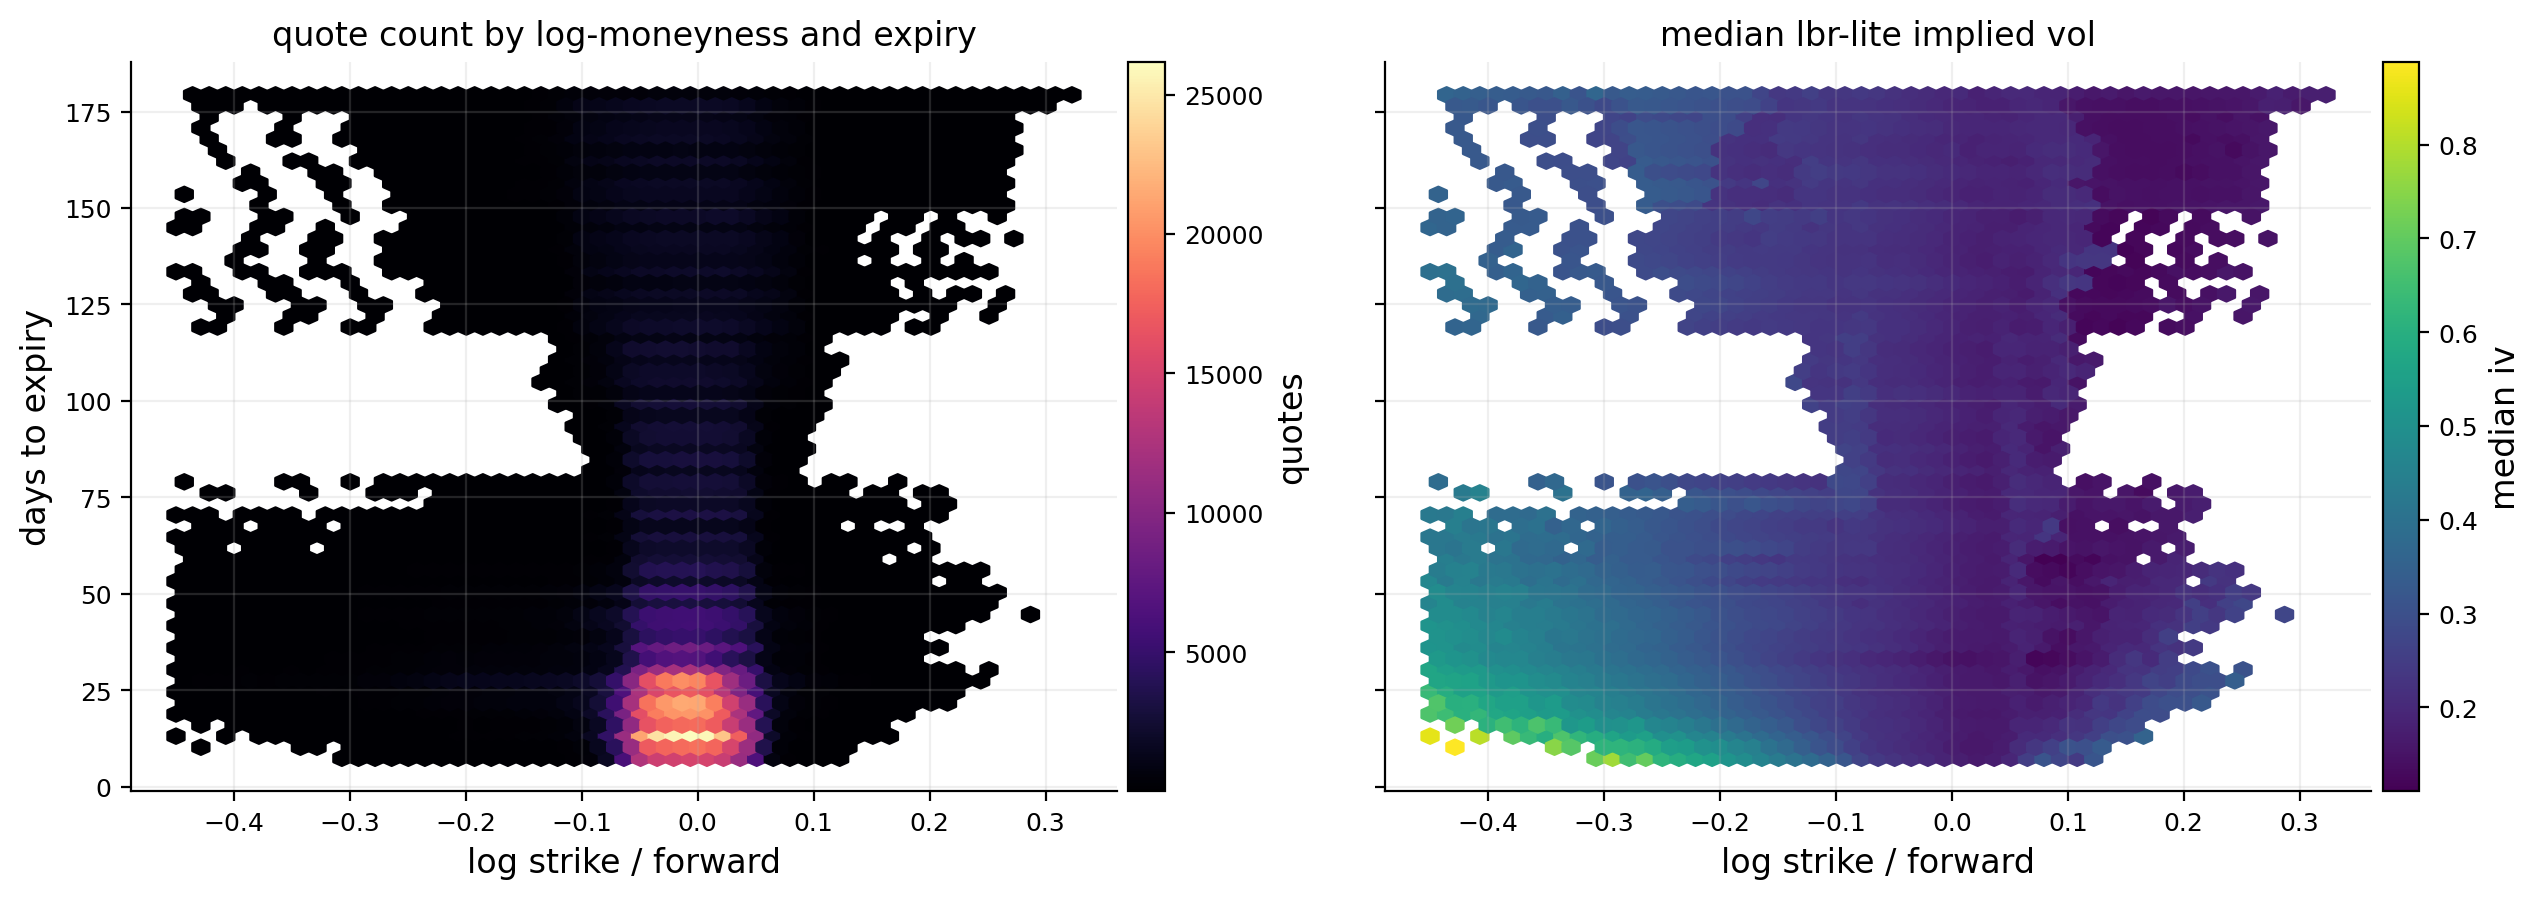

In [9]:
iv_summary = pd.DataFrame([{
    "rows": int(len(iv_quotes)),
    "number_of_dates": int(iv_quotes["date"].nunique()),
    "number_of_expiries": int(iv_quotes["expiry"].nunique()),
    "min_tau": float(np.nanmin(iv_quotes["tau"])),
    "max_tau": float(np.nanmax(iv_quotes["tau"])),
    "min_iv": float(np.nanmin(iv_quotes["iv_mid"])),
    "max_iv": float(np.nanmax(iv_quotes["iv_mid"])),
    "number_of_calls": int(iv_quotes["option_type"].eq("call").sum()),
    "number_of_puts": int(iv_quotes["option_type"].eq("put").sum()),
    "missing_iv_count": int(iv_quotes["iv_mid"].isna().sum()),
    "missing_mid_count": int(iv_quotes["mid"].isna().sum()),
}])
display(iv_summary)

z = iv_quotes[np.isfinite(iv_quotes["iv_mid"]) & np.isfinite(iv_quotes["k"])].copy()
z = z[z["k"].between(-0.45, 0.45) & z["dte_days"].between(7.0, 180.0)]
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6), sharey=True)
h0 = axes[0].hexbin(z["k"], z["dte_days"], gridsize=(54, 30), mincnt=1, cmap="magma")
axes[0].set_title("quote count by log-moneyness and expiry")
axes[0].set_xlabel("log strike / forward")
axes[0].set_ylabel("days to expiry")
fig.colorbar(h0, ax=axes[0], pad=0.01, label="quotes")
h1 = axes[1].hexbin(z["k"], z["dte_days"], C=z["iv_mid"], gridsize=(54, 30), mincnt=1, reduce_C_function=np.nanmedian, cmap="viridis")
axes[1].set_title("median lbr-lite implied vol")
axes[1].set_xlabel("log strike / forward")
fig.colorbar(h1, ax=axes[1], pad=0.01, label="median iv")
plt.tight_layout()
plt.show()


In [10]:
surface = iv_quotes.copy()
surface["relative_spread"] = pd.to_numeric(surface.get("rel_spread"), errors="coerce")
if surface["relative_spread"].notna().sum() == 0 and {"bid", "ask", "mid"}.issubset(surface.columns):
    surface["relative_spread"] = (surface["ask"] - surface["bid"]) / surface["mid"].replace(0, np.nan)

good = (
    surface["iv_ok"].fillna(False)
    & np.isfinite(surface["iv_mid"]) & surface["iv_mid"].between(0.03, 3.0)
    & np.isfinite(surface["tau"]) & surface["tau"].between(7.0 / ann_days, 180.0 / ann_days)
    & np.isfinite(surface["strike"]) & (surface["strike"] > 0)
    & np.isfinite(surface["forward"]) & (surface["forward"] > 0)
    & np.isfinite(surface["spot"]) & (surface["spot"] > 0)
    & np.isfinite(surface["rate"])
    & np.isfinite(surface["discount_factor"]) & (surface["discount_factor"] > 0)
    & np.isfinite(surface["implied_carry"])
    & np.isfinite(surface["k"]) & surface["k"].between(-0.40, 0.40)
)
if {"bid", "ask"}.issubset(surface.columns):
    good &= surface["ask"].ge(surface["bid"])
surface = surface.loc[good].copy()

if surface["relative_spread"].notna().sum() > 0:
    cap = float(np.nanquantile(surface["relative_spread"], 0.997))
    cap = max(0.75, cap) if np.isfinite(cap) else 1.0
    surface = surface[(surface["relative_spread"].isna()) | surface["relative_spread"].between(0.0, cap)].copy()

sqrt_tau = np.sqrt(surface["tau"].clip(lower=1e-8))
d1 = (-surface["k"] + 0.5 * surface["iv_mid"] ** 2 * surface["tau"]) / (surface["iv_mid"].clip(lower=1e-8) * sqrt_tau)
dollar_vega = surface["discount_factor"] * surface["forward"] * norm.pdf(d1) * sqrt_tau
if {"ask", "bid"}.issubset(surface.columns):
    price_spread = (surface["ask"] - surface["bid"]).clip(lower=0.0)
else:
    price_spread = pd.Series(np.nan, index=surface.index, dtype=float)
iv_ask = pd.to_numeric(surface["iv_ask"], errors="coerce") if "iv_ask" in surface.columns else pd.Series(np.nan, index=surface.index, dtype=float)
iv_bid = pd.to_numeric(surface["iv_bid"], errors="coerce") if "iv_bid" in surface.columns else pd.Series(np.nan, index=surface.index, dtype=float)
iv_width = (iv_ask - iv_bid).where(lambda x: np.isfinite(x) & (x > 0))
iv_width_from_price = price_spread / dollar_vega.replace(0, np.nan)
surface["iv_uncertainty"] = iv_width.combine_first(iv_width_from_price)
fallback_unc = float(np.nanmedian(surface["iv_uncertainty"])) if surface["iv_uncertainty"].notna().any() else 0.025
surface["iv_uncertainty"] = surface["iv_uncertainty"].fillna(fallback_unc).clip(lower=0.0030, upper=0.50)

spread = surface["relative_spread"].copy()
spread_med = float(np.nanmedian(spread[(spread > 0) & np.isfinite(spread)])) if spread.notna().any() else 0.08
spread = spread.fillna(spread_med).clip(lower=0.003, upper=1.0)
spread_weight = 1.0 / (spread.to_numpy(dtype=float) ** 2 + 0.02 ** 2)
spread_weight = spread_weight / max(float(np.nanmedian(spread_weight[np.isfinite(spread_weight)])), 1e-12)

info = np.asarray(dollar_vega, dtype=float)
info_med = float(np.nanmedian(info[np.isfinite(info) & (info > 0)])) if np.isfinite(info).any() else 1.0
info_weight = np.clip((info / max(info_med, 1e-12)) ** 0.45, 0.20, 3.00)
wing_weight = np.exp(-np.maximum(np.abs(surface["k"].to_numpy(dtype=float)) - 0.10, 0.0) / 0.45)
unc = surface["iv_uncertainty"].to_numpy(dtype=float)
unc_med = float(np.nanmedian(unc[np.isfinite(unc) & (unc > 0)])) if np.isfinite(unc).any() else 0.025
unc_penalty = np.clip(unc / max(unc_med, 1e-12), 0.50, 3.50) ** -0.35
raw_weight = spread_weight * info_weight * wing_weight * unc_penalty
raw_weight = raw_weight / max(float(np.nanmedian(raw_weight[np.isfinite(raw_weight)])), 1e-12)
surface["obs_weight"] = np.clip(raw_weight, 0.05, 20.0)
surface["total_var"] = (surface["iv_mid"] ** 2) * surface["tau"]

by_date = surface.groupby("date").agg(
    quotes=("iv_mid", "size"),
    expiries=("expiry", "nunique"),
    median_iv=("iv_mid", "median"),
    near_atm_quotes=("k", lambda x: int((np.abs(x) <= 0.03).sum())),
    k_min=("k", "min"),
    k_max=("k", "max"),
    k_q01=("k", lambda x: float(np.nanquantile(x, 0.01))),
    k_q99=("k", lambda x: float(np.nanquantile(x, 0.99))),
    tau_min_days=("dte_days", "min"),
    tau_max_days=("dte_days", "max"),
).sort_index()
support_by_date = surface.groupby("date").apply(lambda x: pd.Series(quote_support(x)), include_groups=False)

weight_check = pd.DataFrame({
    "relative_spread": surface["relative_spread"],
    "iv_uncertainty": surface["iv_uncertainty"],
    "dollar_vega": dollar_vega,
    "obs_weight": surface["obs_weight"],
}).describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]).T

display(surface[["date", "expiry", "option_type", "strike", "forward", "k", "dte_days", "mid", "iv_mid", "iv_uncertainty", "obs_weight"]].head(10))
display(by_date.tail(10))
display(weight_check[["mean", "std", "5%", "25%", "50%", "75%", "95%"]])


,date,expiry,option_type,strike,forward,k,dte_days,mid,iv_mid,iv_uncertainty,obs_weight
1,2022-01-03,2022-01-12,put,"4,535.000000","4,794.051044",-0.055551,8.333333,1.925000,0.201951,0.003000,0.050000
2,2022-01-03,2022-01-12,call,"4,540.000000","4,794.051044",-0.054449,8.333333,256.000000,0.199128,0.113538,0.188892
3,2022-01-03,2022-01-12,put,"4,540.000000","4,794.051044",-0.054449,8.333333,1.975000,0.199551,0.003000,0.050000
4,2022-01-03,2022-01-12,call,"4,545.000000","4,794.051044",-0.053348,8.333333,251.100000,0.197583,0.108930,0.188041
5,2022-01-03,2022-01-12,put,"4,545.000000","4,794.051044",-0.053348,8.333333,2.025000,0.197111,0.003000,0.050000
6,2022-01-03,2022-01-12,call,"4,550.000000","4,794.051044",-0.052249,8.333333,246.100000,0.194229,0.107594,0.184515
7,2022-01-03,2022-01-12,put,"4,550.000000","4,794.051044",-0.052249,8.333333,2.100000,0.195061,0.003000,0.111631
8,2022-01-03,2022-01-12,call,"4,555.000000","4,794.051044",-0.051150,8.333333,239.100000,0.118354,0.500000,0.050000
9,2022-01-03,2022-01-12,put,"4,555.000000","4,794.051044",-0.051150,8.333333,2.175000,0.192947,0.003000,0.058610
10,2022-01-03,2022-01-12,call,"4,560.000000","4,794.051044",-0.050053,8.333333,236.300000,0.190798,0.099444,0.181734


,quotes,expiries,median_iv,near_atm_quotes,k_min,k_max,k_q01,k_q99,tau_min_days,tau_max_days
date,,,,,,,,,,
2023-12-15,5602,33,0.117793,2830,-0.396095,0.131614,-0.247191,0.064509,10.333333,167.333333
2023-12-18,5714,34,0.122031,2804,-0.399781,0.159118,-0.251990,0.068842,7.333333,164.333333
2023-12-19,5699,34,0.122465,2878,-0.345387,0.154511,-0.218614,0.065679,7.333333,163.333333
2023-12-20,5692,34,0.127076,3222,-0.391662,0.133876,-0.243560,0.062371,7.333333,162.333333
2023-12-21,5694,34,0.127824,3054,-0.399806,0.124833,-0.227472,0.068553,7.333333,161.333333
2023-12-22,5611,33,0.125541,2982,-0.342236,0.122907,-0.229069,0.066547,10.333333,160.333333
2023-12-26,5714,34,0.126025,3002,-0.346455,0.152627,-0.220124,0.061898,7.333333,177.333333
2023-12-27,5578,33,0.119718,2977,-0.347443,0.116209,-0.207835,0.059050,7.333333,176.333333
2023-12-28,5585,33,0.119631,2998,-0.347791,0.116361,-0.210033,0.061260,7.333333,175.333333


,mean,std,5%,25%,50%,75%,95%
relative_spread,0.024149,0.032842,0.004937,0.008547,0.014790,0.027907,0.068966
iv_uncertainty,0.013299,0.038611,0.003000,0.003000,0.003000,0.008753,0.047721
dollar_vega,468.968141,295.245620,69.775627,243.963865,394.847417,693.288082,"1,020.166622"
obs_weight,1.066575,0.758849,0.073044,0.345511,1.000000,1.699956,2.340480


In [11]:
valid_dates = by_date[(by_date["quotes"] >= 160) & (by_date["expiries"] >= 5) & (by_date["near_atm_quotes"] >= 20)].copy()
if valid_dates.empty:
    valid_dates = by_date[(by_date["quotes"] >= 90) & (by_date["expiries"] >= 4)].copy()

main_date = pd.Timestamp(valid_dates.index.max()).normalize()
near = surface[np.abs(surface["k"]) <= 0.03].groupby("date")["iv_mid"].median().rename("near_atm_iv")
date_state = valid_dates.join(near, how="left")
high_iv_date = pd.Timestamp(date_state["near_atm_iv"].idxmax()).normalize()
low_iv_date = pd.Timestamp(date_state["near_atm_iv"].idxmin()).normalize()

chosen_rows = []
for role, date in [("main_date", main_date), ("high_iv_date", high_iv_date), ("low_iv_date", low_iv_date)]:
    row = date_state.loc[date]
    chosen_rows.append({
        "role": role,
        "date": date.date(),
        "number_of_quotes": int(row["quotes"]),
        "number_of_expiries": int(row["expiries"]),
        "median_iv": float(row["median_iv"]),
        "near_atm_median_iv": float(row["near_atm_iv"]),
        "k_range": f"{row['k_min']:.3f} to {row['k_max']:.3f}",
        "tau_range_days": f"{row['tau_min_days']:.1f} to {row['tau_max_days']:.1f}",
    })
chosen_dates = pd.DataFrame(chosen_rows)
q_main = surface[surface["date"].eq(main_date)].copy()
display(chosen_dates)


,role,date,number_of_quotes,number_of_expiries,median_iv,near_atm_median_iv,k_range,tau_range_days
0,main_date,2023-12-29,5554,33,0.117871,0.108171,-0.345 to 0.118,9.3 to 174.3
1,high_iv_date,2022-06-13,4418,25,0.302909,0.310232,-0.292 to 0.160,7.3 to 169.3
2,low_iv_date,2023-12-14,5622,33,0.116827,0.103932,-0.396 to 0.128,7.3 to 168.3


In [12]:
def weighted_by_k(q):
    g = q[["k", "iv_mid", "obs_weight"]].copy()
    g = g[np.isfinite(g["k"]) & np.isfinite(g["iv_mid"]) & np.isfinite(g["obs_weight"])].copy()
    if g.empty:
        return pd.DataFrame(columns=["k", "iv_mid"])
    g["k_round"] = g["k"].round(6)
    out = (
        g.groupby("k_round")
        .apply(lambda x: np.average(x["iv_mid"], weights=x["obs_weight"]), include_groups=False)
        .rename("iv_mid")
        .reset_index()
        .rename(columns={"k_round": "k"})
    )
    return out.sort_values("k")


def raw_pchip_grid(q, k_values, tau_values, min_k=6):
    rows = []
    used = []
    for expiry, grp in q.groupby("expiry"):
        x = weighted_by_k(grp)
        tau = float(grp["tau"].median())
        if len(x) < min_k or not np.isfinite(tau):
            continue
        xx = x["k"].to_numpy(dtype=float)
        yy = x["iv_mid"].to_numpy(dtype=float)
        ok = np.isfinite(xx) & np.isfinite(yy)
        xx, yy = xx[ok], yy[ok]
        if len(np.unique(xx)) < min_k:
            continue
        order = np.argsort(xx)
        xx, yy = xx[order], yy[order]
        fn = pchip_interpolator(xx, yy, extrapolate=False)
        row = fn(k_values)
        support = (k_values >= xx.min()) & (k_values <= xx.max())
        row[~support] = np.nan
        rows.append(row)
        used.append({"expiry": expiry, "tau": tau, "dte_days": tau * ann_days, "k_min": xx.min(), "k_max": xx.max(), "n": len(xx)})
    if not rows:
        return np.full((len(tau_values), len(k_values)), np.nan), pd.DataFrame()
    used = pd.DataFrame(used).sort_values("tau").reset_index(drop=True)
    slice_mat = np.asarray(rows, dtype=float)[used.index]
    obs_tau = used["tau"].to_numpy(dtype=float)
    out = np.full((len(tau_values), len(k_values)), np.nan)
    for j in range(len(k_values)):
        y = slice_mat[:, j]
        ok = np.isfinite(y)
        if ok.sum() >= 3:
            fn_tau = pchip_interpolator(obs_tau[ok], y[ok], extrapolate=False)
            vals = fn_tau(tau_values)
            vals[(tau_values < obs_tau[ok].min()) | (tau_values > obs_tau[ok].max())] = np.nan
            out[:, j] = vals
        elif ok.sum() == 2:
            vals = np.interp(tau_values, obs_tau[ok], y[ok], left=np.nan, right=np.nan)
            vals[(tau_values < obs_tau[ok].min()) | (tau_values > obs_tau[ok].max())] = np.nan
            out[:, j] = vals
    return out, used


raw_iv_grid, raw_slices = raw_pchip_grid(q_main, k_raw_grid, tau_raw_grid)
display(raw_slices.head())


,expiry,tau,dte_days,k_min,k_max,n
0,2024-01-08,0.025553,9.333333,-0.064375,0.033367,90
1,2024-01-09,0.028291,10.333333,-0.064423,0.045392,90
2,2024-01-10,0.031029,11.333333,-0.062363,0.055172,90
3,2024-01-11,0.033767,12.333333,-0.066332,0.049587,90
4,2024-01-12,0.036505,13.333333,-0.054234,0.050464,90


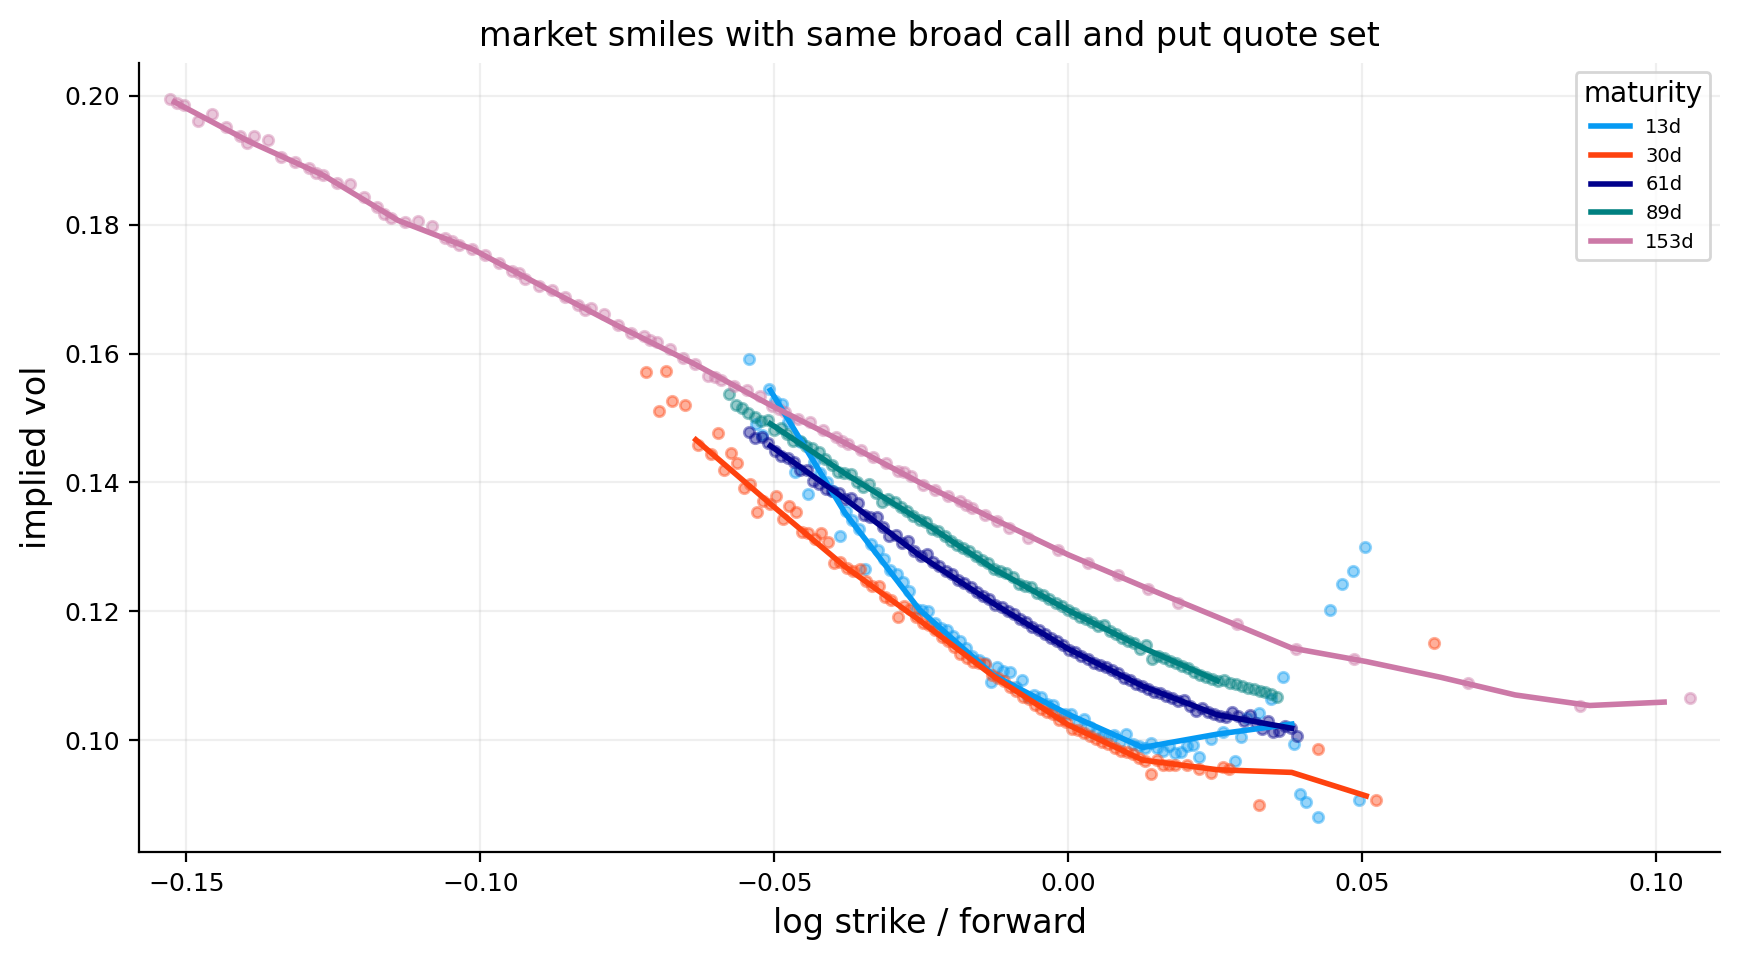

In [13]:
target_days = np.array([14, 30, 60, 90, 150], dtype=float)
slice_ids = [int(np.argmin(np.abs(raw_slices["dte_days"] - d))) for d in target_days if len(raw_slices)]
slice_ids = list(dict.fromkeys(slice_ids))[:5]

fig, ax = plt.subplots(figsize=(8.8, 4.9))
smile_x = []
for n, idx in enumerate(slice_ids):
    tau = float(raw_slices.loc[idx, "tau"])
    expiry = raw_slices.loc[idx, "expiry"]
    grp = q_main[q_main["expiry"].eq(expiry)].copy()
    pts = weighted_by_k(grp)
    ax.scatter(pts["k"], pts["iv_mid"], s=14, alpha=0.42, color=lab_colors[n % len(lab_colors)])
    fn = pchip_interpolator(pts["k"], pts["iv_mid"], extrapolate=False)
    y = fn(k_raw_grid)
    y[(k_raw_grid < pts["k"].min()) | (k_raw_grid > pts["k"].max())] = np.nan
    ax.plot(k_raw_grid, y, lw=2.0, color=lab_colors[n % len(lab_colors)], label=f"{tau * ann_days:.0f}d")
    smile_x.extend([float(pts["k"].min()), float(pts["k"].max())])
ax.set_title("market smiles with same broad call and put quote set")
ax.set_xlabel("log strike / forward")
ax.set_ylabel("implied vol")
if smile_x:
    lo, hi = np.nanmin(smile_x), np.nanmax(smile_x)
    ax.set_xlim(lo - 0.02 * (hi - lo), hi + 0.02 * (hi - lo))
ax.legend(title="maturity")
plt.tight_layout()
plt.show()


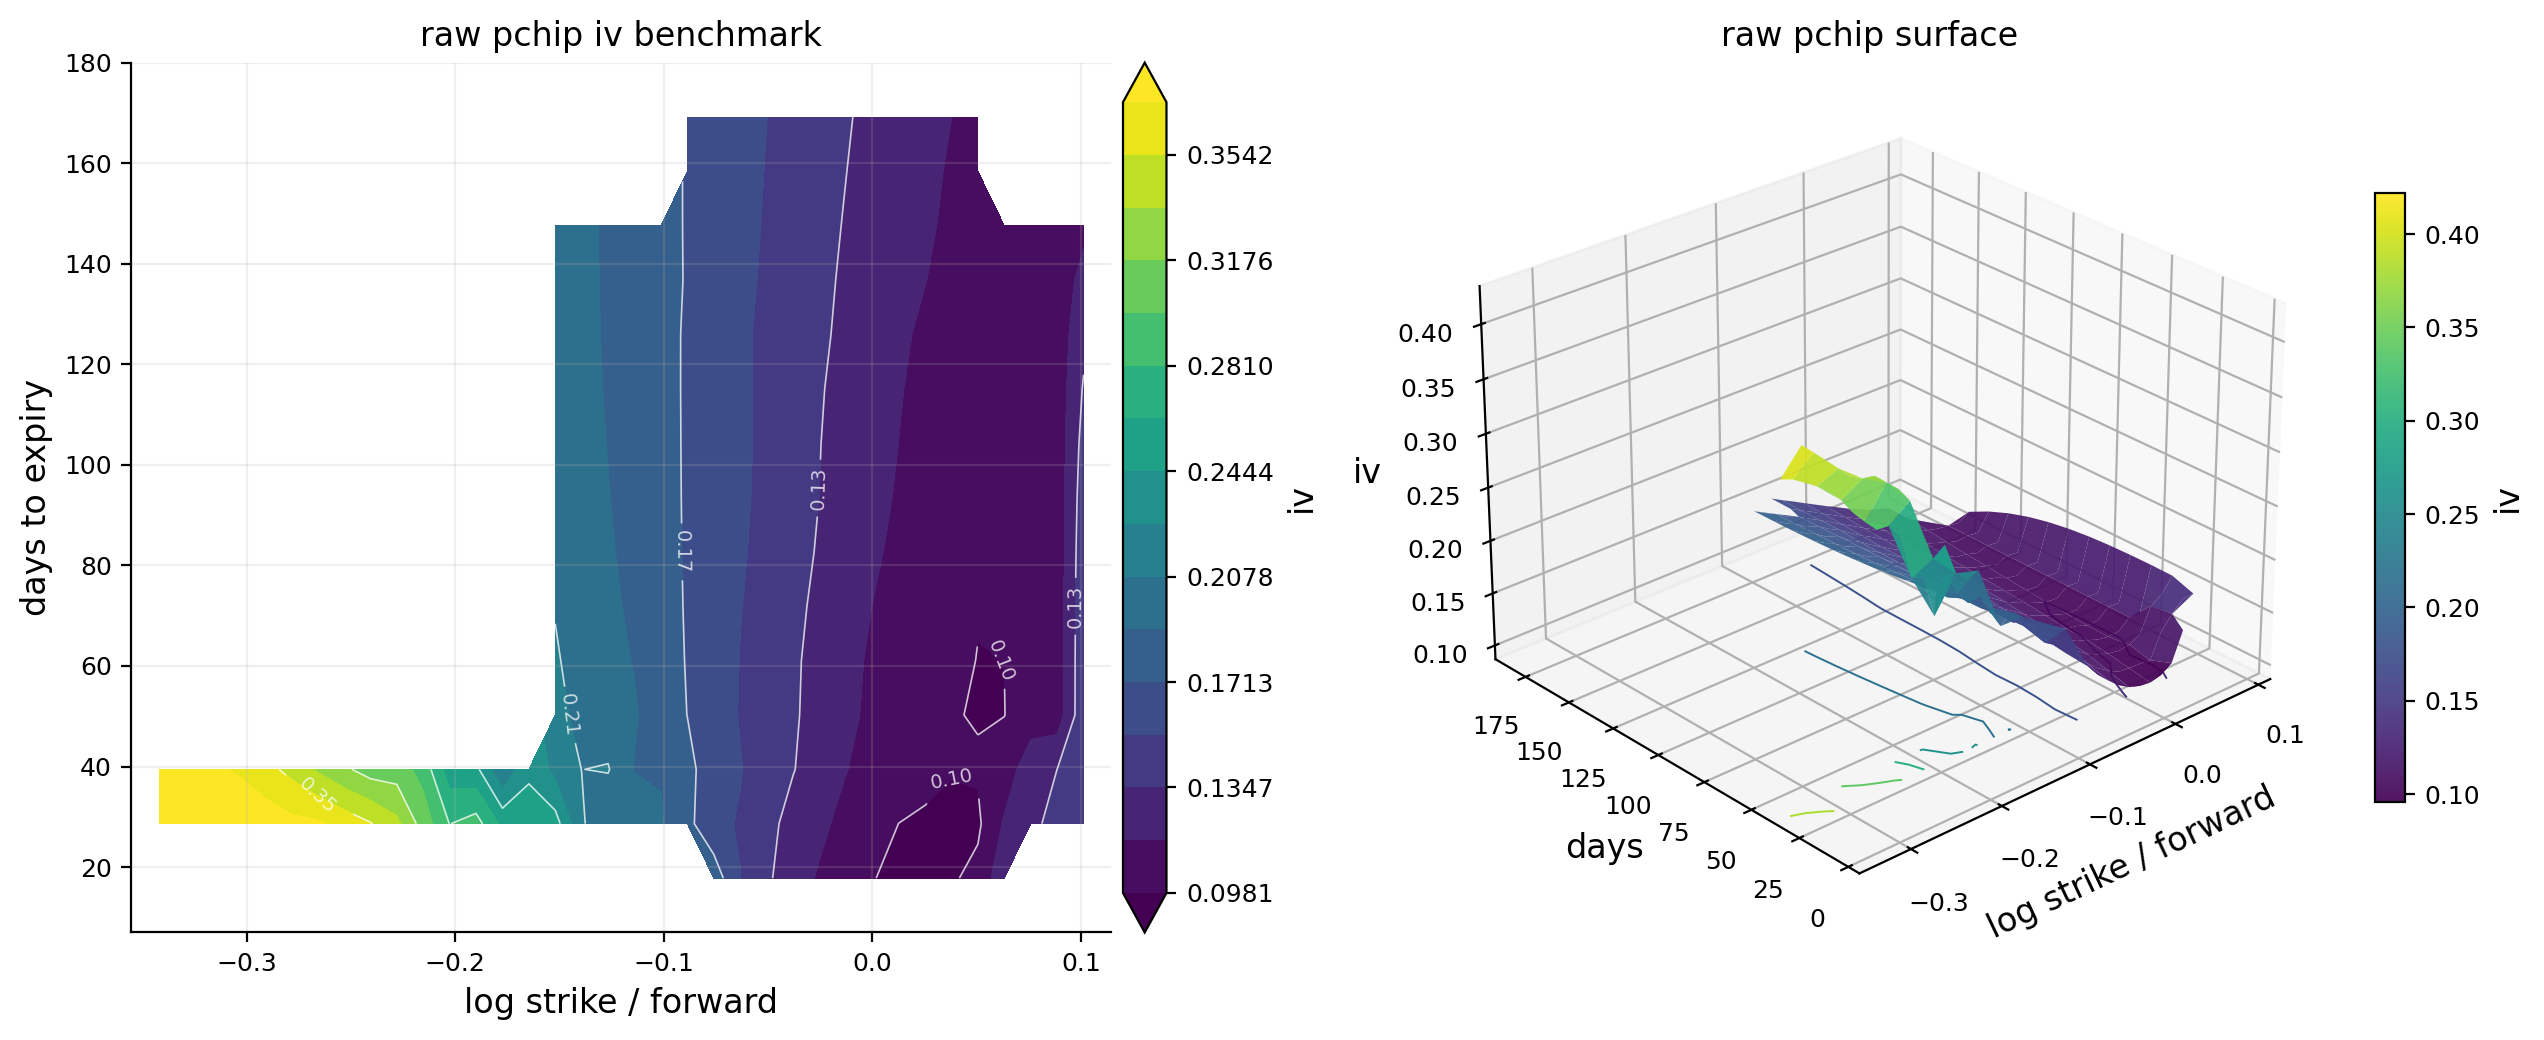

In [14]:
k_mesh_raw, tau_mesh_raw = np.meshgrid(k_raw_grid, tau_raw_grid * ann_days)
raw_k_mask = np.isfinite(raw_iv_grid).any(axis=0)
fig = plt.figure(figsize=(13.0, 5.3))
ax0 = fig.add_subplot(1, 2, 1)
levels = np.linspace(np.nanpercentile(raw_iv_grid, 3), np.nanpercentile(raw_iv_grid, 97), 16)
cf = ax0.contourf(k_raw_grid, tau_raw_grid * ann_days, raw_iv_grid, levels=levels, cmap="viridis", extend="both")
cs = ax0.contour(k_raw_grid, tau_raw_grid * ann_days, raw_iv_grid, levels=levels[::2], colors="white", linewidths=0.6, alpha=0.75)
ax0.clabel(cs, fmt="%.2f", fontsize=7)
ax0.set_title("raw pchip iv benchmark")
ax0.set_xlabel("log strike / forward")
ax0.set_ylabel("days to expiry")
set_supported_xlim(ax0, k_raw_grid, raw_k_mask)
fig.colorbar(cf, ax=ax0, pad=0.01, label="iv")

ax1 = fig.add_subplot(1, 2, 2, projection="3d")
plot_raw = np.ma.masked_invalid(raw_iv_grid)
surf3 = ax1.plot_surface(k_mesh_raw, tau_mesh_raw, plot_raw, cmap="viridis", linewidth=0, antialiased=True, alpha=0.92)
ax1.contour(k_mesh_raw, tau_mesh_raw, plot_raw, zdir="z", offset=np.nanmin(raw_iv_grid) * 0.96, cmap="viridis", linewidths=0.7)
ax1.set_title("raw pchip surface")
ax1.set_xlabel("log strike / forward")
ax1.set_ylabel("days")
ax1.set_zlabel("iv")
lim = xlim_from_mask(k_raw_grid, raw_k_mask)
if lim is not None:
    ax1.set_xlim(*lim)
ax1.view_init(elev=27, azim=-132)
fig.colorbar(surf3, ax=ax1, shrink=0.70, pad=0.06, label="iv")
plt.tight_layout()
plt.show()


In [15]:
def make_knots(n_basis, degree=3):
    n_inner = int(n_basis) - int(degree) - 1
    inner = np.linspace(-1.0, 1.0, n_inner + 2)[1:-1] if n_inner > 0 else np.array([])
    return np.r_[np.repeat(-1.0, degree + 1), inner, np.repeat(1.0, degree + 1)]


def basis_matrix(x, knots, degree=3, der=0):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = np.clip(x, knots[0] + 1e-10, knots[-1] - 1e-10)
    n_basis = len(knots) - degree - 1
    mat = np.zeros((len(x), n_basis), dtype=float)
    for i in range(n_basis):
        coef = np.zeros(n_basis, dtype=float)
        coef[i] = 1.0
        spl = bspline(knots, coef, degree, extrapolate=False)
        if der:
            spl = spl.derivative(der)
        mat[:, i] = spl(x)
    return np.nan_to_num(mat, nan=0.0, posinf=0.0, neginf=0.0)


def second_diff(n):
    eye = np.eye(int(n), dtype=float)
    return np.diff(eye, n=2, axis=0)


def fit_total_var(q, *, n_k=14, n_tau=9, lambda_k=40.0, lambda_tau=70.0, label="fit"):
    z = q[np.isfinite(q["k"]) & np.isfinite(q["tau"]) & np.isfinite(q["iv_mid"]) & np.isfinite(q["obs_weight"])].copy()
    z = z[(z["tau"] > 0) & (z["iv_mid"] > 0)].copy()
    if len(z) < 80 or z["expiry"].nunique() < 4:
        raise ValueError("not enough observations for spline fit")
    k_lo, k_hi = -0.40, 0.40
    t_lo, t_hi = 7.0 / ann_days, 180.0 / ann_days
    k_center, k_scale = 0.5 * (k_lo + k_hi), 0.5 * (k_hi - k_lo)
    t_center, t_scale = 0.5 * (t_lo + t_hi), 0.5 * (t_hi - t_lo)
    k_scaled = (z["k"].to_numpy(dtype=float) - k_center) / k_scale
    t_scaled = (z["tau"].to_numpy(dtype=float) - t_center) / t_scale
    knots_k = make_knots(n_k)
    knots_tau = make_knots(n_tau)
    bk = basis_matrix(k_scaled, knots_k)
    bt = basis_matrix(t_scaled, knots_tau)
    design = (bk[:, :, None] * bt[:, None, :]).reshape(len(z), n_k * n_tau)
    w_total = np.clip((z["iv_mid"].to_numpy(dtype=float) ** 2) * z["tau"].to_numpy(dtype=float), 1e-8, None)
    y = np.log(w_total)
    wt = z["obs_weight"].to_numpy(dtype=float)
    wt = wt / max(np.nanmedian(wt[np.isfinite(wt)]), 1e-12)
    wt = np.clip(wt, 0.05, 50.0)
    dk = second_diff(n_k)
    dt = second_diff(n_tau)
    pen_k = np.kron(dk.T @ dk, np.eye(n_tau))
    pen_t = np.kron(np.eye(n_k), dt.T @ dt)
    normal_mat = design.T @ (design * wt[:, None]) + float(lambda_k) * pen_k + float(lambda_tau) * pen_t + 1e-8 * np.eye(n_k * n_tau)
    rhs = design.T @ (wt * y)
    try:
        coef = linear_solve(normal_mat, rhs, assume_a="pos")
    except (linear_error, ValueError):
        coef = linear_lstsq(normal_mat, rhs)[0]
    fit = {
        "label": label,
        "coef": coef.reshape(n_k, n_tau),
        "knots_k": knots_k,
        "knots_tau": knots_tau,
        "degree": 3,
        "k_center": k_center,
        "k_scale": k_scale,
        "tau_center": t_center,
        "tau_scale": t_scale,
        "lambda_k": float(lambda_k),
        "lambda_tau": float(lambda_tau),
        "n_obs": int(len(z)),
        "n_expiry": int(z["expiry"].nunique()),
    }
    return fit


def logw_points(fit, k_values, tau_values, der_k=0, der_tau=0):
    k_values, tau_values = np.broadcast_arrays(np.asarray(k_values, dtype=float), np.asarray(tau_values, dtype=float))
    flat_k = k_values.reshape(-1)
    flat_t = tau_values.reshape(-1)
    sk = (flat_k - fit["k_center"]) / fit["k_scale"]
    st = (flat_t - fit["tau_center"]) / fit["tau_scale"]
    bk = basis_matrix(sk, fit["knots_k"], fit["degree"], der=der_k) / (fit["k_scale"] ** der_k)
    bt = basis_matrix(st, fit["knots_tau"], fit["degree"], der=der_tau) / (fit["tau_scale"] ** der_tau)
    vals = np.einsum("ij,jl,il->i", bk, fit["coef"], bt)
    return vals.reshape(k_values.shape)


def logw_grid(fit, k_values, tau_values, der_k=0, der_tau=0):
    kk, tt = np.meshgrid(np.asarray(k_values, dtype=float), np.asarray(tau_values, dtype=float))
    return logw_points(fit, kk, tt, der_k=der_k, der_tau=der_tau)


def iv_points(fit, k_values, tau_values):
    tau_values = np.asarray(tau_values, dtype=float)
    log_w = logw_points(fit, k_values, tau_values)
    return np.sqrt(np.exp(np.clip(log_w, -40.0, 5.0)) / np.clip(tau_values, 1e-8, None))


def iv_grid(fit, k_values, tau_values):
    log_w = logw_grid(fit, k_values, tau_values)
    return np.sqrt(np.exp(np.clip(log_w, -40.0, 5.0)) / np.clip(np.asarray(tau_values)[:, None], 1e-8, None))


def fit_metrics(fit, q, label=None):
    fitted = iv_points(fit, q["k"].to_numpy(dtype=float), q["tau"].to_numpy(dtype=float))
    resid = q["iv_mid"].to_numpy(dtype=float) - fitted
    wt = q["obs_weight"].to_numpy(dtype=float)
    ok = np.isfinite(resid) & np.isfinite(wt) & (wt > 0)
    return pd.Series({
        "fit": label or fit["label"],
        "date": pd.Timestamp(q["date"].iloc[0]).date() if len(q) else pd.NaT,
        "quote_count": int(ok.sum()),
        "number_of_maturities": int(q["expiry"].nunique()),
        "rmse": float(np.sqrt(np.nanmean(resid[ok] ** 2))),
        "weighted_rmse": float(np.sqrt(np.nansum(wt[ok] * resid[ok] ** 2) / np.nansum(wt[ok]))),
        "mae": float(np.nanmean(np.abs(resid[ok]))),
        "median_absolute_error": float(np.nanmedian(np.abs(resid[ok]))),
        "p95_absolute_error": float(np.nanquantile(np.abs(resid[ok]), 0.95)),
        "mean_residual": float(np.nanmean(resid[ok])),
        "residual_std": float(np.nanstd(resid[ok])),
        "k_min": float(np.nanmin(q["k"])),
        "k_max": float(np.nanmax(q["k"])),
        "min_dte": float(np.nanmin(q["dte_days"])),
        "max_dte": float(np.nanmax(q["dte_days"])),
    })


In [16]:
def basis_for_autodiff(x, knots, degree=3):
    x = jnp.clip(x, knots[0] + 1e-10, knots[-1] - 1e-10)
    b = jnp.where((x >= knots[:-1]) & (x < knots[1:]), 1.0, 0.0)
    for order in range(1, int(degree) + 1):
        n = knots.shape[0] - order - 1
        left_den = knots[order:n + order] - knots[:n]
        right_den = knots[order + 1:n + order + 1] - knots[1:n + 1]
        left_den_safe = jnp.where(left_den > 0, left_den, 1.0)
        right_den_safe = jnp.where(right_den > 0, right_den, 1.0)
        left = jnp.where(left_den > 0, (x - knots[:n]) / left_den_safe, 0.0) * b[:n]
        right = jnp.where(right_den > 0, (knots[order + 1:n + order + 1] - x) / right_den_safe, 0.0) * b[1:n + 1]
        b = left + right
    return b


def iv_from_fit_for_autodiff(fit, k_value, tau_value):
    coef = jnp.asarray(fit["coef"])
    knots_k = jnp.asarray(fit["knots_k"])
    knots_tau = jnp.asarray(fit["knots_tau"])
    degree = int(fit.get("degree", 3))
    sk = (k_value - jnp.asarray(fit["k_center"])) / jnp.asarray(fit["k_scale"])
    st = (tau_value - jnp.asarray(fit["tau_center"])) / jnp.asarray(fit["tau_scale"])
    bk = basis_for_autodiff(sk, knots_k, degree)
    bt = basis_for_autodiff(st, knots_tau, degree)
    log_w = bk @ coef @ bt
    return jnp.sqrt(jnp.exp(jnp.clip(log_w, -40.0, 5.0)) / jnp.maximum(tau_value, 1e-8))


def iv_from_arrays_for_autodiff(coef, knots_k, knots_tau, k_center, k_scale, tau_center, tau_scale, k_value, tau_value):
    sk = (k_value - k_center) / k_scale
    st = (tau_value - tau_center) / tau_scale
    bk = basis_for_autodiff(sk, knots_k, 3)
    bt = basis_for_autodiff(st, knots_tau, 3)
    log_w = bk @ coef @ bt
    return jnp.sqrt(jnp.exp(jnp.clip(log_w, -40.0, 5.0)) / jnp.maximum(tau_value, 1e-8))


@jax.jit
def dupire_grid_for_autodiff(coef, knots_k, knots_tau, k_center, k_scale, tau_center, tau_scale, tau_values, strike_values, rate_values, carry_values, spot_value):
    def rate_value(tau_value):
        return jnp.interp(tau_value, tau_values, rate_values)

    def carry_value(tau_value):
        return jnp.interp(tau_value, tau_values, carry_values)

    def iv_value(k_value, tau_value):
        return iv_from_arrays_for_autodiff(coef, knots_k, knots_tau, k_center, k_scale, tau_center, tau_scale, k_value, tau_value)

    def call_price_scalar(strike_value, tau_value):
        tau_value = jnp.maximum(tau_value, 1e-8)
        r_value = rate_value(tau_value)
        b_value = carry_value(tau_value)
        forward_value = spot_value * jnp.exp(b_value * tau_value)
        k_model = jnp.log(strike_value / jnp.maximum(forward_value, 1e-300))
        sigma_value = jnp.maximum(iv_value(k_model, tau_value), 1e-6)
        sqrt_tau = jnp.sqrt(tau_value)
        d1 = (jnp.log(jnp.maximum(forward_value, 1e-300) / jnp.maximum(strike_value, 1e-300)) + 0.5 * sigma_value ** 2 * tau_value) / (sigma_value * sqrt_tau)
        d2 = d1 - sigma_value * sqrt_tau
        cdf1 = 0.5 * (1.0 + jax.lax.erf(d1 / jnp.sqrt(2.0)))
        cdf2 = 0.5 * (1.0 + jax.lax.erf(d2 / jnp.sqrt(2.0)))
        return jnp.exp(-r_value * tau_value) * (forward_value * cdf1 - strike_value * cdf2)

    price_tau_scalar = jax.grad(call_price_scalar, argnums=1)
    price_strike_scalar = jax.grad(call_price_scalar, argnums=0)
    price_strike_strike_scalar = jax.grad(price_strike_scalar, argnums=0)
    tau_mesh, strike_mesh = jnp.meshgrid(tau_values, strike_values, indexing="ij")

    def node(strike_value, tau_value):
        r_value = rate_value(tau_value)
        b_value = carry_value(tau_value)
        q_value = r_value - b_value
        forward_value = spot_value * jnp.exp(b_value * tau_value)
        k_model = jnp.log(strike_value / jnp.maximum(forward_value, 1e-300))
        iv_node = iv_value(k_model, tau_value)
        price_value = call_price_scalar(strike_value, tau_value)
        c_tau_value = price_tau_scalar(strike_value, tau_value)
        c_strike_value = price_strike_scalar(strike_value, tau_value)
        c_strike_strike_value = price_strike_strike_scalar(strike_value, tau_value)
        numerator_value = c_tau_value + q_value * price_value + (r_value - q_value) * strike_value * c_strike_value
        denominator_value = 0.5 * strike_value ** 2 * c_strike_strike_value
        return price_value, iv_node, k_model, numerator_value / denominator_value, numerator_value, denominator_value

    vals = jax.vmap(node)(strike_mesh.reshape(-1), tau_mesh.reshape(-1))
    return [v.reshape(tau_mesh.shape) for v in vals]


def dupire_from_fit(fit, q, tau_values, k_values, lv_cap=2.50, ratio_cap=3.00):
    tau_values = np.asarray(tau_values, dtype=float)
    k_values = np.asarray(k_values, dtype=float)
    spot_value = float(np.nanmedian(pd.to_numeric(q["spot"], errors="coerce")))
    strike_grid = spot_value * np.exp(k_values)
    rate_tau = rate_on_tau(q, tau_values)
    carry_tau = carry_on_tau(q, tau_values, spot_value)
    q_tau = rate_tau - carry_tau
    forward_tau = spot_value * np.exp(carry_tau * tau_values)
    price_out, iv_out, model_k, local_var, numerator, denominator = dupire_grid_for_autodiff(
        jnp.asarray(fit["coef"]),
        jnp.asarray(fit["knots_k"]),
        jnp.asarray(fit["knots_tau"]),
        jnp.asarray(fit["k_center"]),
        jnp.asarray(fit["k_scale"]),
        jnp.asarray(fit["tau_center"]),
        jnp.asarray(fit["tau_scale"]),
        jnp.asarray(tau_values),
        jnp.asarray(strike_grid),
        jnp.asarray(rate_tau),
        jnp.asarray(carry_tau),
        jnp.asarray(spot_value),
    )
    price_out.block_until_ready()
    price_out = np.asarray(price_out, dtype=float)
    iv_out = np.asarray(iv_out, dtype=float)
    model_k = np.asarray(model_k, dtype=float)
    local_var = np.asarray(local_var, dtype=float)
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    local_vol_raw = np.sqrt(np.where(local_var > 0, local_var, np.nan))
    ratio_raw = local_vol_raw / iv_out
    boundary = np.zeros_like(local_var, dtype=bool)
    boundary[[0, -1], :] = True
    boundary[:, [0, -1]] = True
    support_mask = support_mask_from_limits(quote_support(q), model_k, tau_values[:, None])
    denom_floor = 1e-10
    nonfinite_var = ~np.isfinite(local_var)
    negative_var = np.isfinite(local_var) & (local_var <= 0)
    negative_density = np.isfinite(denominator) & (denominator <= denom_floor)
    near_zero_denominator = ~np.isfinite(denominator) | (np.abs(denominator) <= denom_floor)
    hard_invalid = nonfinite_var | negative_var | negative_density | near_zero_denominator
    hard_other = hard_invalid & ~negative_density
    valid_for_ratio = support_mask & (~boundary) & (~hard_invalid) & np.isfinite(ratio_raw) & np.isfinite(local_vol_raw)
    extreme_ratio = valid_for_ratio & ((ratio_raw > ratio_cap) | (ratio_raw < 1.0 / ratio_cap) | (local_vol_raw > lv_cap))
    invalid_mask = boundary | (~support_mask) | hard_invalid | extreme_ratio
    return {
        "engine_used": "jax",
        "fallback_used": False,
        "k_grid": k_values,
        "tau_grid": tau_values,
        "strike_grid": strike_grid,
        "model_k_grid": model_k,
        "iv_grid": np.where(support_mask, iv_out, np.nan),
        "price_grid": np.where(support_mask, price_out, np.nan),
        "local_var": local_var,
        "local_vol": np.where(invalid_mask, np.nan, local_vol_raw),
        "local_vol_raw": local_vol_raw,
        "local_vol_to_iv": np.where(invalid_mask, np.nan, ratio_raw),
        "local_vol_to_iv_raw": ratio_raw,
        "numerator": numerator,
        "denominator": denominator,
        "support_mask": support_mask,
        "boundary_mask": boundary,
        "hard_invalid_mask": hard_invalid,
        "hard_other_mask": hard_other,
        "negative_var_mask": negative_var,
        "negative_density_mask": negative_density,
        "near_zero_denominator_mask": near_zero_denominator,
        "extreme_ratio_mask": extreme_ratio,
        "invalid_mask": invalid_mask,
        "rate_tau": rate_tau,
        "carry_tau": carry_tau,
        "q_tau": q_tau,
        "forward_tau": forward_tau,
        "spot": spot_value,
    }

def row_at_k(arr, k_values, k_value):
    idx = int(np.argmin(np.abs(np.asarray(k_values) - float(k_value))))
    return arr[:, idx]



def dupire_metrics(lv, downside_k=shape_k_down_hist):
    region = lv["support_mask"] & (~lv["boundary_mask"])
    if not region.any():
        region = np.isfinite(lv["iv_grid"])
    hard_invalid_share = float(np.nanmean(lv["hard_invalid_mask"][region]))
    hard_other_share = float(np.nanmean(lv["hard_other_mask"][region]))
    neg_var_share = float(np.nanmean(lv["negative_var_mask"][region]))
    neg_density_share = float(np.nanmean(lv["negative_density_mask"][region]))
    extreme_share = float(np.nanmean(lv["extreme_ratio_mask"][region]))
    total_flagged_share = float(np.nanmean((lv["hard_invalid_mask"] | lv["extreme_ratio_mask"])[region]))
    ratio = lv["local_vol_to_iv_raw"]
    valid_ratio = ratio[region & (~lv["hard_invalid_mask"]) & (~lv["extreme_ratio_mask"]) & np.isfinite(ratio)]
    def supported_slice(target):
        vals = []
        k_values = np.asarray(lv["k_grid"], dtype=float)
        arr = lv["local_vol"]
        ok_grid = region & (~lv["hard_invalid_mask"]) & (~lv["extreme_ratio_mask"]) & np.isfinite(arr)
        for i in range(arr.shape[0]):
            ok = ok_grid[i]
            if ok.any():
                idx = np.where(ok)[0]
                vals.append(float(arr[i, idx[np.argmin(np.abs(k_values[idx] - target))]]))
            else:
                vals.append(np.nan)
        return np.asarray(vals, dtype=float)

    atm_lv = supported_slice(shape_k_atm)
    down_lv = supported_slice(downside_k)
    up_lv = supported_slice(shape_k_up)
    med_abs = float(np.nanmedian(np.abs(valid_ratio - 1.0))) if len(valid_ratio) else np.nan
    stress = 1.00 * hard_other_share + 0.75 * extreme_share + 0.50 * med_abs + 0.25 * neg_density_share
    return {
        "engine_used": lv.get("engine_used", "jax"),
        "fallback_used": bool(lv.get("fallback_used", False)),
        "dupire_hard_invalid_share": hard_invalid_share,
        "dupire_hard_invalid_other_share": hard_other_share,
        "dupire_negative_var_share": neg_var_share,
        "dupire_negative_density_share": neg_density_share,
        "dupire_extreme_ratio_share": extreme_share,
        "dupire_total_flagged_share": total_flagged_share,
        "dupire_median_lv_to_iv": float(np.nanmedian(valid_ratio)) if len(valid_ratio) else np.nan,
        "dupire_median_abs_lv_to_iv_minus_1": med_abs,
        "dupire_atm_local_vol_level": float(np.nanmedian(atm_lv)),
        "dupire_downside_local_vol_premium": float(np.nanmedian(down_lv - atm_lv)),
        "dupire_upside_local_vol_premium": float(np.nanmedian(up_lv - atm_lv)),
        "dupire_stress": float(stress),
    }

fit_visual = fit_total_var(q_main, n_k=15, n_tau=9, lambda_k=28.0, lambda_tau=55.0, label="visual")
dupire_candidates = []
for lambda_k_try, lambda_tau_try in [(90.0, 130.0), (180.0, 260.0), (360.0, 520.0), (700.0, 900.0)]:
    try:
        f_try = fit_total_var(q_main, n_k=15, n_tau=9, lambda_k=lambda_k_try, lambda_tau=lambda_tau_try, label="dupire")
        lv_try = dupire_from_fit(f_try, q_main, tau_lv_grid, k_lv_grid)
        m_try = dupire_metrics(lv_try, downside_k=shape_k_down)
        e_try = fit_metrics(f_try, q_main, "dupire")
        score = (
            e_try["weighted_rmse"]
            + 0.20 * m_try["dupire_hard_invalid_other_share"]
            + 0.10 * m_try["dupire_negative_density_share"]
            + 0.08 * m_try["dupire_median_abs_lv_to_iv_minus_1"]
        )
        dupire_candidates.append({
            "lambda_k": lambda_k_try,
            "lambda_tau": lambda_tau_try,
            "weighted_rmse": float(e_try["weighted_rmse"]),
            "hard_invalid_share": m_try["dupire_hard_invalid_share"],
            "hard_invalid_other_share": m_try["dupire_hard_invalid_other_share"],
            "negative_density_share": m_try["dupire_negative_density_share"],
            "extreme_ratio_share": m_try["dupire_extreme_ratio_share"],
            "total_flagged_share": m_try["dupire_total_flagged_share"],
            "median_abs_lv_to_iv_minus_1": m_try["dupire_median_abs_lv_to_iv_minus_1"],
            "selection_score": float(score),
            "fit": f_try,
        })
    except Exception as exc:
        dupire_candidates.append({"lambda_k": lambda_k_try, "lambda_tau": lambda_tau_try, "selection_score": np.inf, "error": str(exc)[:120]})

candidate_table = pd.DataFrame([{k: v for k, v in row.items() if k != "fit"} for row in dupire_candidates]).sort_values("selection_score")
best = min([row for row in dupire_candidates if "fit" in row], key=lambda row: row["selection_score"])
fit_dupire = best["fit"]
dupire_lambda_k = float(best["lambda_k"])
dupire_lambda_tau = float(best["lambda_tau"])

main_support_mask = support_mask_for_grid(q_main, k_fit_grid, tau_fit_grid)
iv_visual_grid = masked_grid(iv_grid(fit_visual, k_fit_grid, tau_fit_grid), main_support_mask)
iv_dupire_grid = masked_grid(iv_grid(fit_dupire, k_fit_grid, tau_fit_grid), main_support_mask)
fit_table = pd.DataFrame([fit_metrics(fit_visual, q_main, "visual"), fit_metrics(fit_dupire, q_main, "dupire")])
grid_check = pd.DataFrame([{
    "fit": "visual",
    "finite_supported_grid_share": float(np.isfinite(iv_visual_grid[main_support_mask]).mean()),
    "min_supported_grid_iv": float(np.nanmin(iv_visual_grid)),
    "max_supported_grid_iv": float(np.nanmax(iv_visual_grid)),
}, {
    "fit": "dupire",
    "finite_supported_grid_share": float(np.isfinite(iv_dupire_grid[main_support_mask]).mean()),
    "min_supported_grid_iv": float(np.nanmin(iv_dupire_grid)),
    "max_supported_grid_iv": float(np.nanmax(iv_dupire_grid)),
}])
check_k = rng.uniform(max(-0.20, q_main["k"].quantile(0.03)), min(0.08, q_main["k"].quantile(0.97)), 24)
check_tau = rng.uniform(max(21 / ann_days, q_main["tau"].quantile(0.03)), min(150 / ann_days, q_main["tau"].quantile(0.97)), 24)
iv_numpy_check = iv_points(fit_dupire, check_k, check_tau)
iv_auto_check = np.asarray(jax.vmap(lambda k_value, tau_value: iv_from_fit_for_autodiff(fit_dupire, k_value, tau_value))(jnp.asarray(check_k), jnp.asarray(check_tau)), dtype=float)
spline_eval_check = pd.DataFrame([{"surface_eval_max_abs_diff": float(np.nanmax(np.abs(iv_numpy_check - iv_auto_check)))}])
display(candidate_table)
display(fit_table)
display(grid_check)
display(spline_eval_check)


,lambda_k,lambda_tau,weighted_rmse,hard_invalid_share,hard_invalid_other_share,negative_density_share,extreme_ratio_share,total_flagged_share,median_abs_lv_to_iv_minus_1,selection_score
0,90.000000,130.000000,0.005491,0.028452,0.028452,0.000000,0.016736,0.045188,0.231118,0.029671
1,180.000000,260.000000,0.006030,0.032636,0.032636,0.000000,0.015063,0.047699,0.242881,0.031987
2,360.000000,520.000000,0.007168,0.037657,0.037657,0.000000,0.016736,0.054393,0.270835,0.036366
3,700.000000,900.000000,0.008729,0.041841,0.041841,0.000000,0.015063,0.056904,0.302894,0.041329


,fit,date,quote_count,number_of_maturities,rmse,weighted_rmse,mae,median_absolute_error,p95_absolute_error,mean_residual,residual_std,k_min,k_max,min_dte,max_dte
0,visual,2023-12-29,5554,33,0.010989,0.005030,0.004965,0.002258,0.018665,0.001035,0.010941,-0.344795,0.117917,9.333333,174.333333
1,dupire,2023-12-29,5554,33,0.011624,0.005491,0.005490,0.002750,0.018626,0.000829,0.011594,-0.344795,0.117917,9.333333,174.333333


,fit,finite_supported_grid_share,min_supported_grid_iv,max_supported_grid_iv
0,visual,1.000000,0.079507,0.386654
1,dupire,1.000000,0.078502,0.378564


,surface_eval_max_abs_diff
0,0.000000


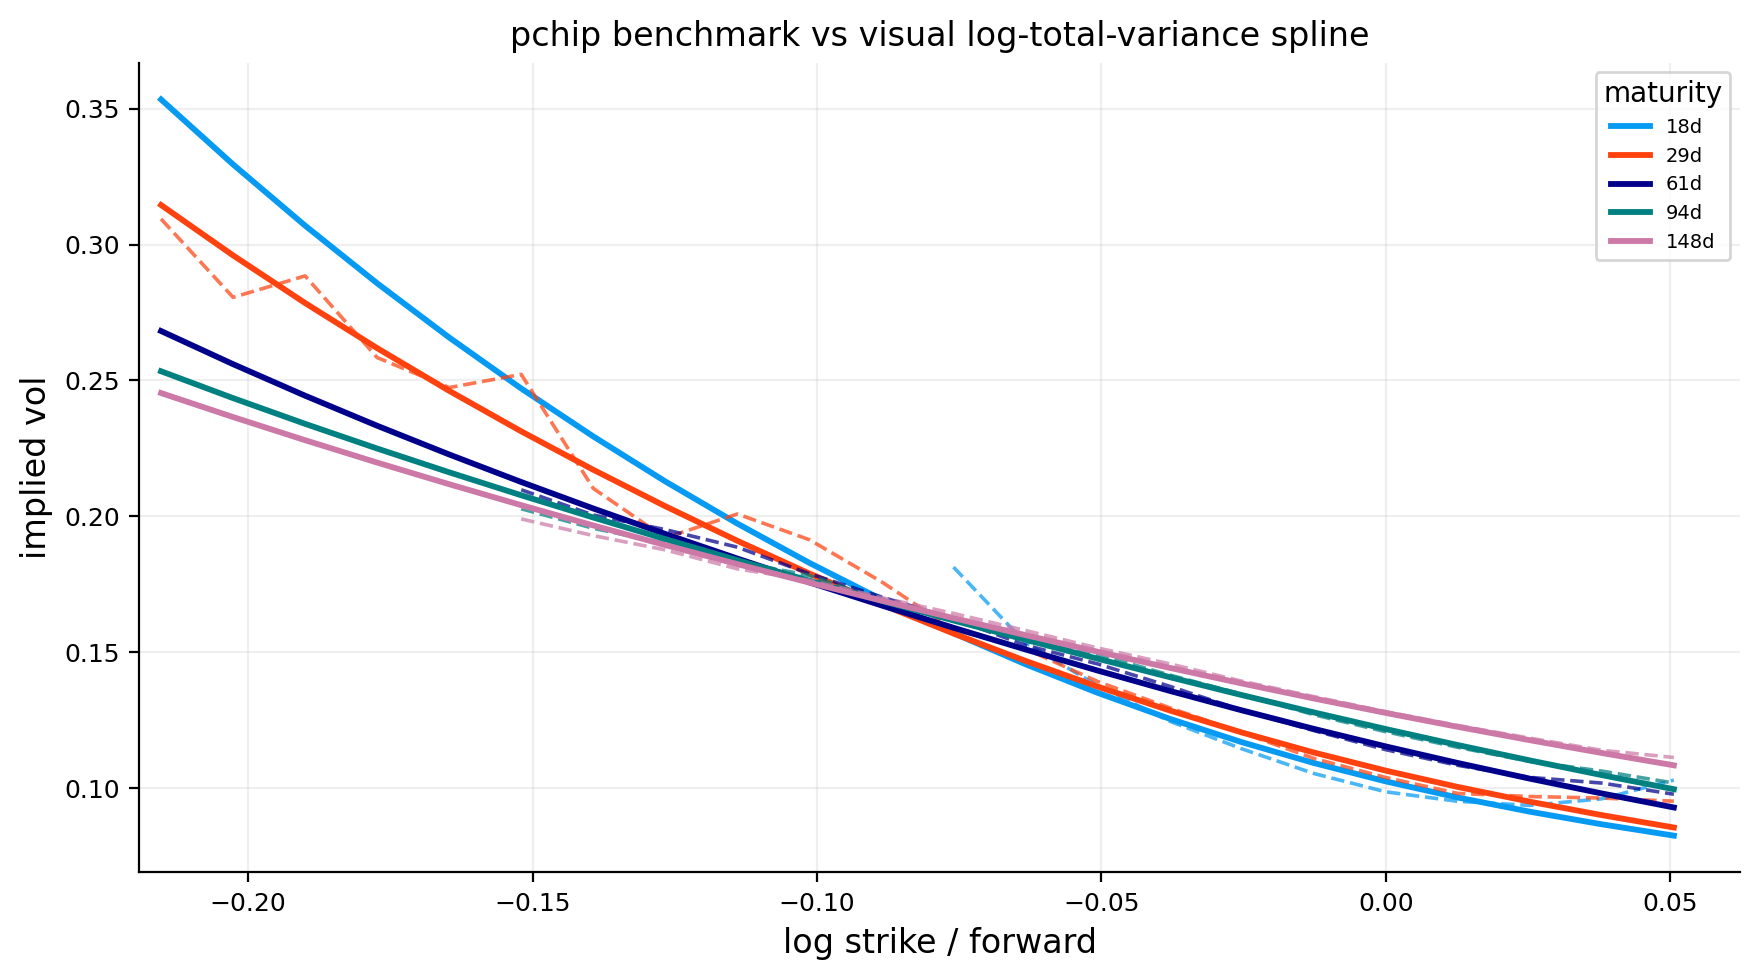

In [17]:
fig, ax = plt.subplots(figsize=(8.9, 5.0))
limits_main = quote_support(q_main)
for n, day in enumerate([14, 30, 60, 90, 150]):
    i_raw = int(np.nanargmin(np.abs(tau_raw_grid * ann_days - day)))
    tau = tau_raw_grid[i_raw]
    raw_y = raw_iv_grid[i_raw].copy()
    smooth_y = iv_points(fit_visual, k_raw_grid, np.full_like(k_raw_grid, tau))
    support_line = support_mask_from_limits(limits_main, k_raw_grid, np.full_like(k_raw_grid, tau))
    raw_y[~support_line] = np.nan
    smooth_y[~support_line] = np.nan
    ax.plot(k_raw_grid, raw_y, ls="--", lw=1.3, color=lab_colors[n % len(lab_colors)], alpha=0.72)
    ax.plot(k_raw_grid, smooth_y, lw=2.1, color=lab_colors[n % len(lab_colors)], label=f"{tau * ann_days:.0f}d")
ax.set_xlim(max(k_raw_grid.min(), limits_main["k_lo"]), min(k_raw_grid.max(), limits_main["k_hi"]))
ax.set_title("pchip benchmark vs visual log-total-variance spline")
ax.set_xlabel("log strike / forward")
ax.set_ylabel("implied vol")
ax.legend(title="maturity")
plt.tight_layout()
plt.show()


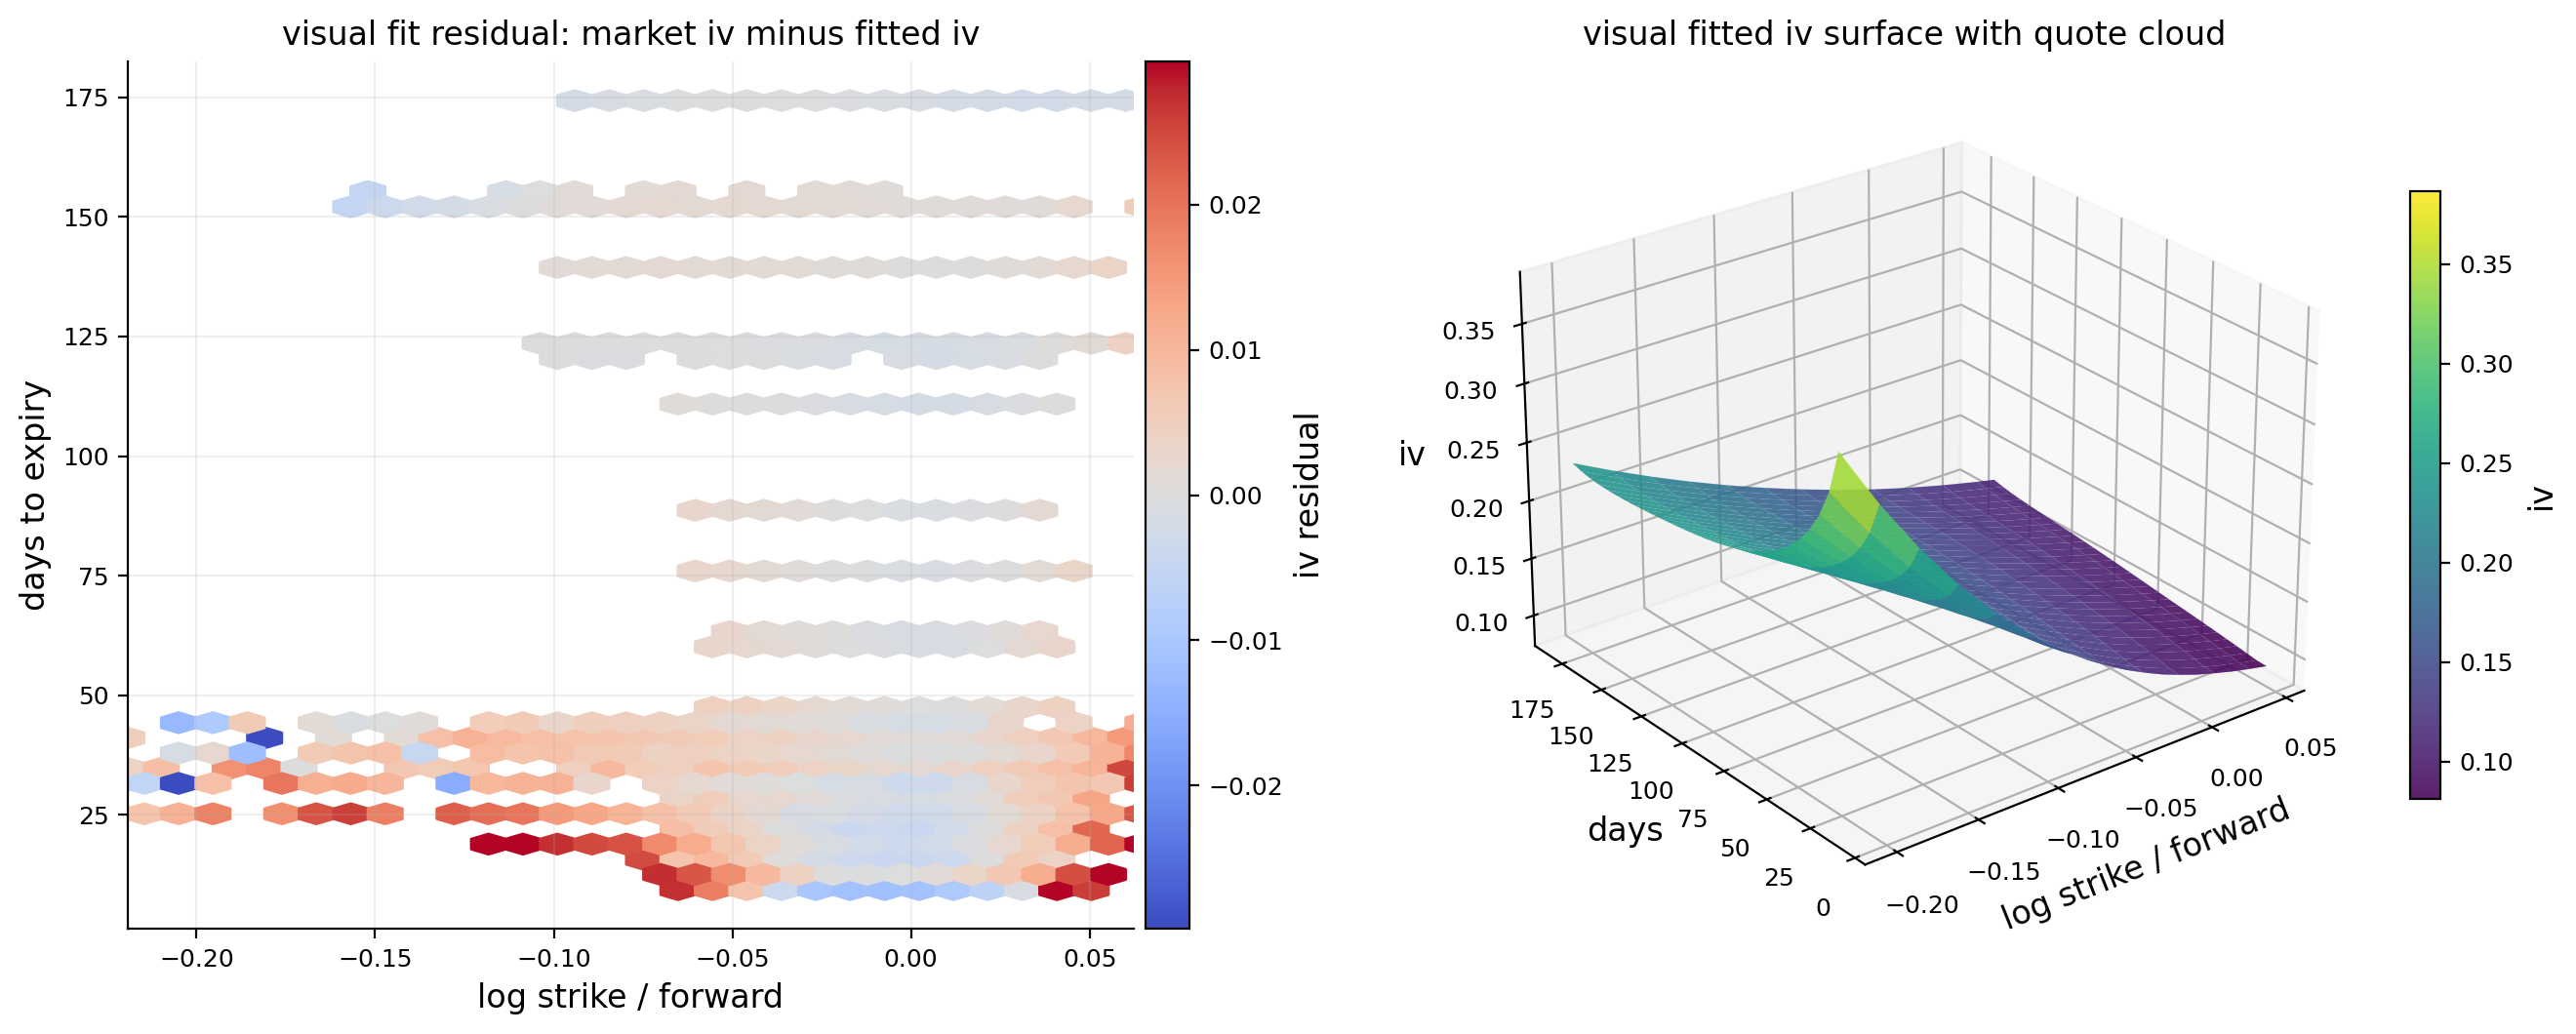

In [18]:
q_fit = q_main.copy()
q_fit["fit_iv_visual"] = iv_points(fit_visual, q_fit["k"].to_numpy(dtype=float), q_fit["tau"].to_numpy(dtype=float))
q_fit["fit_iv_dupire"] = iv_points(fit_dupire, q_fit["k"].to_numpy(dtype=float), q_fit["tau"].to_numpy(dtype=float))
q_fit["residual_visual"] = q_fit["iv_mid"] - q_fit["fit_iv_visual"]
q_fit["residual_dupire"] = q_fit["iv_mid"] - q_fit["fit_iv_dupire"]
res_lim = robust_abs_limit(q_fit["residual_visual"], q=0.98, floor=0.005)

fig = plt.figure(figsize=(13.5, 5.4))
ax0 = fig.add_subplot(1, 2, 1)
res_hex = ax0.hexbin(q_fit["k"], q_fit["dte_days"], C=q_fit["residual_visual"], gridsize=(48, 26), reduce_C_function=np.nanmedian, mincnt=1, cmap="coolwarm", vmin=-res_lim, vmax=res_lim)
ax0.set_xlim(limits_main["k_lo"], limits_main["k_hi"])
ax0.set_title("visual fit residual: market iv minus fitted iv")
ax0.set_xlabel("log strike / forward")
ax0.set_ylabel("days to expiry")
fig.colorbar(res_hex, ax=ax0, pad=0.01, label="iv residual")

ax1 = fig.add_subplot(1, 2, 2, projection="3d")
k_mesh, tau_mesh = np.meshgrid(k_fit_grid, tau_fit_grid * ann_days)
surf3 = ax1.plot_surface(k_mesh, tau_mesh, np.ma.masked_invalid(iv_visual_grid), cmap="viridis", linewidth=0, antialiased=True, alpha=0.88)
q3 = q_fit.sample(min(len(q_fit), 1800), random_state=seed)
ax1.set_xlim(limits_main["k_lo"], limits_main["k_hi"])
ax1.set_title("visual fitted iv surface with quote cloud")
ax1.set_xlabel("log strike / forward")
ax1.set_ylabel("days")
ax1.set_zlabel("iv")
ax1.view_init(elev=26, azim=-128)
fig.colorbar(surf3, ax=ax1, shrink=0.7, pad=0.06, label="iv")
plt.tight_layout()
plt.show()


,fit,date,quote_count,number_of_maturities,rmse,weighted_rmse,mae,median_absolute_error,p95_absolute_error,mean_residual,residual_std,k_min,k_max,min_dte,max_dte
0,visual,2023-12-29,5554,33,0.010989,0.005030,0.004965,0.002258,0.018665,0.001035,0.010941,-0.344795,0.117917,9.333333,174.333333
1,dupire,2023-12-29,5554,33,0.011624,0.005491,0.005490,0.002750,0.018626,0.000829,0.011594,-0.344795,0.117917,9.333333,174.333333


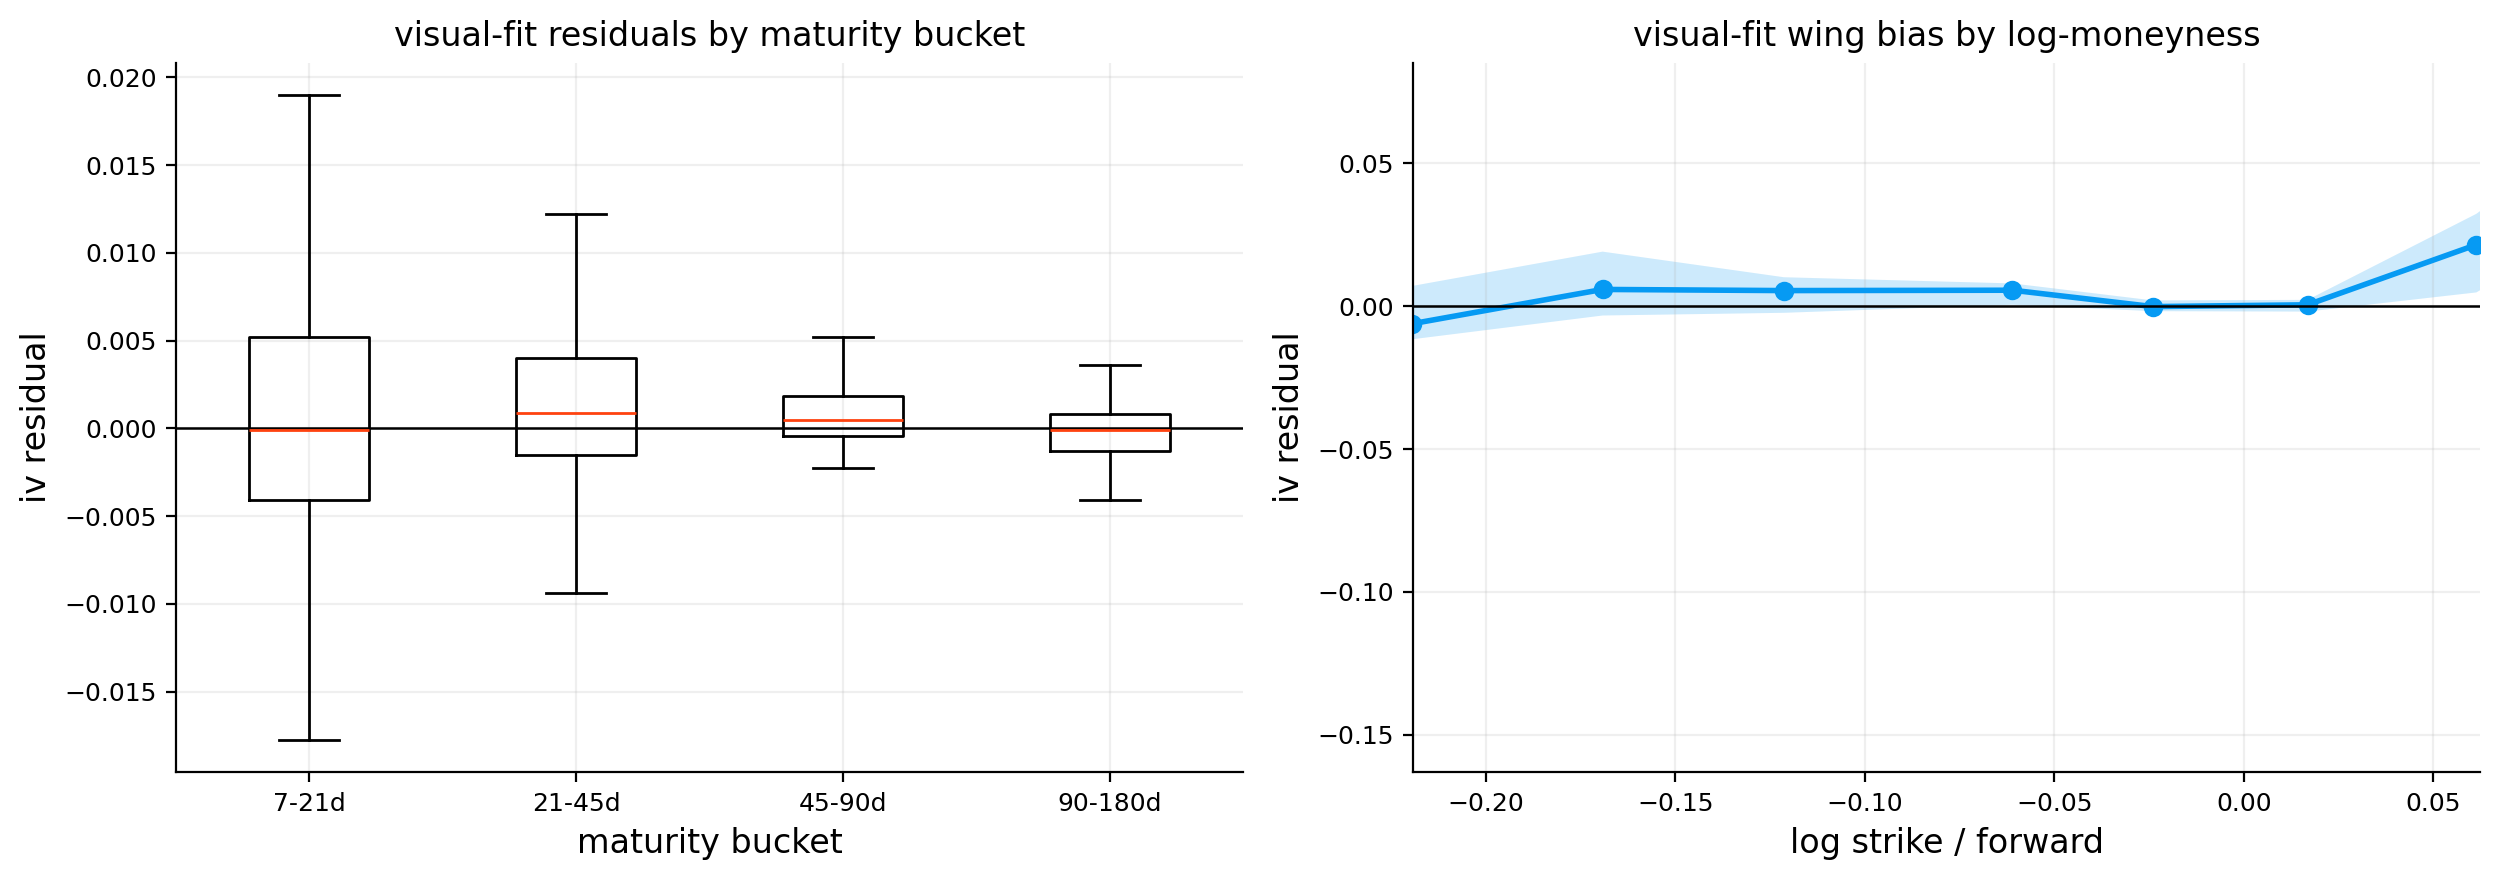

,date,expiry,option_type,strike,k,dte_days,iv_mid,fit_iv_visual,fit_iv_dupire,residual_visual,residual_dupire,iv_uncertainty
2404433,2023-12-29,2024-01-25,put,"3,400.000000",-0.342951,26.333333,0.453259,0.618881,0.627676,-0.165622,-0.174417,0.012389
2404964,2023-12-29,2024-01-30,call,"3,400.000000",-0.343128,31.333333,0.419128,0.578432,0.587752,-0.159304,-0.168623,0.500000
2404965,2023-12-29,2024-01-30,put,"3,400.000000",-0.343128,31.333333,0.423619,0.578432,0.587752,-0.154813,-0.164133,0.014764
2405269,2023-12-29,2024-02-01,put,"3,400.000000",-0.343818,33.333333,0.418148,0.567007,0.576614,-0.148859,-0.158466,0.008424
2405852,2023-12-29,2024-02-07,call,"3,400.000000",-0.344244,39.333333,0.385966,0.533230,0.543225,-0.147265,-0.157260,0.500000
2404432,2023-12-29,2024-01-25,call,"3,400.000000",-0.342951,26.333333,0.475398,0.618881,0.627676,-0.143483,-0.152278,0.500000
2405753,2023-12-29,2024-02-06,put,"3,400.000000",-0.344106,38.333333,0.397564,0.538062,0.547987,-0.140498,-0.150423,0.006863
2405853,2023-12-29,2024-02-07,put,"3,400.000000",-0.344244,39.333333,0.394289,0.533230,0.543225,-0.138941,-0.148936,0.009881
2406131,2023-12-29,2024-02-12,put,"3,400.000000",-0.344795,44.333333,0.377801,0.511296,0.521563,-0.133495,-0.143762,0.008351
2405268,2023-12-29,2024-02-01,call,"3,400.000000",-0.343818,33.333333,0.466613,0.567007,0.576614,-0.100394,-0.110001,0.312205


In [19]:
display(pd.DataFrame([fit_metrics(fit_visual, q_main, "visual"), fit_metrics(fit_dupire, q_main, "dupire")]))

q_fit["maturity_bucket"] = pd.cut(q_fit["dte_days"], bins=[7, 21, 45, 90, 180], labels=["7-21d", "21-45d", "45-90d", "90-180d"], include_lowest=True)
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.5))
bucket_names = [x for x in q_fit["maturity_bucket"].cat.categories if (q_fit["maturity_bucket"] == x).any()]
vals = [q_fit.loc[q_fit["maturity_bucket"].eq(x), "residual_visual"].dropna().to_numpy() for x in bucket_names]
axes[0].boxplot(vals, labels=[str(x) for x in bucket_names], showfliers=False)
axes[0].axhline(0.0, color="black", lw=0.9)
axes[0].set_title("visual-fit residuals by maturity bucket")
axes[0].set_xlabel("maturity bucket")
axes[0].set_ylabel("iv residual")

q_fit["k_bin"] = pd.cut(q_fit["k"], bins=np.linspace(-0.40, 0.40, 17), include_lowest=True)
rb = q_fit.groupby("k_bin", observed=False).agg(
    k_mid=("k", "median"),
    mean_residual=("residual_visual", "mean"),
    q25=("residual_visual", lambda x: np.nanquantile(x, 0.25)),
    q75=("residual_visual", lambda x: np.nanquantile(x, 0.75)),
).dropna()
axes[1].plot(rb["k_mid"], rb["mean_residual"], marker="o", lw=2.0)
axes[1].fill_between(rb["k_mid"], rb["q25"], rb["q75"], alpha=0.20)
axes[1].axhline(0.0, color="black", lw=0.9)
axes[1].set_xlim(max(float(rb["k_mid"].min()), limits_main["k_lo"]), min(float(rb["k_mid"].max()), limits_main["k_hi"]))
axes[1].set_title("visual-fit wing bias by log-moneyness")
axes[1].set_xlabel("log strike / forward")
axes[1].set_ylabel("iv residual")
plt.tight_layout()
plt.show()

display(q_fit.assign(abs_residual=lambda x: x["residual_visual"].abs()).sort_values("abs_residual", ascending=False)[["date", "expiry", "option_type", "strike", "k", "dte_days", "iv_mid", "fit_iv_visual", "fit_iv_dupire", "residual_visual", "residual_dupire", "iv_uncertainty"]].head(12))


,tau_days,atm_iv,downside_skew,upside_skew,curvature,smile_asymmetry,term_slope_from_front
0,7.000000,0.107445,0.316786,-0.028378,0.288408,0.345165,0.000000
1,28.625000,0.106413,0.185853,-0.030290,0.155562,0.216143,-0.001032
2,50.250000,0.112793,0.148926,-0.032817,0.116109,0.181743,0.005348
3,71.875000,0.117630,0.130289,-0.033683,0.096605,0.163972,0.010185
4,93.500000,0.121716,0.119762,-0.033319,0.086443,0.153081,0.014271
5,115.125000,0.124758,0.112990,-0.032085,0.080905,0.145076,0.017313
6,136.750000,0.126753,0.108377,-0.030279,0.078098,0.138656,0.019309
7,158.375000,0.128779,0.106840,-0.027615,0.079225,0.134455,0.021334
8,180.000000,0.134726,0.113425,-0.022152,0.091274,0.135577,0.027281


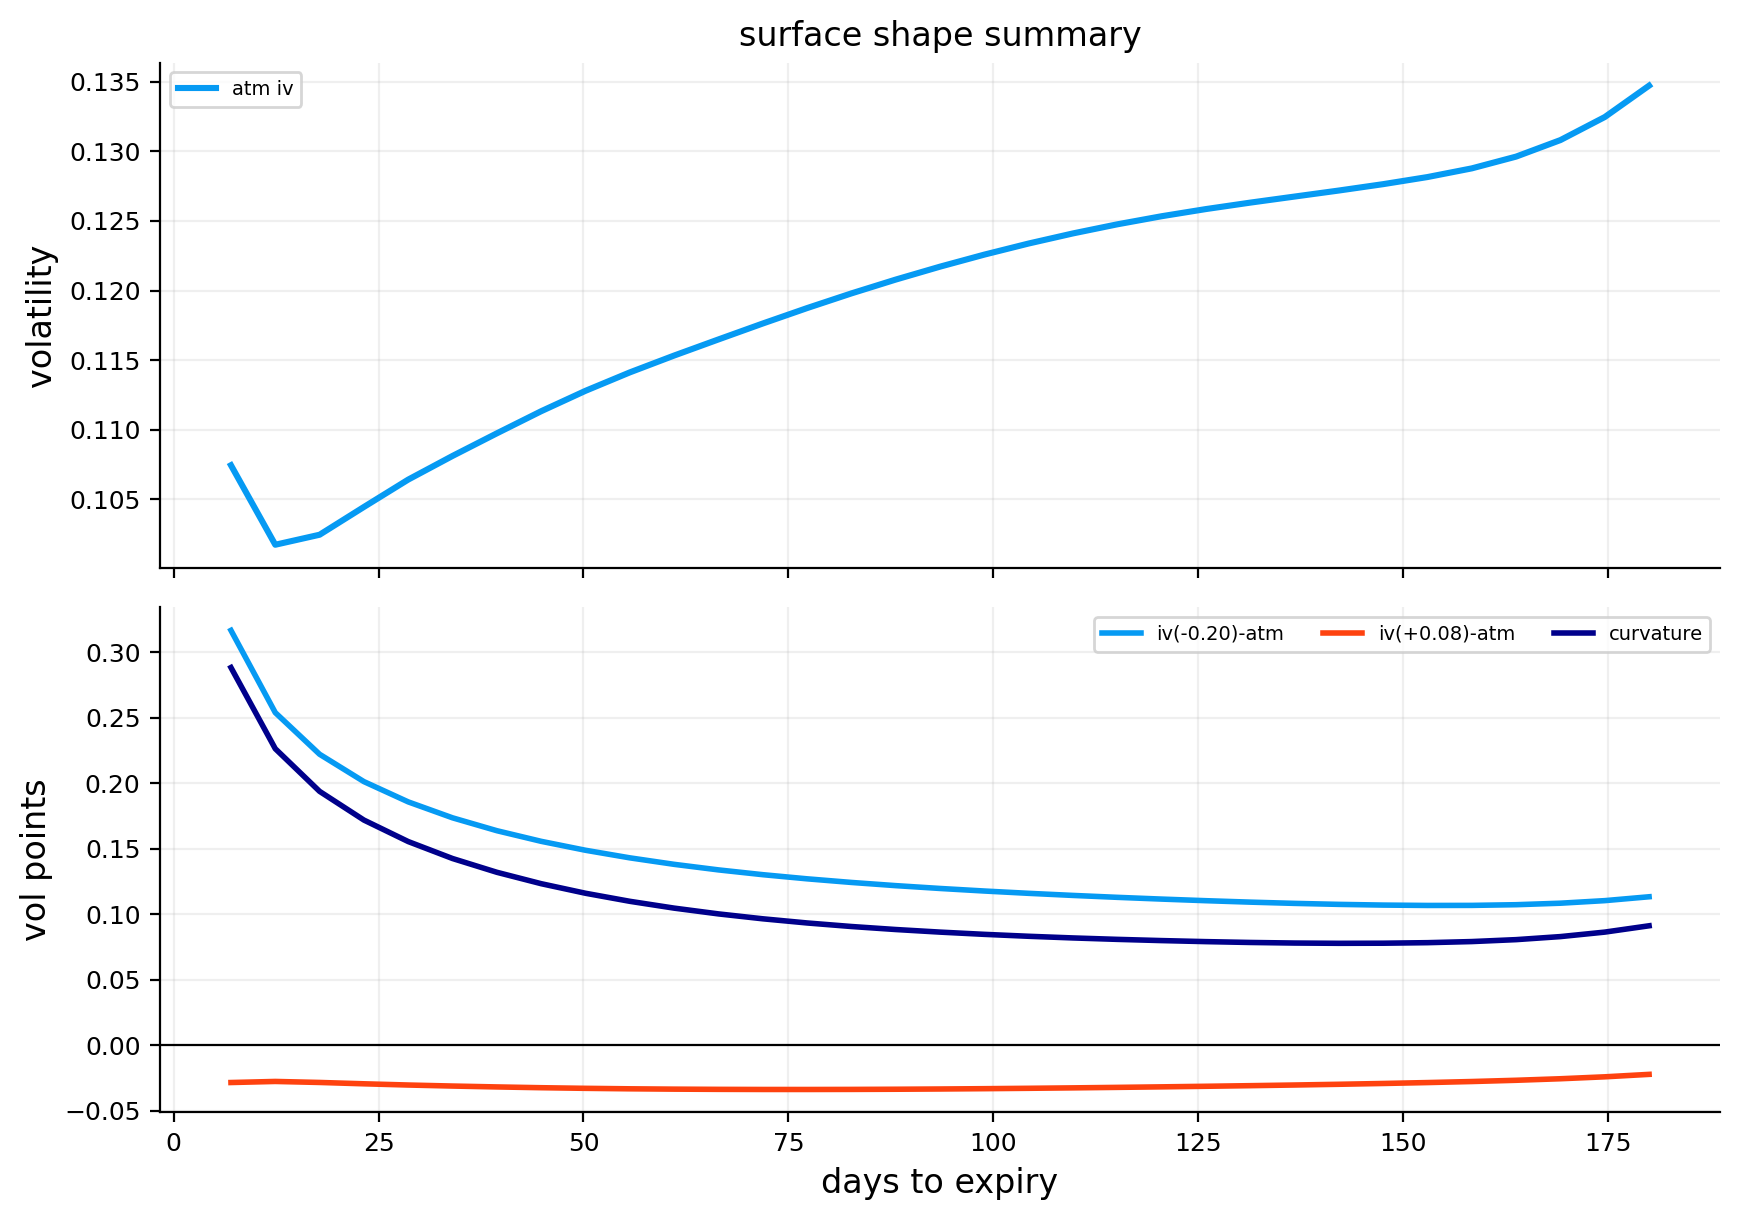

In [20]:
def shape_table(fit, tau_values):
    tau_values = np.asarray(tau_values, dtype=float)
    atm = iv_points(fit, np.full_like(tau_values, shape_k_atm), tau_values)
    down = iv_points(fit, np.full_like(tau_values, shape_k_down), tau_values)
    up = iv_points(fit, np.full_like(tau_values, shape_k_up), tau_values)
    out = pd.DataFrame({
        "tau_days": tau_values * ann_days,
        "atm_iv": atm,
        "downside_skew": down - atm,
        "upside_skew": up - atm,
        "curvature": down + up - 2.0 * atm,
        "smile_asymmetry": (down - atm) - (up - atm),
    })
    out["term_slope_from_front"] = out["atm_iv"] - out["atm_iv"].iloc[0]
    return out


shape_main = shape_table(fit_visual, tau_fit_grid)
display(shape_main.iloc[::4].reset_index(drop=True))

fig, axes = plt.subplots(2, 1, figsize=(8.8, 6.2), sharex=True)
axes[0].plot(shape_main["tau_days"], shape_main["atm_iv"], lw=2.2, label="atm iv")
axes[0].set_title("surface shape summary")
axes[0].set_ylabel("volatility")
axes[0].legend()
axes[1].plot(shape_main["tau_days"], shape_main["downside_skew"], lw=2.0, label=f"iv({shape_k_down:+.2f})-atm")
axes[1].plot(shape_main["tau_days"], shape_main["upside_skew"], lw=2.0, label=f"iv({shape_k_up:+.2f})-atm")
axes[1].plot(shape_main["tau_days"], shape_main["curvature"], lw=2.0, label="curvature")
axes[1].axhline(0.0, color="black", lw=0.8)
axes[1].set_xlabel("days to expiry")
axes[1].set_ylabel("vol points")
axes[1].legend(ncol=3)
plt.tight_layout()
plt.show()


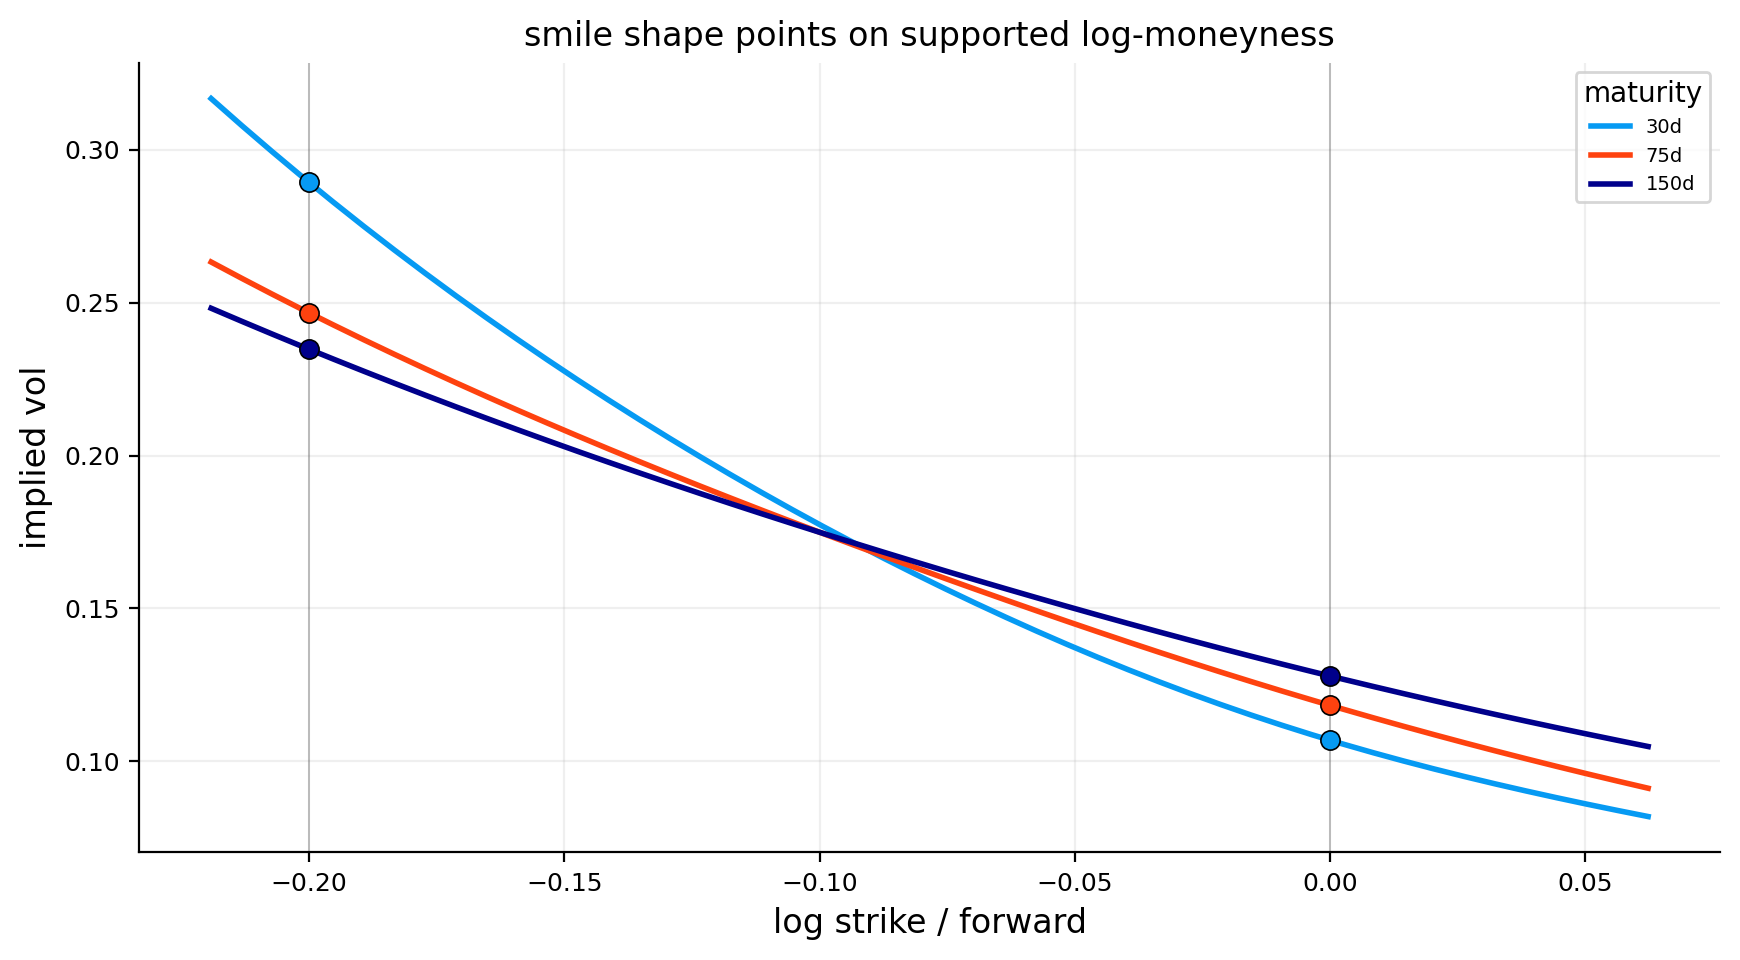

In [21]:
k_plot_lo = max(limits_main["k_lo"], -0.22)
k_plot_hi = min(limits_main["k_hi"], 0.08)
k_shape_plot = np.linspace(k_plot_lo, k_plot_hi, 48)
shape_marks = np.array([shape_k_down, shape_k_atm, shape_k_up], dtype=float)
shape_marks = shape_marks[(shape_marks >= k_plot_lo) & (shape_marks <= k_plot_hi)]

fig, ax = plt.subplots(figsize=(8.8, 4.9))
for n, day in enumerate([30, 75, 150]):
    tau = day / ann_days
    y = iv_points(fit_visual, k_shape_plot, np.full_like(k_shape_plot, tau))
    ax.plot(k_shape_plot, y, lw=2.0, color=lab_colors[n], label=f"{day}d")
    if len(shape_marks):
        mark_y = iv_points(fit_visual, shape_marks, np.full_like(shape_marks, tau))
        ax.scatter(shape_marks, mark_y, s=48, color=lab_colors[n], edgecolor="black", linewidth=0.6, zorder=4)
for x in shape_marks:
    ax.axvline(x, color="black", lw=0.7, alpha=0.22)
ax.set_title("smile shape points on supported log-moneyness")
ax.set_xlabel("log strike / forward")
ax.set_ylabel("implied vol")
ax.legend(title="maturity")
plt.tight_layout()
plt.show()


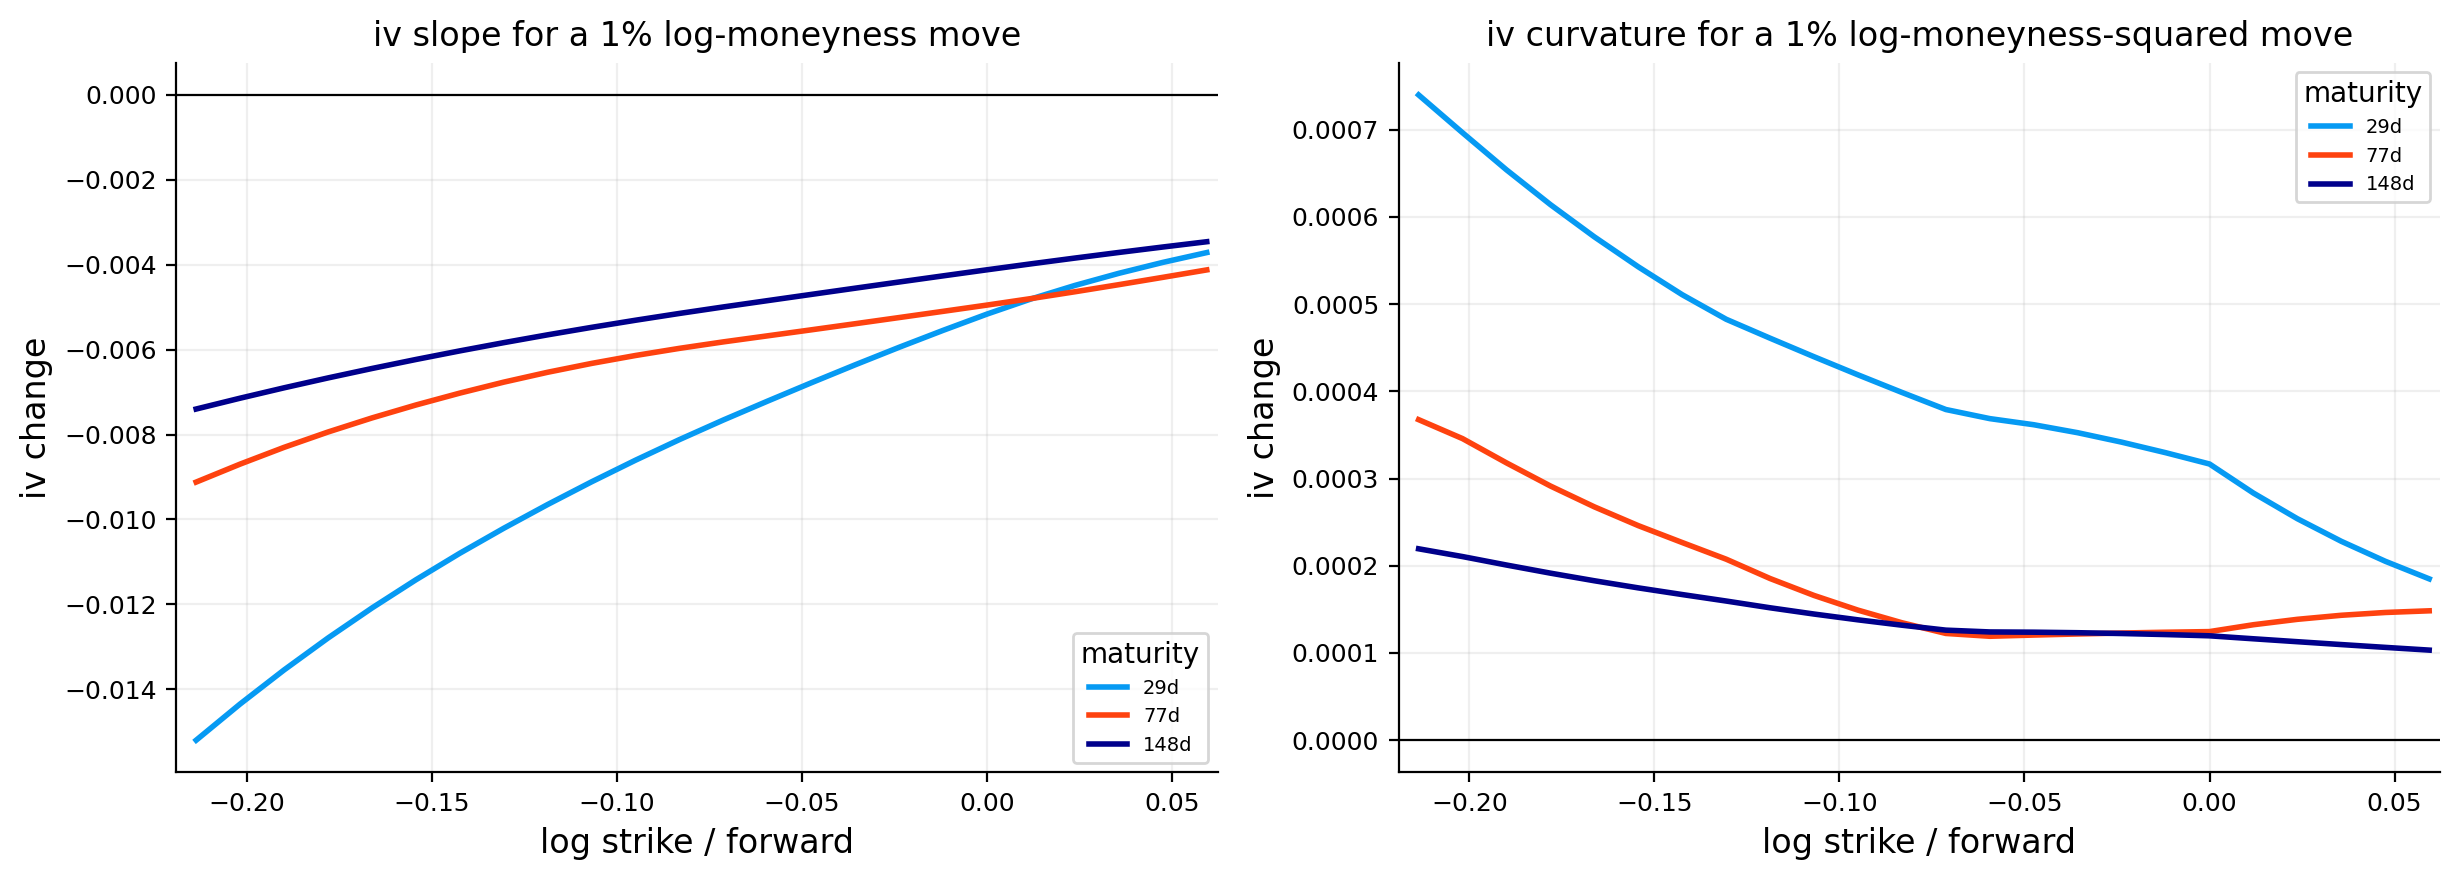

In [22]:
logw = logw_grid(fit_dupire, k_fit_grid, tau_fit_grid)
logw_k = logw_grid(fit_dupire, k_fit_grid, tau_fit_grid, der_k=1)
logw_kk = logw_grid(fit_dupire, k_fit_grid, tau_fit_grid, der_k=2)
logw_t = logw_grid(fit_dupire, k_fit_grid, tau_fit_grid, der_tau=1)
iv_smooth = np.sqrt(np.exp(np.clip(logw, -40.0, 5.0)) / tau_fit_grid[:, None])
iv_k = 0.5 * iv_smooth * logw_k
iv_kk = iv_smooth * (0.50 * logw_kk + 0.25 * logw_k ** 2)
iv_t = iv_smooth * (0.50 * logw_t - 0.50 / tau_fit_grid[:, None])
slope_1pct = masked_grid(iv_k * 0.01, main_support_mask)
curv_1pct2 = masked_grid(iv_kk * (0.01 ** 2), main_support_mask)
term_30d = masked_grid(iv_t * (30.0 / ann_days), main_support_mask)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.5), sharex=True)
for day in [30, 75, 150]:
    idx = int(np.argmin(np.abs(tau_fit_grid * ann_days - day)))
    support_line = main_support_mask[idx]
    y1 = slope_1pct[idx].copy()
    y2 = curv_1pct2[idx].copy()
    y1[~support_line] = np.nan
    y2[~support_line] = np.nan
    axes[0].plot(k_fit_grid, y1, lw=2.0, label=f"{tau_fit_grid[idx] * ann_days:.0f}d")
    axes[1].plot(k_fit_grid, y2, lw=2.0, label=f"{tau_fit_grid[idx] * ann_days:.0f}d")
axes[0].axhline(0.0, color="black", lw=0.8)
axes[1].axhline(0.0, color="black", lw=0.8)
axes[0].set_title("iv slope for a 1% log-moneyness move")
axes[1].set_title("iv curvature for a 1% log-moneyness-squared move")
for ax in axes:
    ax.set_xlim(limits_main["k_lo"], limits_main["k_hi"])
    ax.set_xlabel("log strike / forward")
    ax.legend(title="maturity")
axes[0].set_ylabel("iv change")
axes[1].set_ylabel("iv change")
plt.tight_layout()
plt.show()


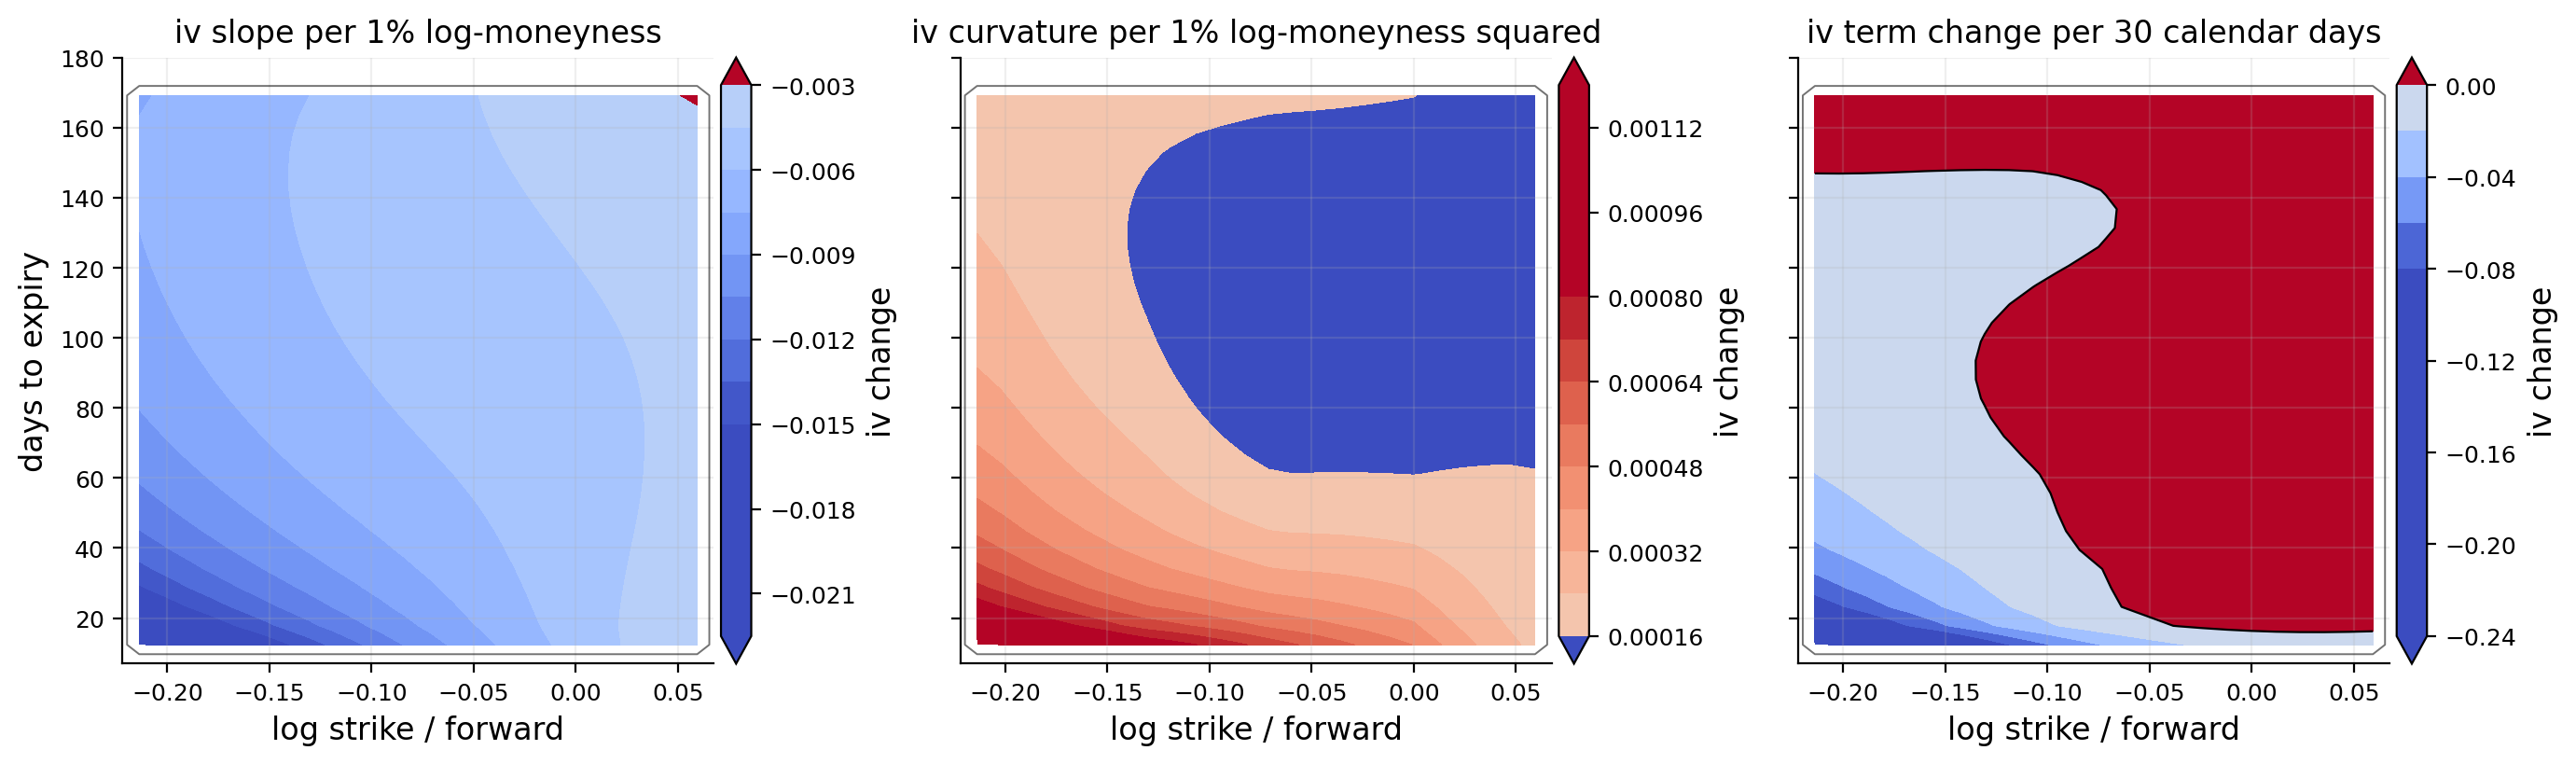

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.2), sharey=True)
items = [
    (slope_1pct, "iv slope per 1% log-moneyness", "iv change"),
    (curv_1pct2, "iv curvature per 1% log-moneyness squared", "iv change"),
    (term_30d, "iv term change per 30 calendar days", "iv change"),
]
for ax, (arr, title, label) in zip(axes, items):
    lim = robust_abs_limit(arr, main_support_mask, q=0.98)
    cf = ax.contourf(k_fit_grid, tau_fit_grid * ann_days, arr, levels=17, cmap="coolwarm", norm=two_slope_norm(vcenter=0.0, vmin=-lim, vmax=lim), extend="both")
    ax.contour(k_fit_grid, tau_fit_grid * ann_days, arr, levels=[0.0], colors="black", linewidths=0.8)
    ax.contour(k_fit_grid, tau_fit_grid * ann_days, main_support_mask.astype(float), levels=[0.5], colors="black", linewidths=0.7, alpha=0.55)
    ax.set_title(title)
    set_supported_xlim(ax, k_fit_grid, main_support_mask)
    ax.set_xlabel("log strike / forward")
    fig.colorbar(cf, ax=ax, pad=0.01, label=label)
axes[0].set_ylabel("days to expiry")
plt.tight_layout()
plt.show()


In [24]:
lv_main = dupire_from_fit(fit_dupire, q_main, tau_lv_grid, k_lv_grid)
dupire_main = pd.DataFrame([dupire_metrics(lv_main, downside_k=shape_k_down)])
region_main = lv_main["support_mask"] & (~lv_main["boundary_mask"])
quality_rows = pd.DataFrame([{
    "supported_grid_share": float(lv_main["support_mask"].mean()),
    "fitted_iv_finite_share": float(np.isfinite(lv_main["iv_grid"][lv_main["support_mask"]]).mean()),
    "total_variance_maturity_violation_share": float(np.nanmean(np.diff((lv_main["iv_grid"] ** 2) * lv_main["tau_grid"][:, None], axis=0)[1:-1, 1:-1] < -1e-5)),
    "call_price_strike_monotonicity_violation_share": float(np.nanmean(np.diff(lv_main["price_grid"], axis=1)[region_main[:, 1:]] > 1e-6)),
    "negative_density_share": dupire_main["dupire_negative_density_share"].iloc[0],
    "hard_invalid_share": dupire_main["dupire_hard_invalid_share"].iloc[0],
    "extreme_ratio_share": dupire_main["dupire_extreme_ratio_share"].iloc[0],
    "total_flagged_share": dupire_main["dupire_total_flagged_share"].iloc[0],
}])
display(quality_rows)
display(dupire_main)


,supported_grid_share,fitted_iv_finite_share,total_variance_maturity_violation_share,call_price_strike_monotonicity_violation_share,negative_density_share,hard_invalid_share,extreme_ratio_share,total_flagged_share
0,0.787260,1.000000,0.000000,0.000000,0.000000,0.028452,0.016736,0.045188


,engine_used,fallback_used,dupire_hard_invalid_share,dupire_hard_invalid_other_share,dupire_negative_var_share,dupire_negative_density_share,dupire_extreme_ratio_share,dupire_total_flagged_share,dupire_median_lv_to_iv,dupire_median_abs_lv_to_iv_minus_1,dupire_atm_local_vol_level,dupire_downside_local_vol_premium,dupire_upside_local_vol_premium,dupire_stress
0,jax,False,0.028452,0.028452,0.028452,0.000000,0.016736,0.045188,1.222506,0.231118,0.140121,0.246091,-0.051530,0.156563


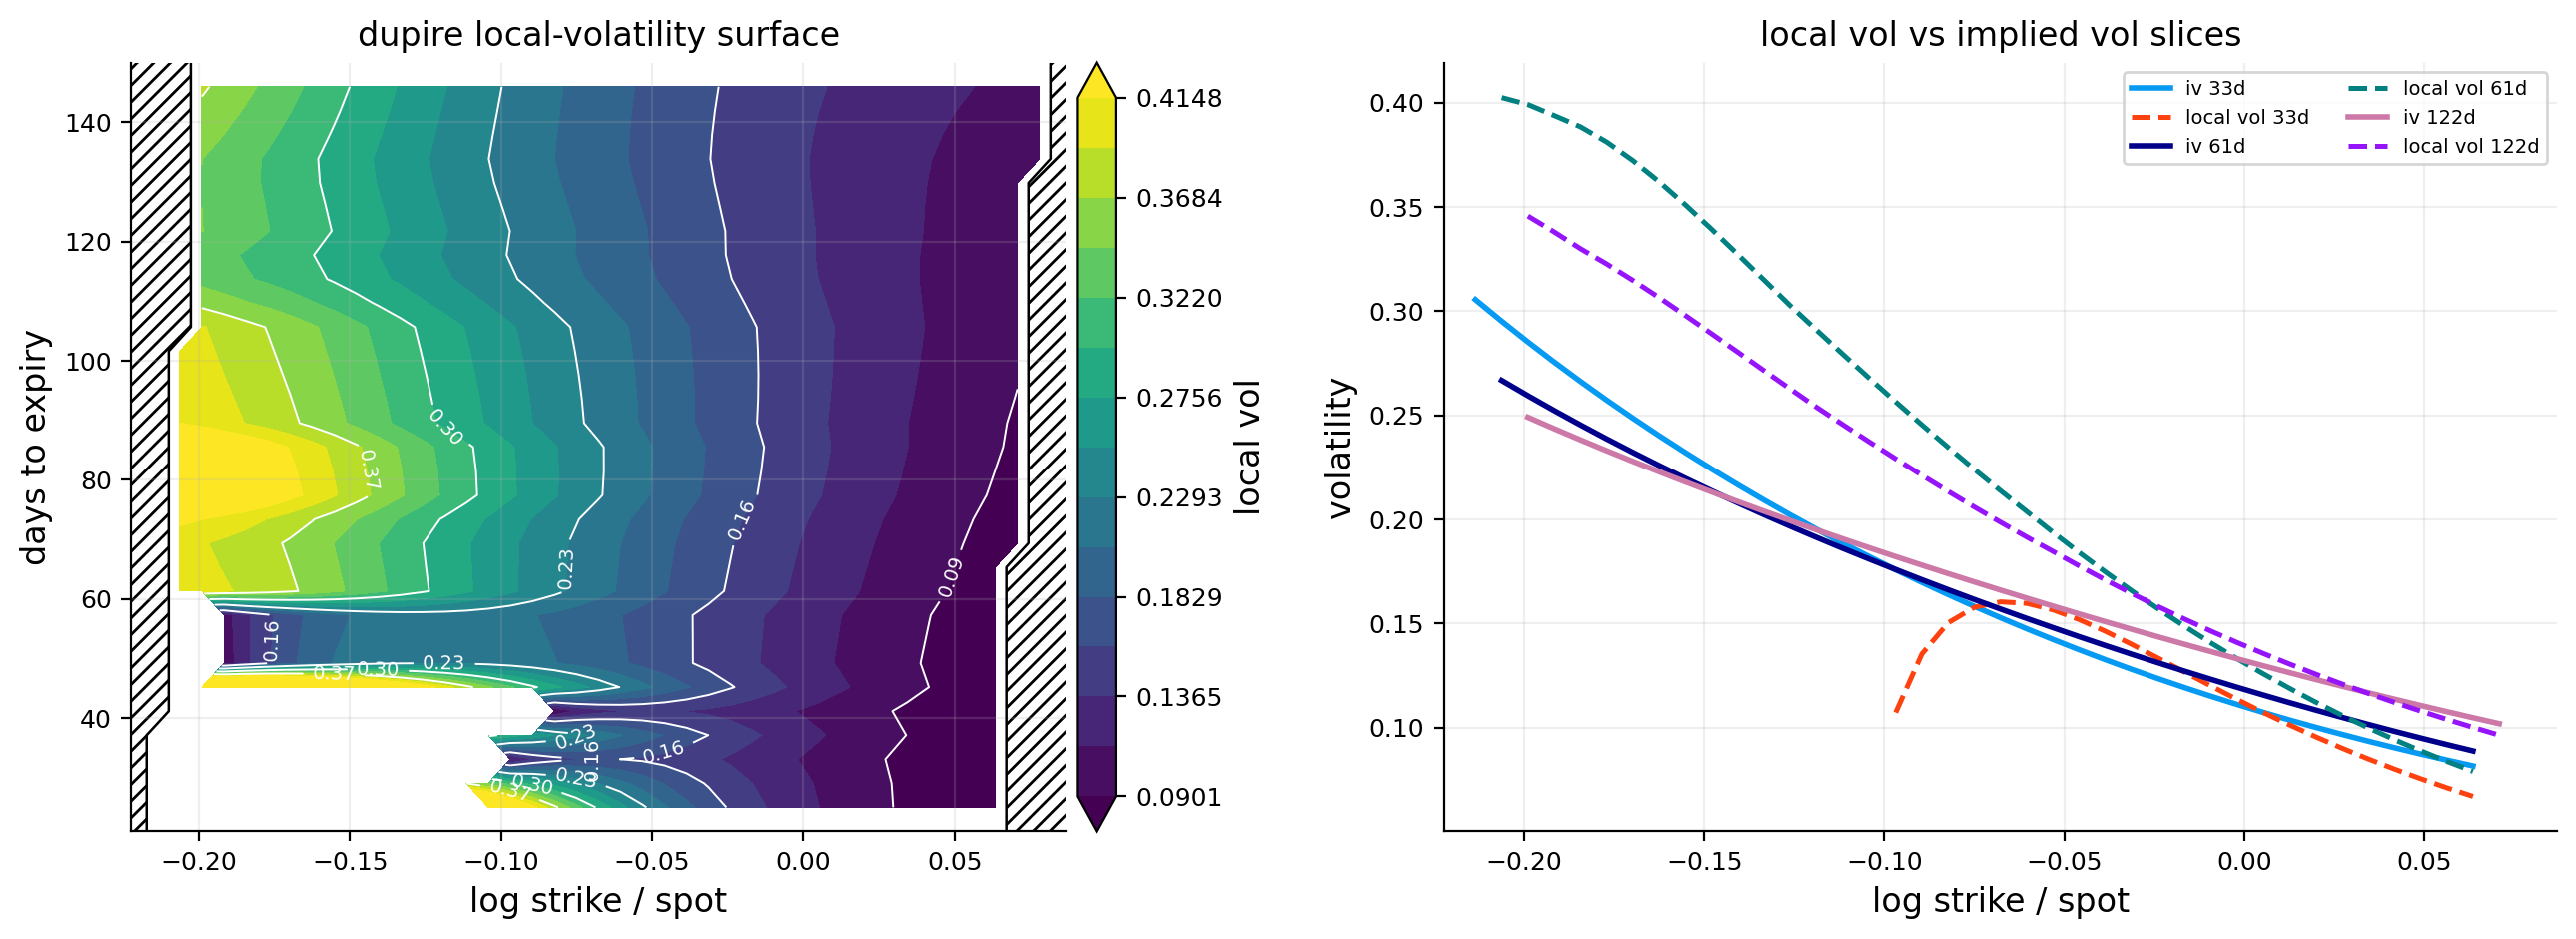

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8), sharey=False)
lv_plot = lv_main["local_vol"]
lv_k_mask = lv_main["support_mask"].any(axis=0)
lv_levels = np.linspace(np.nanpercentile(lv_plot, 5), np.nanpercentile(lv_plot, 95), 15)
cf = axes[0].contourf(lv_main["k_grid"], lv_main["tau_grid"] * ann_days, lv_plot, levels=lv_levels, cmap="viridis", extend="both")
cs = axes[0].contour(lv_main["k_grid"], lv_main["tau_grid"] * ann_days, lv_plot, levels=lv_levels[::3], colors="white", linewidths=0.7)
axes[0].contour(lv_main["k_grid"], lv_main["tau_grid"] * ann_days, lv_main["support_mask"].astype(float), levels=[0.5], colors="black", linewidths=0.9)
axes[0].contourf(lv_main["k_grid"], lv_main["tau_grid"] * ann_days, (~lv_main["support_mask"]).astype(float), levels=[0.5, 1.5], colors="none", hatches=["////"], alpha=0.0)
axes[0].clabel(cs, fmt="%.2f", fontsize=7)
axes[0].set_title("dupire local-volatility surface")
axes[0].set_xlabel("log strike / spot")
axes[0].set_ylabel("days to expiry")
set_supported_xlim(axes[0], lv_main["k_grid"], lv_k_mask)
fig.colorbar(cf, ax=axes[0], pad=0.01, label="local vol")

for day in [35, 60, 120]:
    idx = int(np.argmin(np.abs(lv_main["tau_grid"] * ann_days - day)))
    x = lv_main["k_grid"]
    axes[1].plot(x, lv_main["iv_grid"][idx], lw=2.0, label=f"iv {lv_main['tau_grid'][idx] * ann_days:.0f}d")
    axes[1].plot(x, lv_main["local_vol"][idx], lw=1.8, ls="--", label=f"local vol {lv_main['tau_grid'][idx] * ann_days:.0f}d")
set_supported_xlim(axes[1], lv_main["k_grid"], lv_k_mask)
axes[1].set_title("local vol vs implied vol slices")
axes[1].set_xlabel("log strike / spot")
axes[1].set_ylabel("volatility")
axes[1].legend(ncol=2, fontsize=7)
plt.tight_layout()
plt.show()


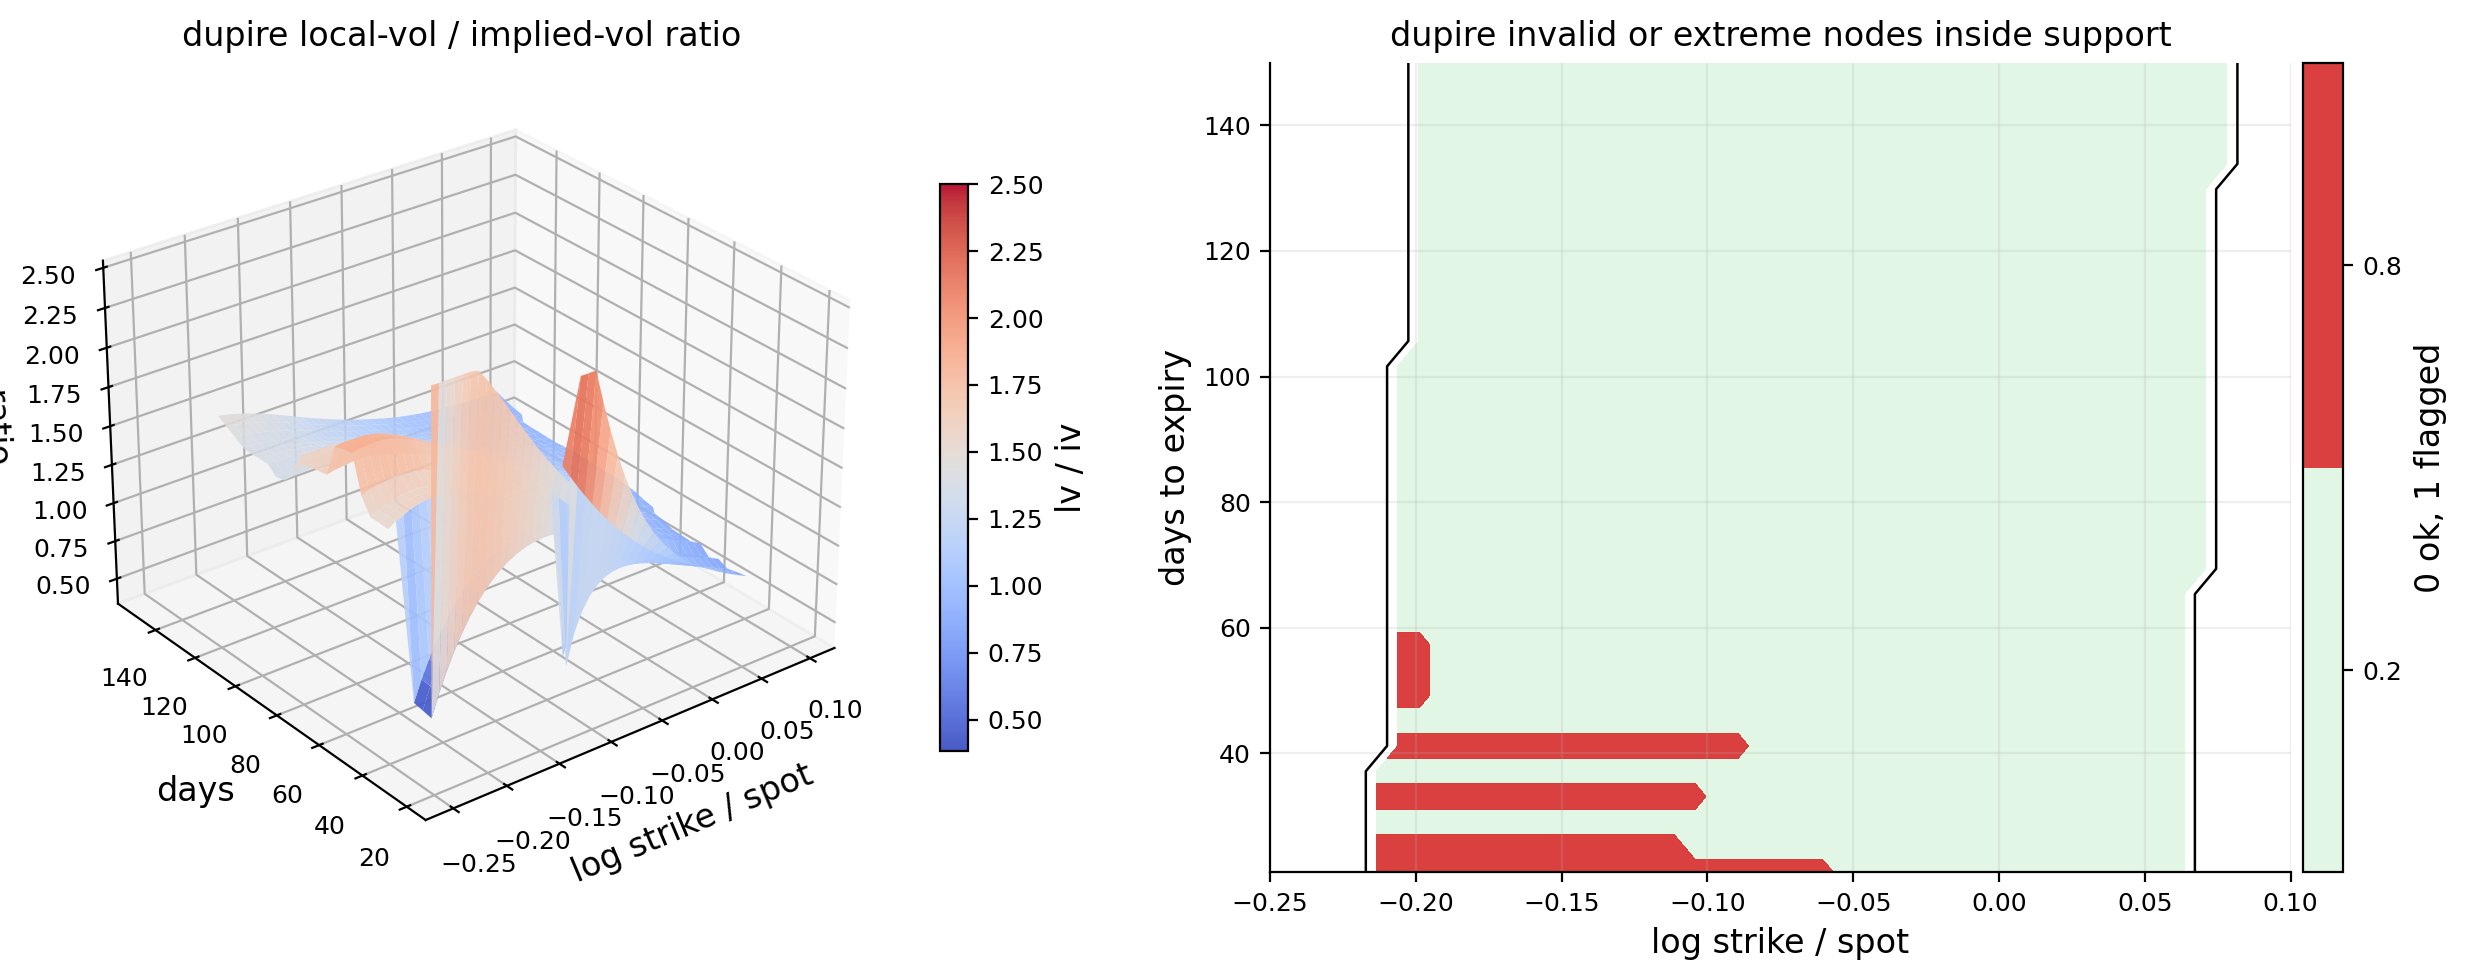

In [26]:
fig = plt.figure(figsize=(13.2, 5.0))
ax0 = fig.add_subplot(1, 2, 1, projection="3d")
k_mesh_lv, tau_mesh_lv = np.meshgrid(lv_main["k_grid"], lv_main["tau_grid"] * ann_days)
ratio_plot = np.ma.masked_invalid(np.clip(lv_main["local_vol_to_iv"], 0.35, 2.50))
surf_lv = ax0.plot_surface(k_mesh_lv, tau_mesh_lv, ratio_plot, cmap="coolwarm", linewidth=0, alpha=0.92)
ax0.set_title("dupire local-vol / implied-vol ratio")
ax0.set_xlabel("log strike / spot")
ax0.set_ylabel("days")
ax0.set_zlabel("ratio")
ax0.view_init(elev=28, azim=-128)
fig.colorbar(surf_lv, ax=ax0, shrink=0.70, pad=0.06, label="lv / iv")

ax1 = fig.add_subplot(1, 2, 2)
mask_show = np.where(lv_main["support_mask"], lv_main["hard_invalid_mask"] | lv_main["extreme_ratio_mask"], np.nan)
cf = ax1.contourf(lv_main["k_grid"], lv_main["tau_grid"] * ann_days, mask_show, levels=[-0.1, 0.5, 1.1], colors=["#d8f3dc", "#d00000"], alpha=0.75)
ax1.contour(lv_main["k_grid"], lv_main["tau_grid"] * ann_days, lv_main["support_mask"].astype(float), levels=[0.5], colors="black", linewidths=0.9)
ax1.set_title("dupire invalid or extreme nodes inside support")
ax1.set_xlabel("log strike / spot")
ax1.set_ylabel("days to expiry")
fig.colorbar(cf, ax=ax1, pad=0.01, ticks=[0.2, 0.8], label="0 ok, 1 flagged")
plt.tight_layout()
plt.show()


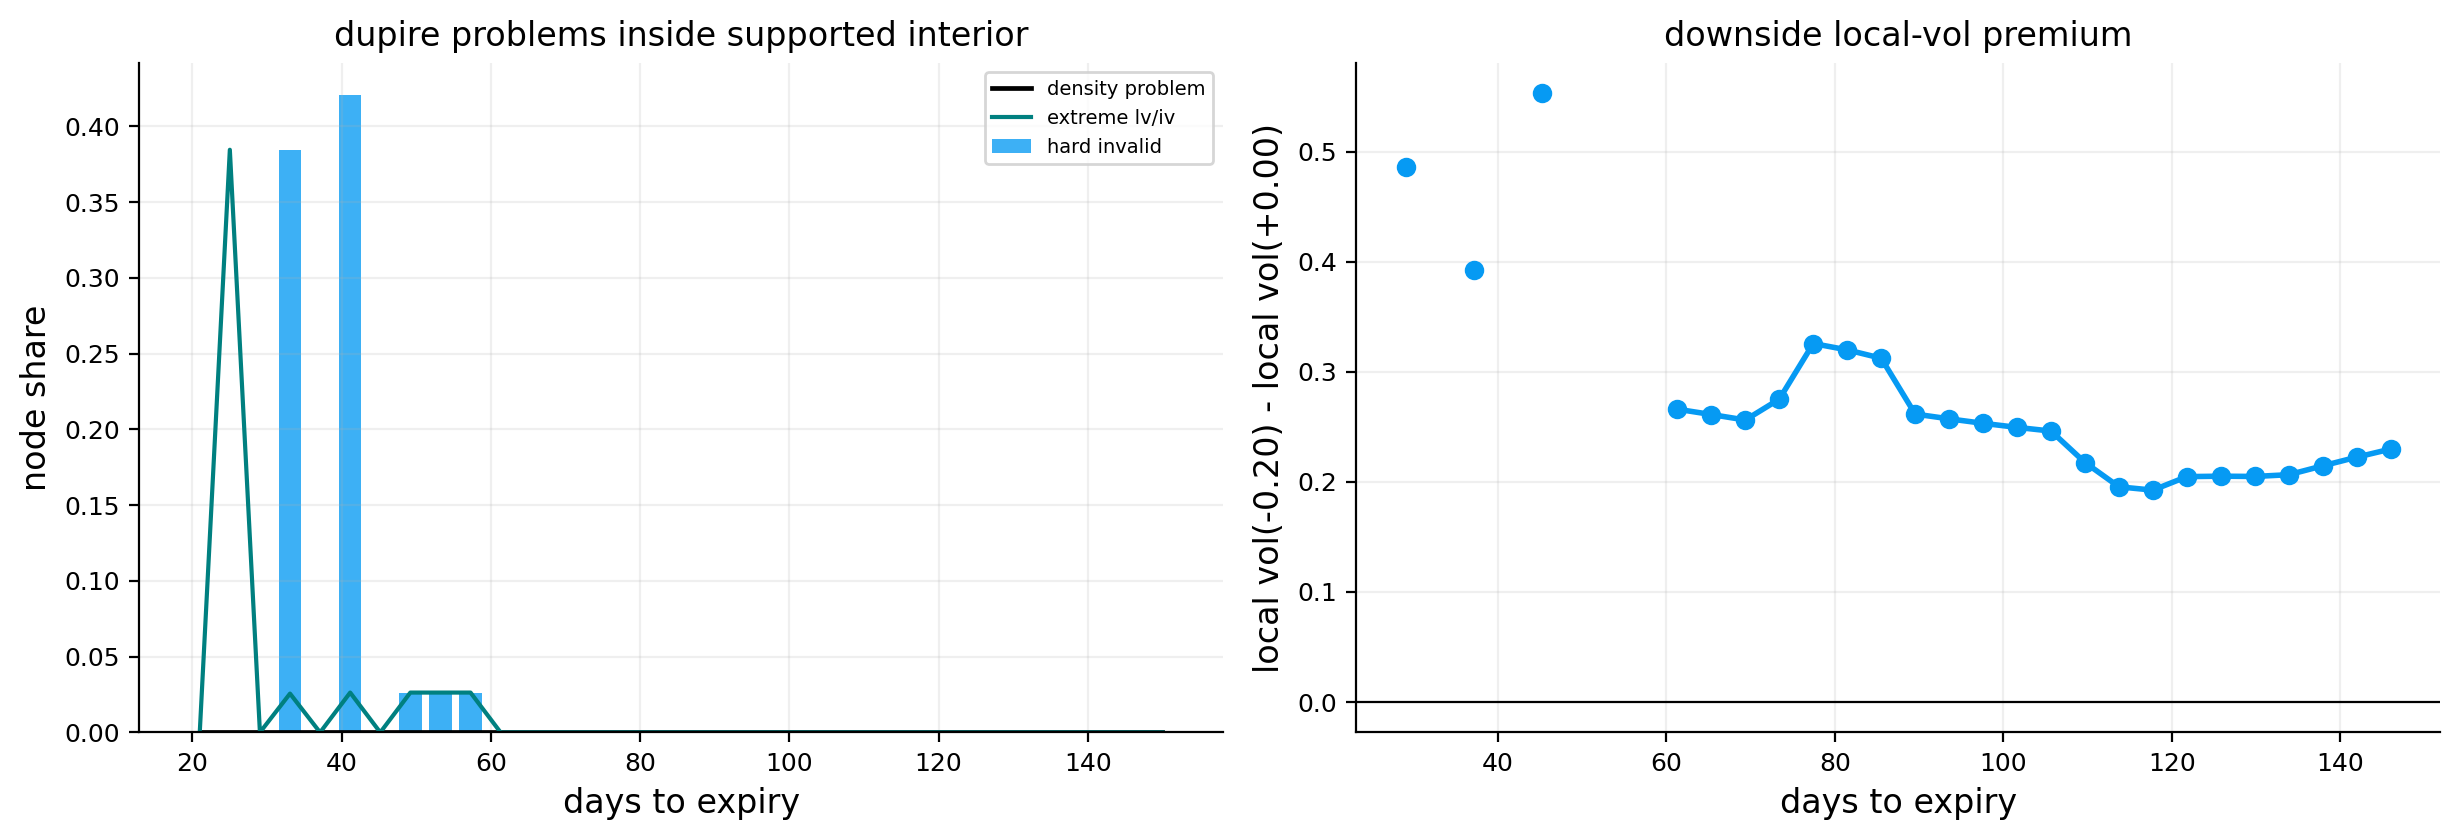

In [27]:
region_main = lv_main["support_mask"] & (~lv_main["boundary_mask"])
invalid_by_tau = []
for i, tau in enumerate(lv_main["tau_grid"]):
    row = region_main[i]
    denom = max(int(row.sum()), 1)
    invalid_by_tau.append({
        "tau_days": tau * ann_days,
        "hard_invalid_share": float(lv_main["hard_invalid_mask"][i, row].sum() / denom),
        "negative_density_share": float(lv_main["negative_density_mask"][i, row].sum() / denom),
        "extreme_ratio_share": float(lv_main["extreme_ratio_mask"][i, row].sum() / denom),
    })
invalid_by_tau = pd.DataFrame(invalid_by_tau)
stress_line = row_at_k(lv_main["local_vol"], lv_main["k_grid"], shape_k_down) - row_at_k(lv_main["local_vol"], lv_main["k_grid"], shape_k_atm)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.3))
axes[0].bar(invalid_by_tau["tau_days"], invalid_by_tau["hard_invalid_share"], width=3.0, alpha=0.78, label="hard invalid")
axes[0].plot(invalid_by_tau["tau_days"], invalid_by_tau["negative_density_share"], color="black", lw=1.7, label="density problem")
axes[0].plot(invalid_by_tau["tau_days"], invalid_by_tau["extreme_ratio_share"], color=lab_colors[3], lw=1.5, label="extreme lv/iv")
axes[0].set_title("dupire problems inside supported interior")
axes[0].set_xlabel("days to expiry")
axes[0].set_ylabel("node share")
axes[0].legend()
axes[1].plot(lv_main["tau_grid"] * ann_days, stress_line, marker="o", lw=2.0)
axes[1].axhline(0.0, color="black", lw=0.8)
axes[1].set_title("downside local-vol premium")
axes[1].set_xlabel("days to expiry")
axes[1].set_ylabel(f"local vol({shape_k_down:+.2f}) - local vol({shape_k_atm:+.2f})")
plt.tight_layout()
plt.show()


In [28]:
def feature_row(date, fit, q, metrics, dupire):
    short_tau, mid_tau, long_tau = np.array([30.0, 75.0, 150.0]) / ann_days
    atm = iv_points(fit, np.array([0.0, 0.0, 0.0]), np.array([short_tau, mid_tau, long_tau]))
    down = iv_points(fit, np.full(3, shape_k_down_hist), np.array([short_tau, mid_tau, long_tau]))
    up = iv_points(fit, np.array([0.08, 0.08, 0.08]), np.array([short_tau, mid_tau, long_tau]))
    row = {
        "date": pd.Timestamp(date).normalize(),
        "short_atm_iv": float(atm[0]),
        "medium_atm_iv": float(atm[1]),
        "long_atm_iv": float(atm[2]),
        "term_slope": float(atm[2] - atm[0]),
        "downside_skew": float(down[1] - atm[1]),
        "upside_skew": float(up[1] - atm[1]),
        "curvature": float(down[1] + up[1] - 2.0 * atm[1]),
        "smile_asymmetry": float((down[1] - atm[1]) - (up[1] - atm[1])),
        "fit_rmse": float(metrics["rmse"]),
        "quote_count": int(metrics["quote_count"]),
        "number_of_maturities": int(metrics["number_of_maturities"]),
    }
    row.update(dupire)
    return row


hist_tic = time.perf_counter()
fit_store_visual = {}
fit_store_dupire = {}
fit_rows = []
feature_rows = []
iv_list = []
support_list = []
fit_dates = []
skip_rows = []
hist_tau_lv = tau_risk_grid
hist_k_lv = k_risk_grid
for n, date in enumerate(valid_dates.index):
    q_date = surface[surface["date"].eq(date)].copy()
    if len(q_date) < 160 or q_date["expiry"].nunique() < 5:
        skip_rows.append({"date": date, "success": False, "error": "too few quotes or maturities"})
        continue
    try:
        fit_v = fit_total_var(q_date, n_k=15, n_tau=9, lambda_k=28.0, lambda_tau=55.0, label="visual")
        fit_d = fit_total_var(q_date, n_k=15, n_tau=9, lambda_k=dupire_lambda_k, lambda_tau=dupire_lambda_tau, label="dupire")
        grid_v = iv_grid(fit_v, k_safe_grid, tau_safe_grid)
        supp = support_mask_for_grid(q_date, k_safe_grid, tau_safe_grid)
        grid_v = masked_grid(grid_v, supp)
        if np.isfinite(grid_v[supp]).mean() < 0.98:
            raise ValueError("unreasonable support-safe visual grid")
        met_v = fit_metrics(fit_v, q_date, "visual")
        met_d = fit_metrics(fit_d, q_date, "dupire")
        lv = dupire_from_fit(fit_d, q_date, hist_tau_lv, hist_k_lv)
        dup = dupire_metrics(lv, downside_k=shape_k_down_hist)
        date_key = pd.Timestamp(date).normalize()
        fit_store_visual[date_key] = fit_v
        fit_store_dupire[date_key] = fit_d
        fit_rows.append({**met_v.to_dict(), "fit": "visual"})
        fit_rows.append({**met_d.to_dict(), "fit": "dupire"})
        feature_rows.append(feature_row(date, fit_v, q_date, met_v, dup))
        iv_list.append(grid_v)
        support_list.append(supp)
        fit_dates.append(date_key)
    except Exception as exc:
        skip_rows.append({"date": date, "success": False, "error": str(exc)[:160]})
    if (n + 1) % 50 == 0:
        print(f"historical surface fits: {n + 1}/{len(valid_dates)}")

iv_cube = np.asarray(iv_list, dtype=float)
support_cube = np.asarray(support_list, dtype=bool)
fit_dates = pd.to_datetime(pd.Index(fit_dates))
fit_log = pd.DataFrame(fit_rows).sort_values(["date", "fit"]).reset_index(drop=True)
features = pd.DataFrame(feature_rows).sort_values("date").reset_index(drop=True)
skipped = pd.DataFrame(skip_rows)
print(f"successful fitted dates: {len(fit_dates):,}; skipped dates: {len(skipped):,}; seconds: {time.perf_counter() - hist_tic:,.1f}")
display(fit_log.groupby("fit").describe().T.loc[(slice(None), ["mean", "std", "min", "50%", "max"]), :])


historical surface fits: 50/505
historical surface fits: 100/505
historical surface fits: 150/505
historical surface fits: 200/505
historical surface fits: 250/505
historical surface fits: 300/505
historical surface fits: 350/505
historical surface fits: 400/505
historical surface fits: 450/505
historical surface fits: 500/505
successful fitted dates: 505; skipped dates: 0; seconds: 84.3


fit                    dupire       visual
quote_count mean 4,748.998020 4,748.998020
            std    570.339451   570.339451
            min  3,598.000000 3,598.000000
            50%  4,972.000000 4,972.000000
            max  5,714.000000 5,714.000000
...                       ...          ...
max_dte     mean   171.515512   171.515512
            std      4.932730     4.932730
            min    159.333333   159.333333
            50%    171.333333   171.333333
            max    179.333333   179.333333

[65 rows x 2 columns]

In [29]:
display(pd.DataFrame([{
    "successful_dates": len(fit_dates),
    "skipped_dates": len(skipped),
    "first_fit_date": fit_dates.min().date() if len(fit_dates) else None,
    "last_fit_date": fit_dates.max().date() if len(fit_dates) else None,
}]))


,successful_dates,skipped_dates,first_fit_date,last_fit_date
0,505,0,2022-01-03,2023-12-29


,support_threshold,kept_nodes,total_nodes,kept_share,k_min_kept,k_max_kept
0,0.850000,675,1225,0.551020,-0.133333,0.056250


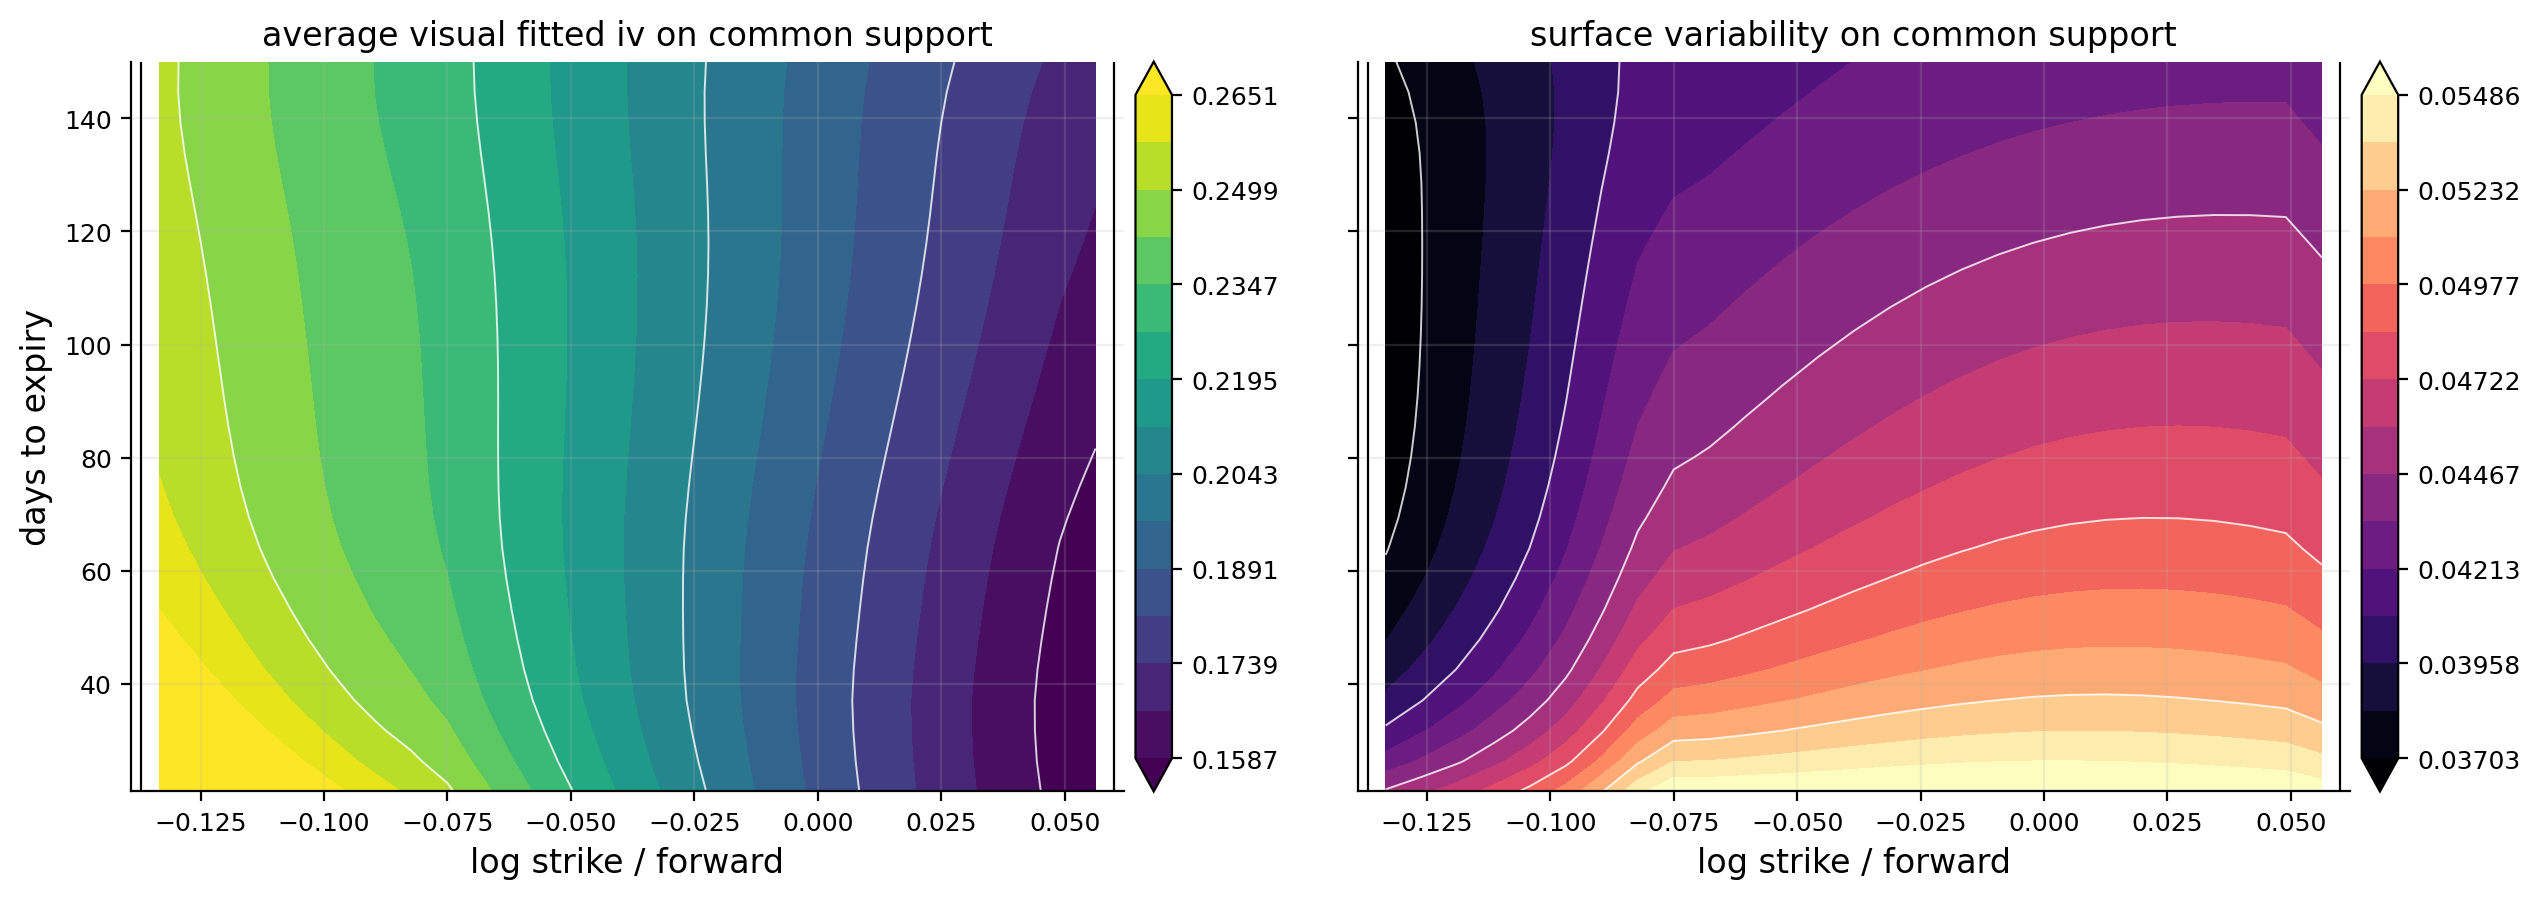

In [30]:
node_support_share = support_cube.mean(axis=0) if len(support_cube) else np.zeros((len(tau_safe_grid), len(k_safe_grid)), dtype=float)
common_node_mask = node_support_share >= 0.85
if common_node_mask.sum() < 120:
    common_node_mask = node_support_share >= 0.75
iv_common = iv_cube.copy()
iv_common[:, ~common_node_mask] = np.nan
iv_mean = np.nanmean(iv_common, axis=0)
iv_std = np.nanstd(iv_common, axis=0)
common_support_summary = pd.DataFrame([{
    "support_threshold": 0.85 if (node_support_share >= 0.85).sum() >= 120 else 0.75,
    "kept_nodes": int(common_node_mask.sum()),
    "total_nodes": int(common_node_mask.size),
    "kept_share": float(common_node_mask.mean()),
    "k_min_kept": float(np.nanmin(np.where(common_node_mask, k_safe_grid[None, :], np.nan))),
    "k_max_kept": float(np.nanmax(np.where(common_node_mask, k_safe_grid[None, :], np.nan))),
}])
display(common_support_summary)

common_k_mask = common_node_mask.any(axis=0)
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6), sharey=True)
for ax, arr, title, cmap in [(axes[0], iv_mean, "average visual fitted iv on common support", "viridis"), (axes[1], iv_std, "surface variability on common support", "magma")]:
    levels = np.linspace(np.nanpercentile(arr, 3), np.nanpercentile(arr, 97), 15)
    cf = ax.contourf(k_safe_grid, tau_safe_grid * ann_days, arr, levels=levels, cmap=cmap, extend="both")
    ax.contour(k_safe_grid, tau_safe_grid * ann_days, arr, levels=levels[::3], colors="white", linewidths=0.7, alpha=0.8)
    ax.contour(k_safe_grid, tau_safe_grid * ann_days, common_node_mask.astype(float), levels=[0.5], colors="black", linewidths=0.8)
    ax.set_title(title)
    set_supported_xlim(ax, k_safe_grid, common_k_mask)
    ax.set_xlabel("log strike / forward")
    fig.colorbar(cf, ax=ax, pad=0.01)
axes[0].set_ylabel("days to expiry")
plt.tight_layout()
plt.show()


,date,short_atm_iv,medium_atm_iv,long_atm_iv,term_slope,downside_skew,upside_skew,curvature,smile_asymmetry,fit_rmse,quote_count,number_of_maturities,engine_used,fallback_used,dupire_hard_invalid_share,dupire_hard_invalid_other_share,dupire_negative_var_share,dupire_negative_density_share,dupire_extreme_ratio_share,dupire_total_flagged_share,dupire_median_lv_to_iv,dupire_median_abs_lv_to_iv_minus_1,dupire_atm_local_vol_level,dupire_downside_local_vol_premium,dupire_upside_local_vol_premium,dupire_stress
0,2022-01-03,0.125344,0.147044,0.170291,0.044947,0.137266,-0.056885,0.080381,0.194151,0.007703,3775,21,jax,False,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.122270,0.148635,0.169082,0.117102,-0.081023,0.074317
1,2022-01-04,0.127276,0.148917,0.171841,0.044565,0.124340,-0.057013,0.067326,0.181353,0.017620,3898,22,jax,False,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.210194,0.217425,0.171544,0.212200,-0.080674,0.108713
2,2022-01-05,0.155730,0.168384,0.185396,0.029666,0.125541,-0.061568,0.063973,0.187109,0.019974,3733,21,jax,False,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.129312,0.150168,0.181794,0.192715,-0.083412,0.075084
3,2022-01-06,0.155899,0.168683,0.184713,0.028813,0.130345,-0.061945,0.068401,0.192290,0.028134,3935,22,jax,False,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.062817,0.111250,0.180930,0.123081,-0.084364,0.055625
4,2022-01-07,0.151011,0.165860,0.182497,0.031486,0.126397,-0.060965,0.065432,0.187362,0.032448,3859,22,jax,False,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.088453,0.132003,0.180022,0.138937,-0.083803,0.066002
5,2022-01-10,0.154670,0.165203,0.181850,0.027180,0.131004,-0.059985,0.071019,0.190989,0.009957,3959,22,jax,False,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.057726,0.105234,0.176096,0.115794,-0.081255,0.052617
6,2022-01-11,0.148021,0.158180,0.176378,0.028357,0.117831,-0.056437,0.061394,0.174267,0.028571,3934,22,jax,False,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.156138,0.185437,0.171590,0.199050,-0.078629,0.092718
7,2022-01-12,0.144100,0.156006,0.175281,0.031181,0.128128,-0.056527,0.071601,0.184655,0.007724,3751,21,jax,False,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.092843,0.135971,0.169931,0.113413,-0.078771,0.067986


,mean,std,5%,50%,95%
short_atm_iv,0.186473,0.054012,0.110389,0.183362,0.278044
medium_atm_iv,0.188868,0.047861,0.118822,0.189646,0.266518
long_atm_iv,0.193867,0.042800,0.129295,0.196672,0.258952
term_slope,0.007395,0.015953,-0.022741,0.010469,0.028559
downside_skew,0.074051,0.020272,0.042021,0.072384,0.106261
upside_skew,-0.045249,0.008609,-0.061564,-0.043573,-0.032867
curvature,0.028802,0.014924,0.007337,0.028508,0.048114
smile_asymmetry,0.119299,0.027339,0.078885,0.113164,0.167761
fit_rmse,0.012151,0.004426,0.007037,0.010989,0.020778
quote_count,"4,748.998020",570.339451,"3,843.400000","4,972.000000","5,523.400000"


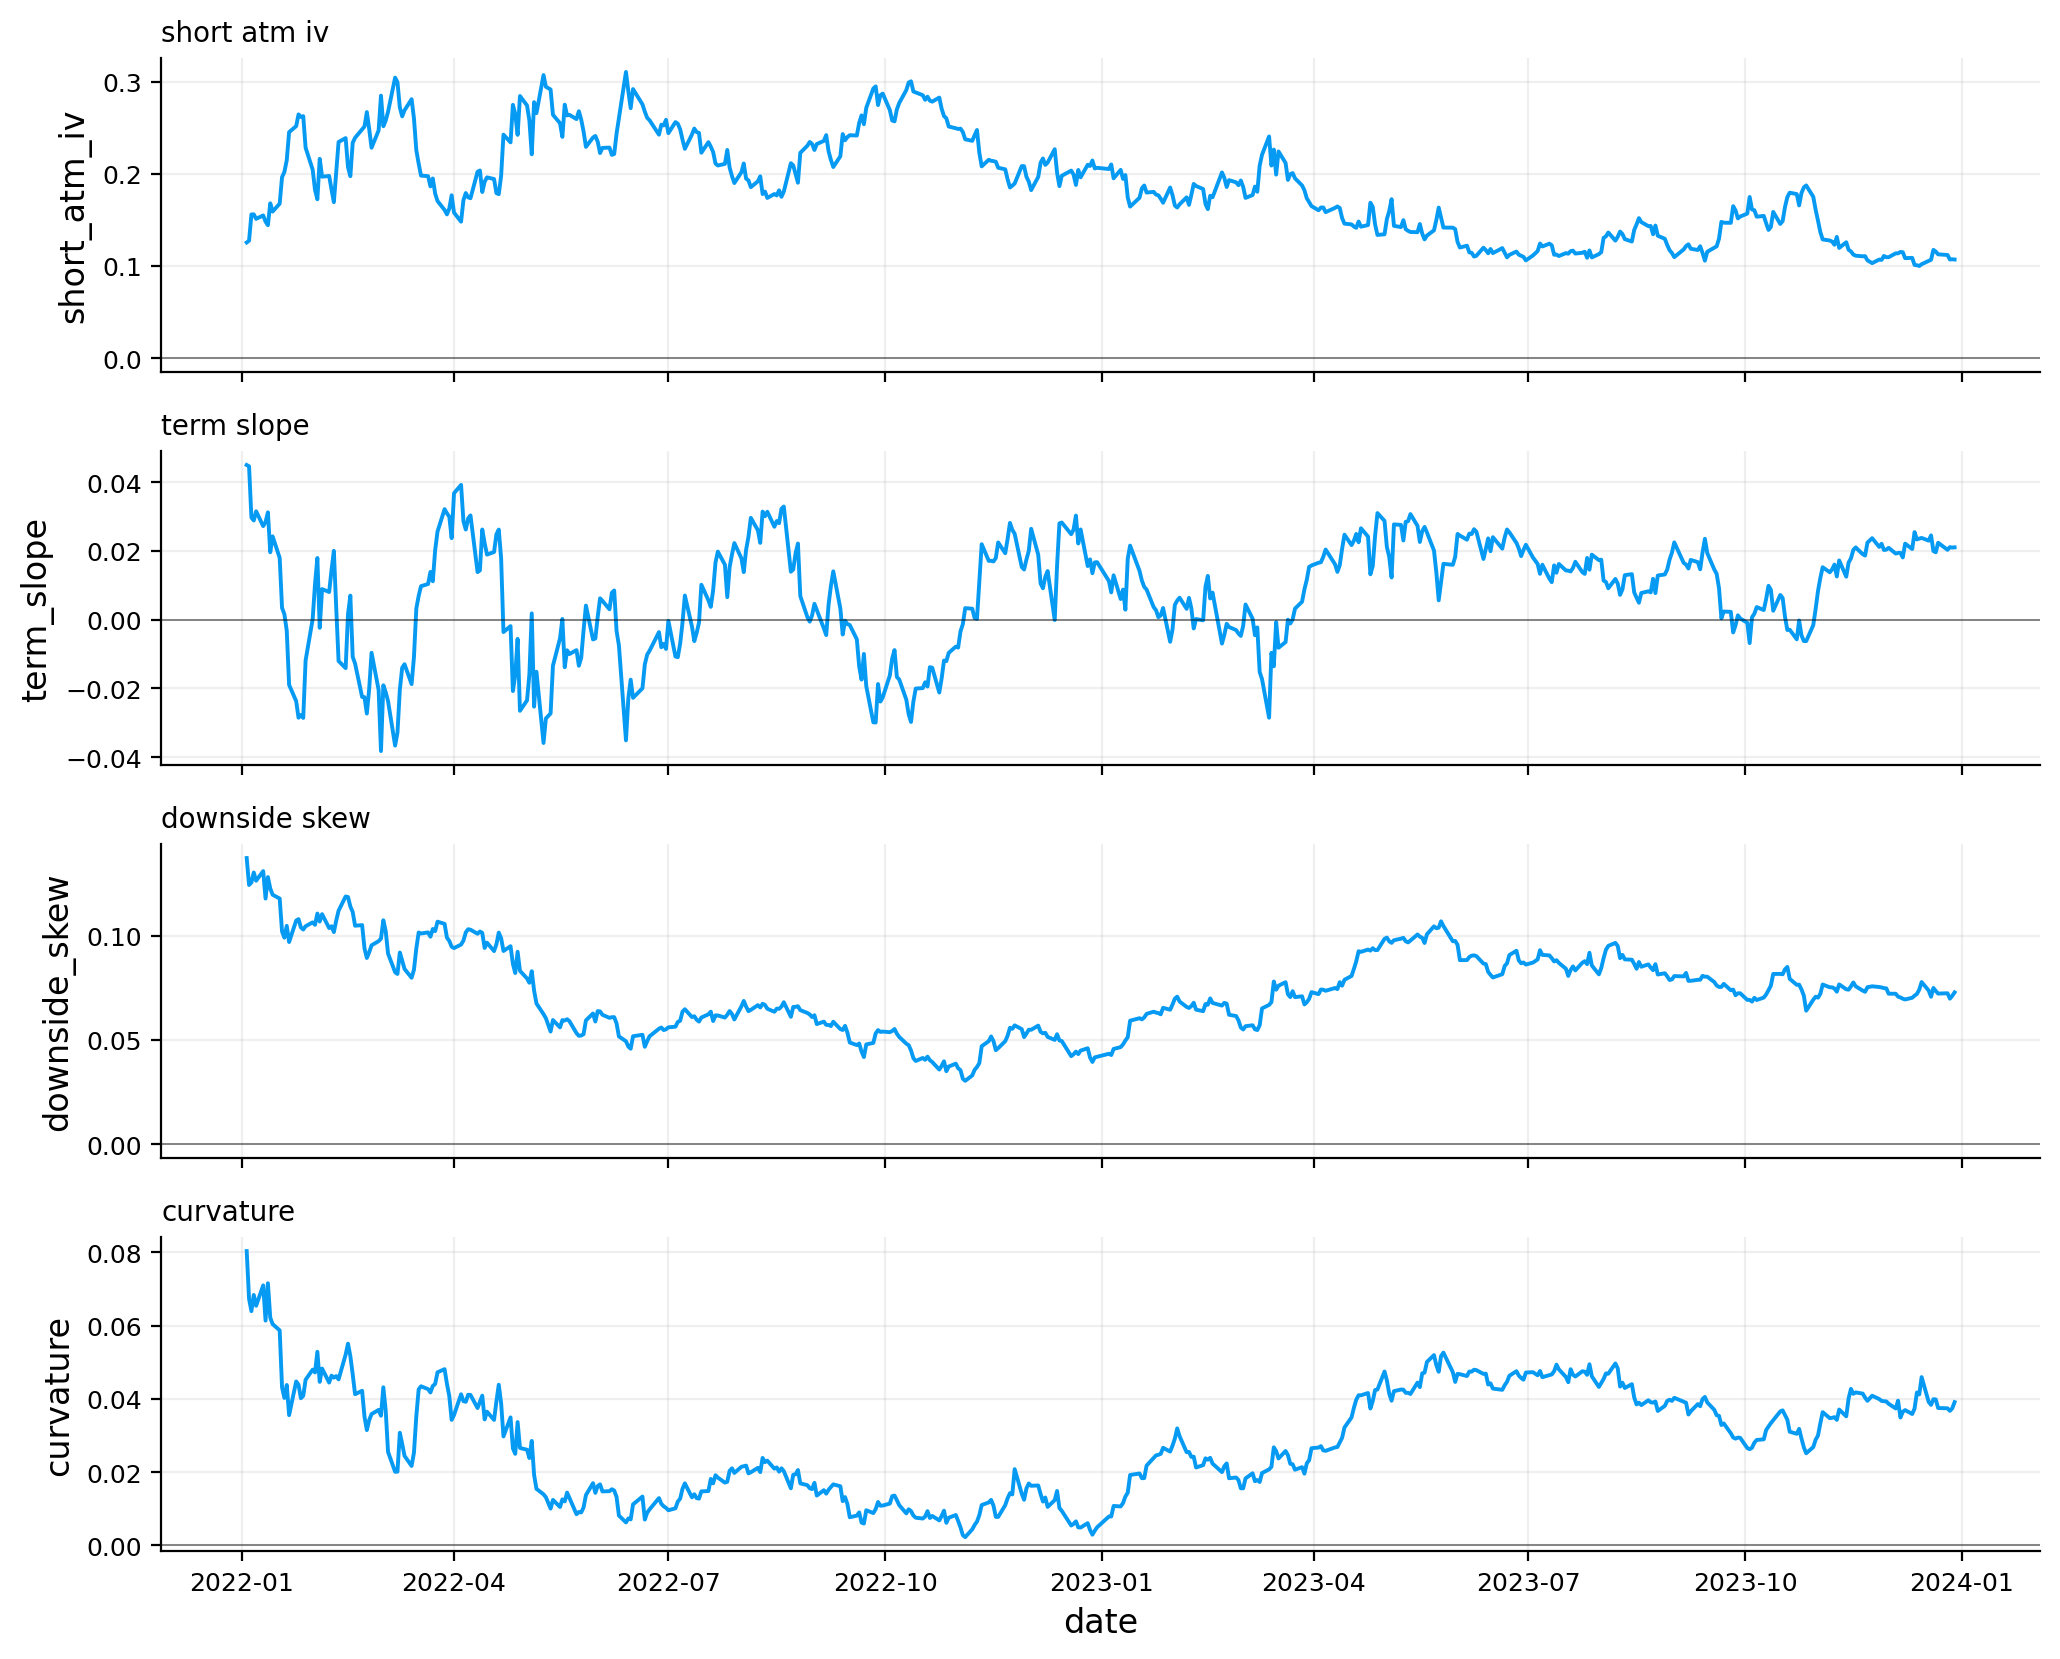

In [31]:
display(features.head(8))
feature_summary = features.drop(columns=["date"]).describe(percentiles=[0.05, 0.50, 0.95]).T
display(feature_summary[["mean", "std", "5%", "50%", "95%"]])

fig, axes = plt.subplots(4, 1, figsize=(10.4, 8.4), sharex=True)
series_to_plot = [
    ("short_atm_iv", "short atm iv"),
    ("term_slope", "term slope"),
    ("downside_skew", "downside skew"),
    ("curvature", "curvature"),
]
for ax, (col, title) in zip(axes, series_to_plot):
    ax.plot(features["date"], features[col], lw=1.4)
    ax.axhline(0.0, color="black", lw=0.7, alpha=0.45)
    ax.set_title(title, loc="left", fontsize=10)
    ax.set_ylabel(col)
axes[-1].set_xlabel("date")
plt.tight_layout()
plt.show()


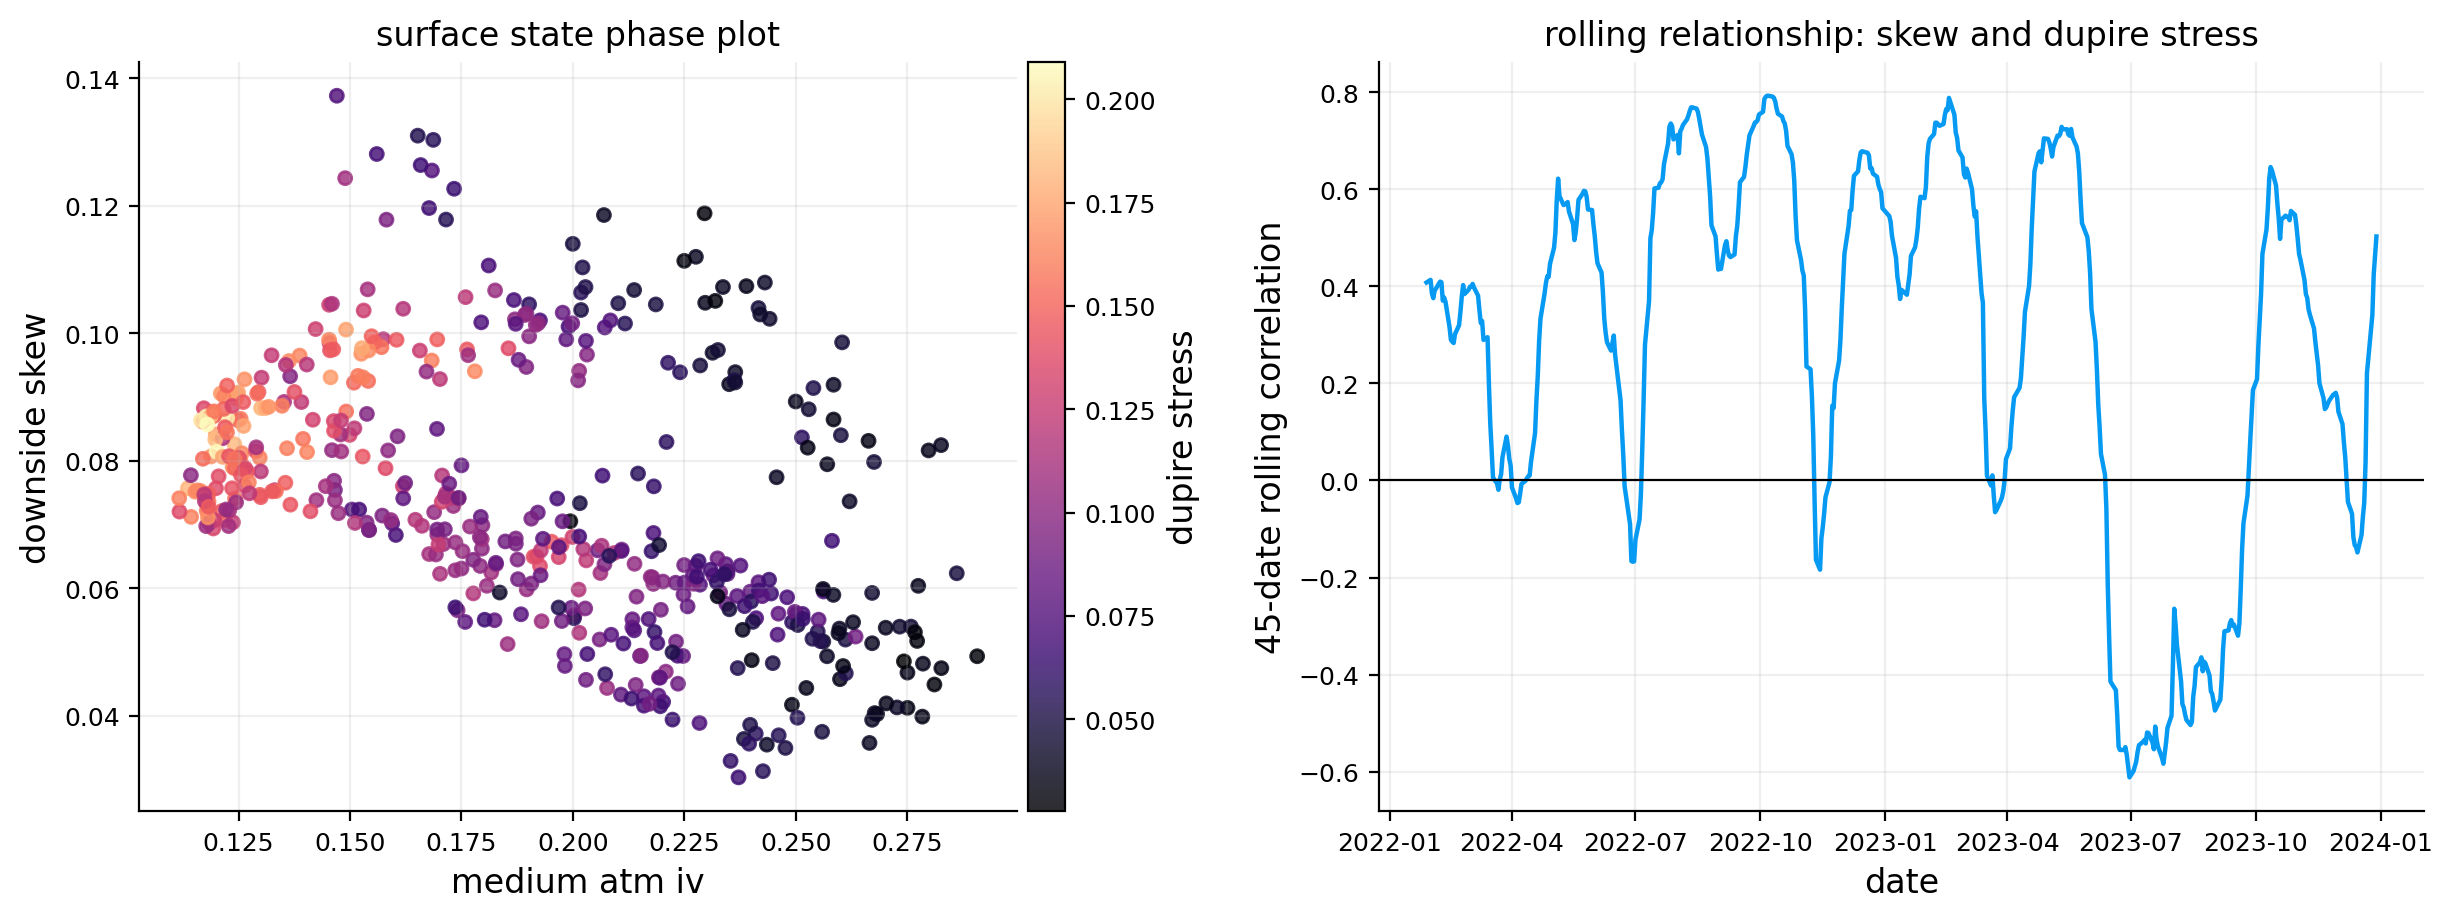

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.7))
sc = axes[0].scatter(features["medium_atm_iv"], features["downside_skew"], c=features["dupire_stress"], s=22, cmap="magma", alpha=0.82)
axes[0].set_title("surface state phase plot")
axes[0].set_xlabel("medium atm iv")
axes[0].set_ylabel("downside skew")
fig.colorbar(sc, ax=axes[0], pad=0.01, label="dupire stress")

roll = features.set_index("date")[["downside_skew", "dupire_stress"]].rolling(45, min_periods=20).corr().unstack().iloc[:, 1]
axes[1].plot(roll.index, roll.values, lw=1.6)
axes[1].axhline(0.0, color="black", lw=0.8)
axes[1].set_title("rolling relationship: skew and dupire stress")
axes[1].set_xlabel("date")
axes[1].set_ylabel("45-date rolling correlation")
plt.tight_layout()
plt.show()


In [33]:
surface_changes = np.diff(iv_common, axis=0)
change_dates = fit_dates[1:]
flat_changes = surface_changes.reshape(surface_changes.shape[0], -1)
flat_mask = common_node_mask.reshape(-1)
node_finite_share = np.isfinite(flat_changes).mean(axis=0)
node_keep = flat_mask & (node_finite_share >= 0.85)
if node_keep.sum() < 120:
    node_keep = flat_mask & (node_finite_share >= 0.75)
x_change_raw = flat_changes[:, node_keep]
col_mean = np.nanmean(x_change_raw, axis=0)
col_std = np.nanstd(x_change_raw, axis=0)
good_cols = np.isfinite(col_mean) & np.isfinite(col_std) & (col_std > 1e-8)
x_change_raw = x_change_raw[:, good_cols]
col_mean = col_mean[good_cols]
node_positions = np.where(node_keep)[0][good_cols]
missing = ~np.isfinite(x_change_raw)
x_change_raw[missing] = np.take(col_mean, np.where(missing)[1])
pca_scale = standard_scaler(with_mean=True, with_std=True)
x_change = pca_scale.fit_transform(x_change_raw)
pca = pca_estimator(n_components=5, random_state=seed)
pca_scores_arr = pca.fit_transform(x_change)
pca_scores = pd.DataFrame(pca_scores_arr[:, :5], columns=[f"pc{i}" for i in range(1, 6)])
pca_scores["date"] = change_dates
pca_var = pd.DataFrame({
    "component": [f"pc{i}" for i in range(1, 6)],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative": np.cumsum(pca.explained_variance_ratio_),
    "score_std": np.sqrt(pca.explained_variance_),
})
pc_shocks = []
for i in range(3):
    full = np.full(common_node_mask.size, np.nan)
    full[node_positions] = pca.components_[i] * np.sqrt(pca.explained_variance_[i]) * pca_scale.scale_
    pc_shocks.append(full.reshape(len(tau_safe_grid), len(k_safe_grid)))
features = features.drop(columns=[f"pc{i}" for i in range(1, 6) if f"pc{i}" in features.columns], errors="ignore")
features = features.merge(pca_scores, on="date", how="left")
pca_grid_summary = pd.DataFrame([{
    "pca_nodes": int(len(node_positions)),
    "candidate_common_nodes": int(common_node_mask.sum()),
    "min_node_finite_share": float(np.nanmin(node_finite_share[node_positions])),
    "median_node_finite_share": float(np.nanmedian(node_finite_share[node_positions])),
}])
display(pca_grid_summary)
display(pca_var)
top_score_rows = []
for pc in ["pc1", "pc2", "pc3"]:
    s = pca_scores.dropna(subset=[pc]).sort_values(pc)
    top_score_rows.append({"component": pc, "side": "negative", "date": s.iloc[0]["date"].date(), "score": float(s.iloc[0][pc])})
    top_score_rows.append({"component": pc, "side": "positive", "date": s.iloc[-1]["date"].date(), "score": float(s.iloc[-1][pc])})
display(pd.DataFrame(top_score_rows))


,pca_nodes,candidate_common_nodes,min_node_finite_share,median_node_finite_share
0,600,675,0.855159,1.000000


,component,explained_variance_ratio,cumulative,score_std
0,pc1,0.925545,0.925545,23.588788
1,pc2,0.047508,0.973053,5.344301
2,pc3,0.009431,0.982484,2.381147
3,pc4,0.005426,0.987910,1.806151
4,pc5,0.004435,0.992345,1.632905


,component,side,date,score
0,pc1,negative,2022-03-16,-66.284044
1,pc1,positive,2022-05-05,89.983376
2,pc2,negative,2022-05-05,-33.522726
3,pc2,positive,2022-01-28,20.285555
4,pc3,negative,2022-12-14,-7.251726
5,pc3,positive,2022-12-12,8.712696


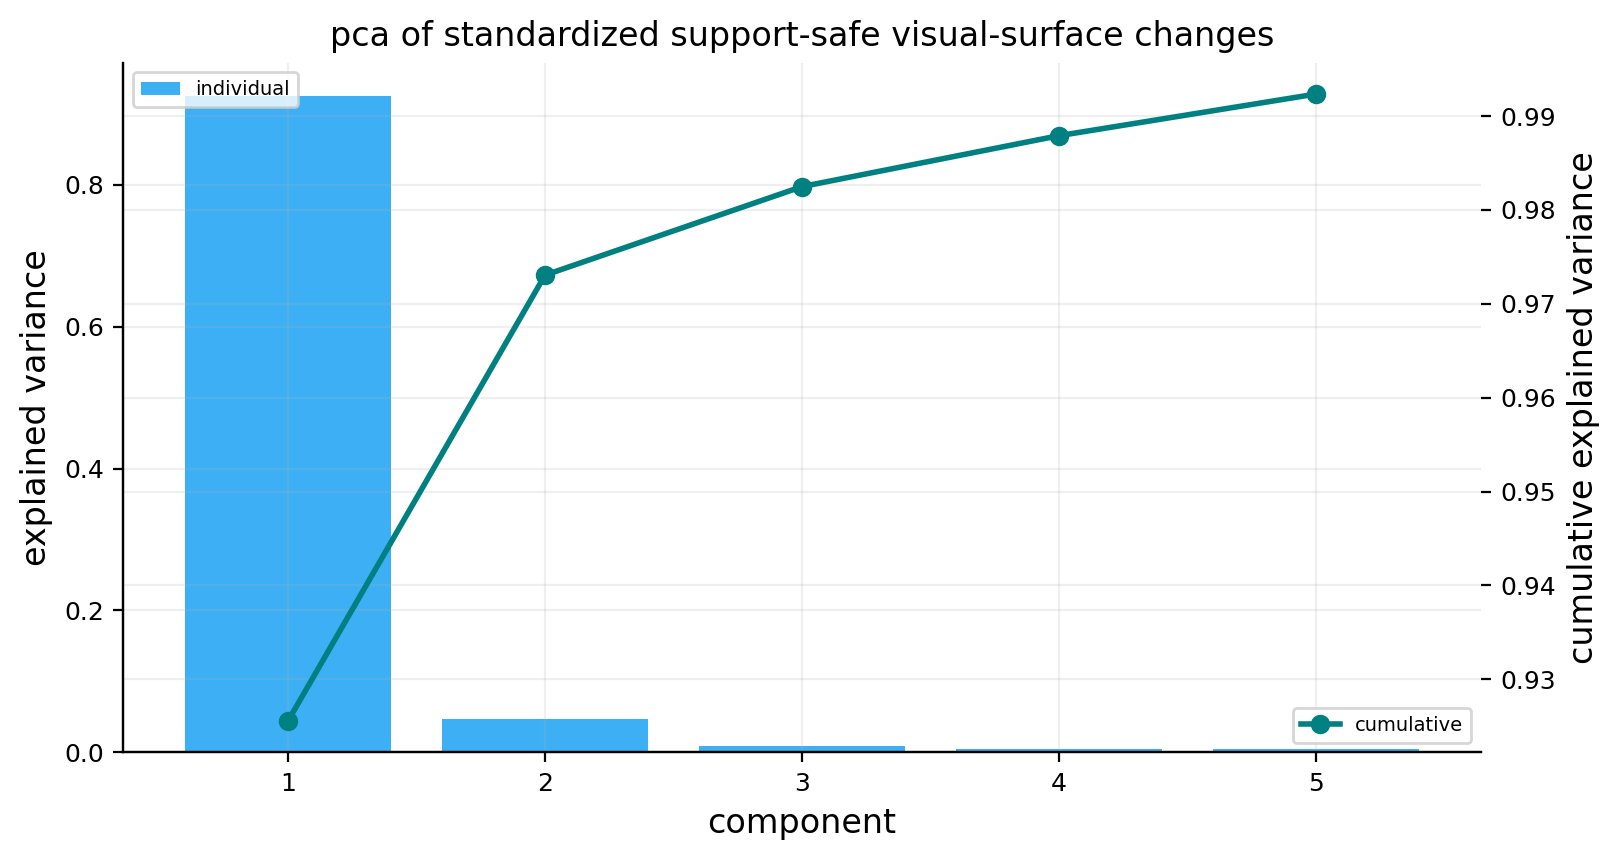

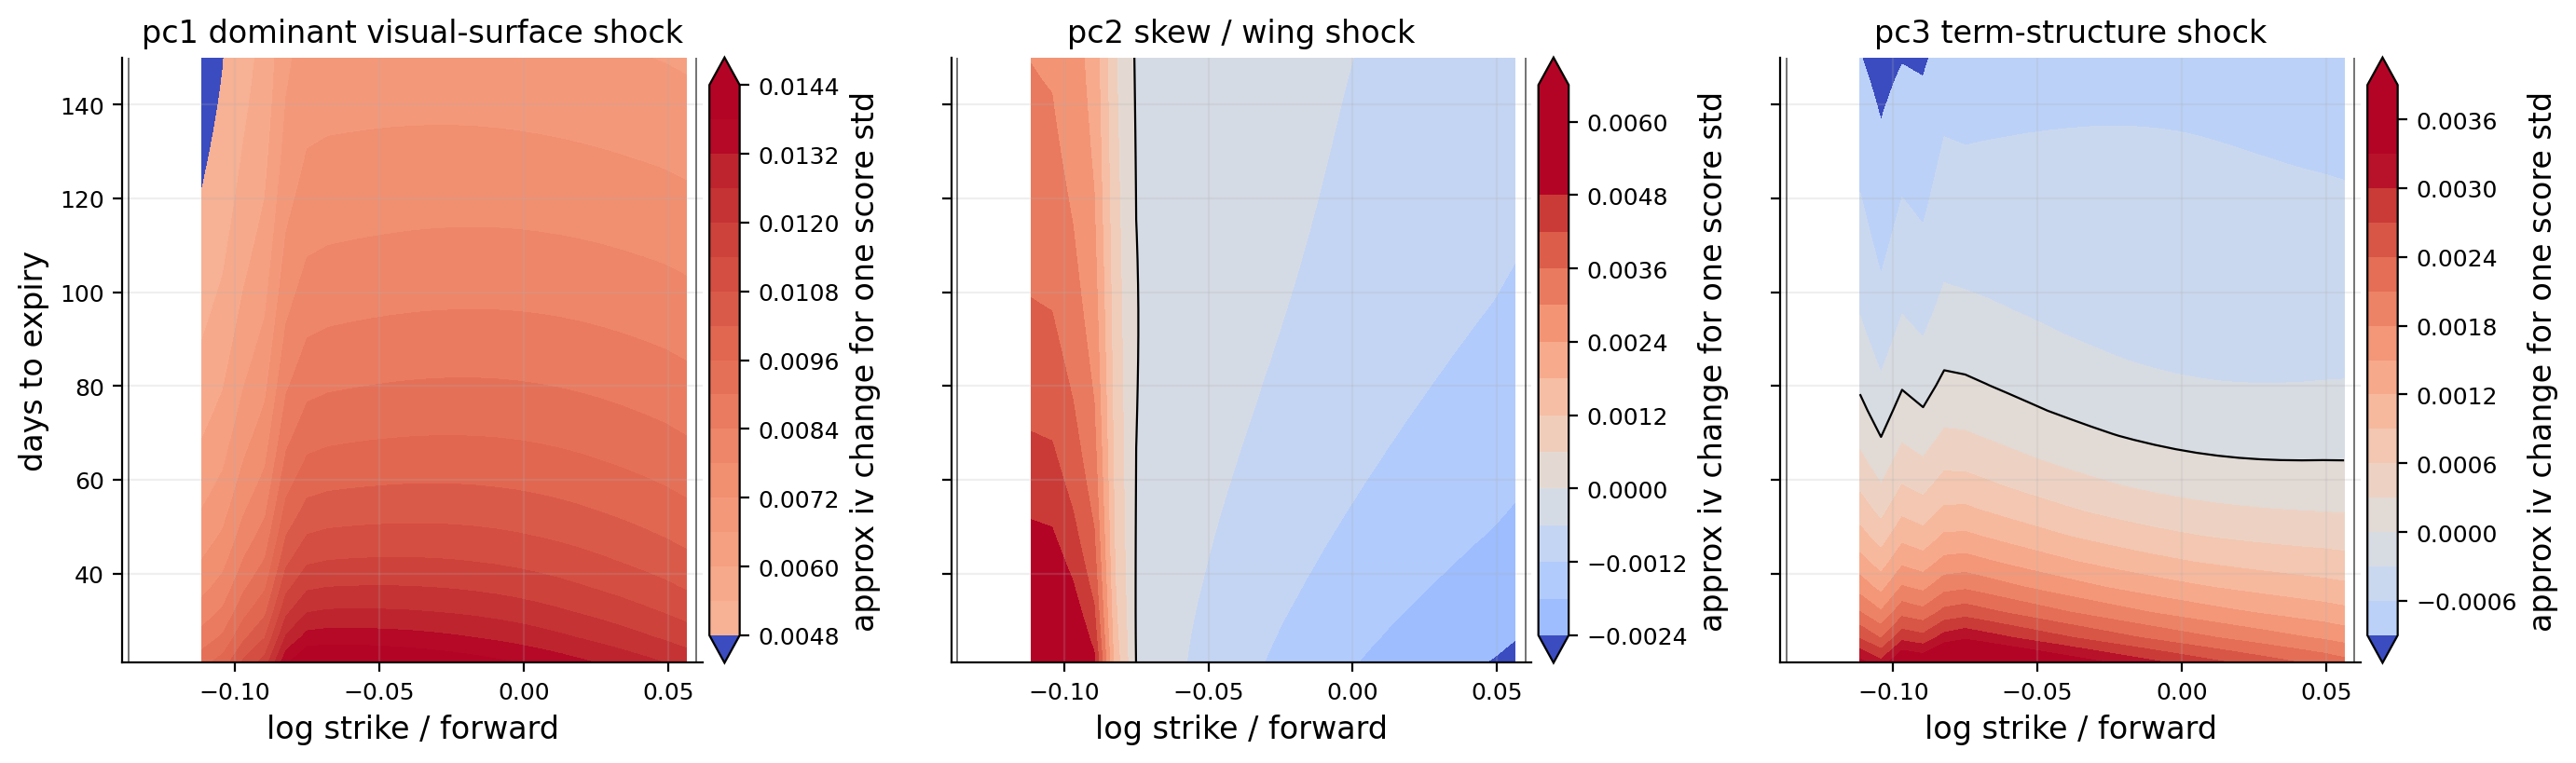

In [34]:
fig, ax1 = plt.subplots(figsize=(8.2, 4.4))
xpos = np.arange(1, 6)
ax1.bar(xpos, pca_var["explained_variance_ratio"], color=lab_colors[0], alpha=0.78, label="individual")
ax1.set_xlabel("component")
ax1.set_ylabel("explained variance")
ax1.set_xticks(xpos)
ax2 = ax1.twinx()
ax2.plot(xpos, pca_var["cumulative"], color=lab_colors[3], marker="o", lw=2.0, label="cumulative")
ax2.set_ylabel("cumulative explained variance")
ax1.set_title("pca of standardized support-safe visual-surface changes")
ax1.legend(loc="upper left")
ax2.legend(loc="lower right")
plt.tight_layout()
plt.show()

common_k_mask = common_node_mask.any(axis=0)
fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.2), sharey=True)
pc_titles = ["pc1 dominant visual-surface shock", "pc2 skew / wing shock", "pc3 term-structure shock"]
for i, ax in enumerate(axes):
    arr = pc_shocks[i]
    lim = robust_abs_limit(arr, common_node_mask, q=0.98)
    cf = ax.contourf(k_safe_grid, tau_safe_grid * ann_days, arr, levels=17, cmap="coolwarm", norm=two_slope_norm(vcenter=0, vmin=-lim, vmax=lim), extend="both")
    ax.contour(k_safe_grid, tau_safe_grid * ann_days, arr, levels=[0.0], colors="black", linewidths=0.8)
    ax.contour(k_safe_grid, tau_safe_grid * ann_days, common_node_mask.astype(float), levels=[0.5], colors="black", linewidths=0.7, alpha=0.55)
    ax.set_title(pc_titles[i])
    set_supported_xlim(ax, k_safe_grid, common_k_mask)
    ax.set_xlabel("log strike / forward")
    fig.colorbar(cf, ax=ax, pad=0.01, label="approx iv change for one score std")
axes[0].set_ylabel("days to expiry")
plt.tight_layout()
plt.show()


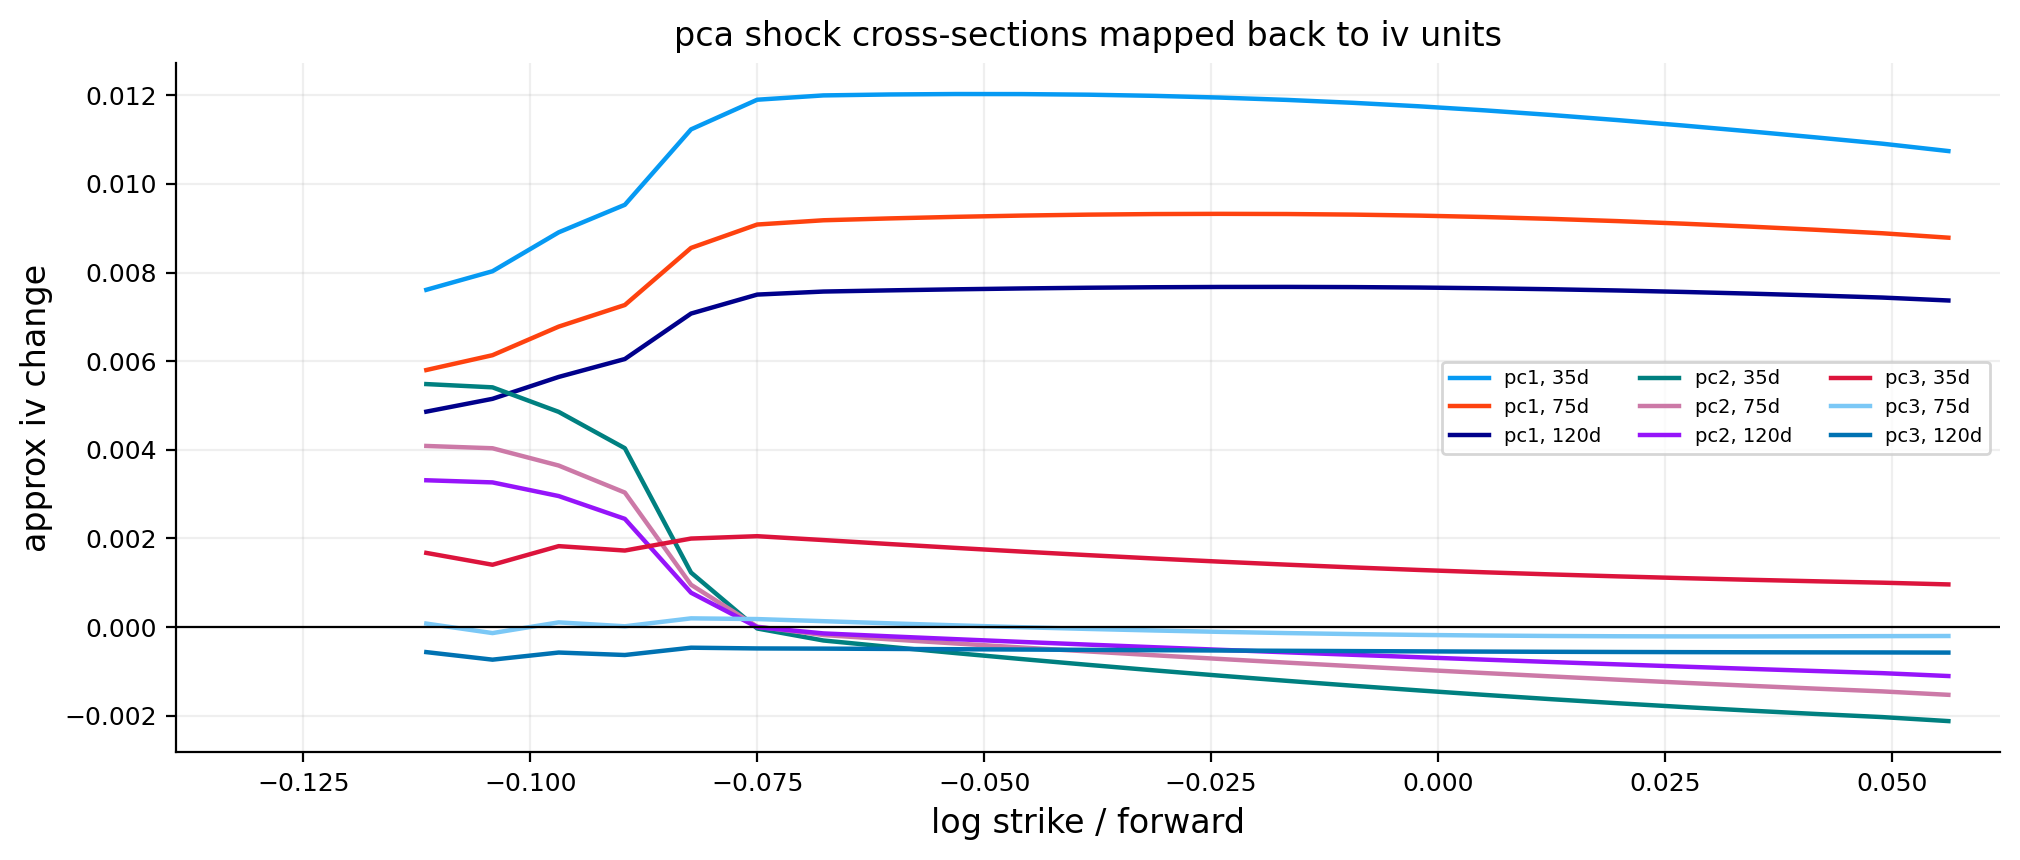

In [35]:
fig, ax = plt.subplots(figsize=(10.2, 4.4))
for i, arr in enumerate(pc_shocks[:3]):
    for day in [35, 75, 120]:
        idx = int(np.argmin(np.abs(tau_safe_grid * ann_days - day)))
        ax.plot(k_safe_grid, arr[idx], lw=1.6, label=f"pc{i + 1}, {day}d")
ax.axhline(0.0, color="black", lw=0.8)
ax.set_title("pca shock cross-sections mapped back to iv units")
set_supported_xlim(ax, k_safe_grid, common_node_mask)
ax.set_xlabel("log strike / forward")
ax.set_ylabel("approx iv change")
ax.legend(ncol=3, fontsize=7)
plt.tight_layout()
plt.show()


In [36]:
episode_tables = {
    "top_pc1_positive": features.nlargest(5, "pc1")[["date", "pc1", "short_atm_iv", "downside_skew", "dupire_stress"]],
    "top_pc1_negative": features.nsmallest(5, "pc1")[["date", "pc1", "short_atm_iv", "downside_skew", "dupire_stress"]],
    "highest_dupire_stress": features.nlargest(5, "dupire_stress")[["date", "dupire_stress", "dupire_total_flagged_share", "dupire_extreme_ratio_share", "dupire_median_abs_lv_to_iv_minus_1"]],
    "highest_downside_skew": features.nlargest(5, "downside_skew")[["date", "downside_skew", "medium_atm_iv", "dupire_stress"]],
    "highest_curvature": features.nlargest(5, "curvature")[["date", "curvature", "medium_atm_iv", "dupire_stress"]],
}
for name, table in episode_tables.items():
    print(name)
    display(table)

episode_dates = [
    features.loc[features["pc1"].abs().idxmax(), "date"],
    features.loc[features["downside_skew"].idxmax(), "date"],
    features.loc[features["curvature"].idxmax(), "date"],
    features.loc[features["dupire_stress"].idxmax(), "date"],
]
episode_dates = list(dict.fromkeys(pd.to_datetime(episode_dates).normalize()))
episode_labels = [pd.Timestamp(x).date().isoformat() for x in episode_dates]
display(pd.DataFrame({"episode_date": episode_labels}))


top_pc1_positive


,date,pc1,short_atm_iv,downside_skew,dupire_stress
88,2022-05-05,89.983376,0.277606,0.073653,0.041588
79,2022-04-22,85.184034,0.242347,0.092662,0.052185
114,2022-06-13,83.542051,0.310355,0.049366,0.031340
90,2022-05-09,74.563092,0.307018,0.062379,0.047878
96,2022-05-18,74.274569,0.274879,0.059293,0.043432


top_pc1_negative


,date,pc1,short_atm_iv,downside_skew,dupire_stress
52,2022-03-16,-66.284044,0.225466,0.093894,0.056589
87,2022-05-04,-57.766065,0.221032,0.082967,0.057598
305,2023-03-16,-53.349984,0.199006,0.074098,0.069502
340,2023-05-05,-51.992774,0.143369,0.097835,0.156550
19,2022-01-28,-50.188706,0.228239,0.104538,0.048455


highest_dupire_stress


...

highest_downside_skew


,date,downside_skew,medium_atm_iv,dupire_stress
0,2022-01-03,0.137266,0.147044,0.074317
5,2022-01-10,0.131004,0.165203,0.052617
3,2022-01-06,0.130345,0.168683,0.055625
7,2022-01-12,0.128128,0.156006,0.067986
4,2022-01-07,0.126397,0.165860,0.066002


highest_curvature


,date,curvature,medium_atm_iv,dupire_stress
0,2022-01-03,0.080381,0.147044,0.074317
7,2022-01-12,0.071601,0.156006,0.067986
5,2022-01-10,0.071019,0.165203,0.052617
3,2022-01-06,0.068401,0.168683,0.055625
1,2022-01-04,0.067326,0.148917,0.108713


,episode_date
0,2022-05-05
1,2022-01-03
2,2023-07-28


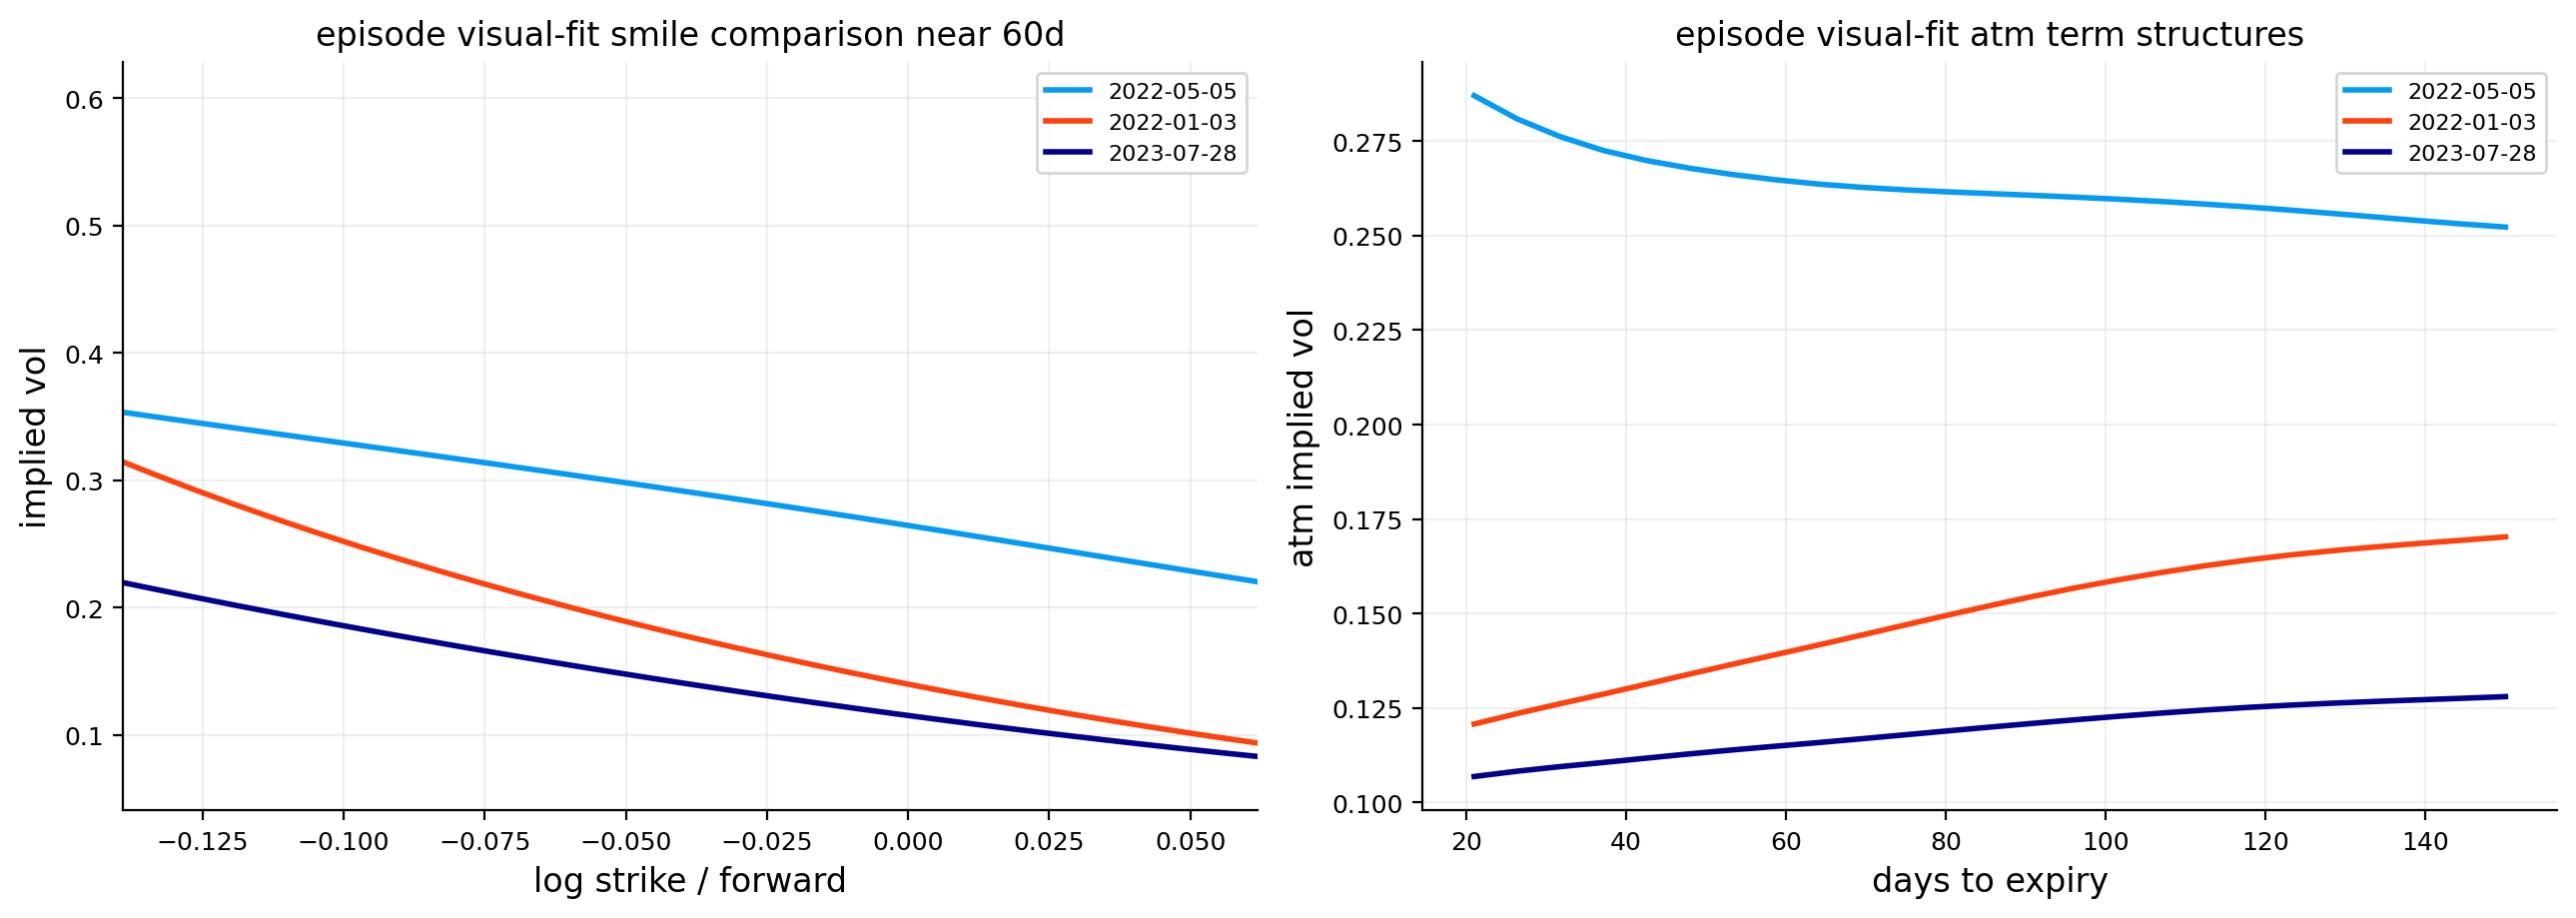

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.7))
for n, date in enumerate(episode_dates):
    fit = fit_store_visual[pd.Timestamp(date)]
    smile = iv_points(fit, k_safe_grid, np.full_like(k_safe_grid, 60.0 / ann_days))
    term = iv_points(fit, np.zeros_like(tau_safe_grid), tau_safe_grid)
    axes[0].plot(k_safe_grid, smile, lw=2.0, color=lab_colors[n % len(lab_colors)], label=pd.Timestamp(date).date())
    axes[1].plot(tau_safe_grid * ann_days, term, lw=2.0, color=lab_colors[n % len(lab_colors)], label=pd.Timestamp(date).date())
axes[0].set_title("episode visual-fit smile comparison near 60d")
set_supported_xlim(axes[0], k_safe_grid, common_node_mask)
axes[0].set_xlabel("log strike / forward")
axes[0].set_ylabel("implied vol")
axes[1].set_title("episode visual-fit atm term structures")
axes[1].set_xlabel("days to expiry")
axes[1].set_ylabel("atm implied vol")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [38]:
knots_k_j = jnp.asarray(fit_dupire["knots_k"])
knots_tau_j = jnp.asarray(fit_dupire["knots_tau"])
k_center_j = jnp.asarray(fit_dupire["k_center"])
k_scale_j = jnp.asarray(fit_dupire["k_scale"])
tau_center_j = jnp.asarray(fit_dupire["tau_center"])
tau_scale_j = jnp.asarray(fit_dupire["tau_scale"])
k_risk_j = jnp.asarray(k_risk_grid)
tau_risk_j = jnp.asarray(tau_risk_grid)


def bspline_basis_jax(x, knots):
    x = jnp.clip(x, knots[0] + 1e-10, knots[-1] - 1e-10)
    b = jnp.where((x >= knots[:-1]) & (x < knots[1:]), 1.0, 0.0)
    for degree in range(1, 4):
        n = knots.shape[0] - degree - 1
        left_den = knots[degree:n + degree] - knots[:n]
        right_den = knots[degree + 1:n + degree + 1] - knots[1:n + 1]
        left_den_safe = jnp.where(left_den > 0, left_den, 1.0)
        right_den_safe = jnp.where(right_den > 0, right_den, 1.0)
        left = jnp.where(left_den > 0, (x - knots[:n]) / left_den_safe, 0.0) * b[:n]
        right = jnp.where(right_den > 0, (knots[degree + 1:n + degree + 1] - x) / right_den_safe, 0.0) * b[1:n + 1]
        b = left + right
    return b


def iv_jax_from_coef(coef, k_value, tau_value):
    sk = (k_value - k_center_j) / k_scale_j
    st = (tau_value - tau_center_j) / tau_scale_j
    bk = bspline_basis_jax(sk, knots_k_j)
    bt = bspline_basis_jax(st, knots_tau_j)
    log_w = bk @ coef @ bt
    return jnp.sqrt(jnp.exp(jnp.clip(log_w, -40.0, 5.0)) / jnp.maximum(tau_value, 1e-8))


def call_price_spot(spot_value, strike_value, tau_value, rate_value, carry_value, sigma_value):
    tau_value = jnp.maximum(tau_value, 1e-8)
    sigma_value = jnp.maximum(sigma_value, 1e-6)
    forward_value = spot_value * jnp.exp(carry_value * tau_value)
    disc = jnp.exp(-rate_value * tau_value)
    sqrt_tau = jnp.sqrt(tau_value)
    d1 = (jnp.log(jnp.maximum(forward_value, 1e-300) / jnp.maximum(strike_value, 1e-300)) + 0.5 * sigma_value ** 2 * tau_value) / (sigma_value * sqrt_tau)
    d2 = d1 - sigma_value * sqrt_tau
    cdf1 = 0.5 * (1.0 + jax.lax.erf(d1 / jnp.sqrt(2.0)))
    cdf2 = 0.5 * (1.0 + jax.lax.erf(d2 / jnp.sqrt(2.0)))
    return disc * (forward_value * cdf1 - strike_value * cdf2)


def surface_price_scalar(spot_value, strike_value, tau_value, rate_value, carry_value, coef):
    forward_value = spot_value * jnp.exp(carry_value * tau_value)
    k_value = jnp.log(strike_value / jnp.maximum(forward_value, 1e-300))
    sigma_value = iv_jax_from_coef(coef, k_value, tau_value)
    return call_price_spot(spot_value, strike_value, tau_value, rate_value, carry_value, sigma_value)


def flat_price_scalar(spot_value, strike_value, tau_value, rate_value, carry_value, sigma_value):
    return call_price_spot(spot_value, strike_value, tau_value, rate_value, carry_value, sigma_value)


surface_delta_scalar = jax.grad(surface_price_scalar, argnums=0)
surface_gamma_scalar = jax.grad(surface_delta_scalar, argnums=0)
flat_delta_scalar = jax.grad(flat_price_scalar, argnums=0)
flat_gamma_scalar = jax.grad(flat_delta_scalar, argnums=0)


@jax.jit
def greek_grid_jax(coef, spot_value, rate_tau, carry_tau):
    tau_mesh, k_mesh = jnp.meshgrid(tau_risk_j, k_risk_j, indexing="ij")
    rate_mesh = rate_tau[:, None] + jnp.zeros_like(tau_mesh)
    carry_mesh = carry_tau[:, None] + jnp.zeros_like(tau_mesh)
    strike_mesh = spot_value * jnp.exp(k_mesh)
    forward_mesh = spot_value * jnp.exp(carry_mesh * tau_mesh)
    surface_k = jnp.log(strike_mesh / jnp.maximum(forward_mesh, 1e-300))
    sigma0 = jax.vmap(lambda x, t: iv_jax_from_coef(coef, x, t))(surface_k.reshape(-1), tau_mesh.reshape(-1)).reshape(tau_mesh.shape)
    vm = jax.vmap(
        lambda strike, tau, rate, carry, sigma: (
            surface_price_scalar(spot_value, strike, tau, rate, carry, coef),
            surface_delta_scalar(spot_value, strike, tau, rate, carry, coef),
            surface_gamma_scalar(spot_value, strike, tau, rate, carry, coef),
            flat_delta_scalar(spot_value, strike, tau, rate, carry, sigma),
            flat_gamma_scalar(spot_value, strike, tau, rate, carry, sigma),
        )
    )
    vals = vm(strike_mesh.reshape(-1), tau_mesh.reshape(-1), rate_mesh.reshape(-1), carry_mesh.reshape(-1), sigma0.reshape(-1))
    vals = [x.reshape(tau_mesh.shape) for x in vals]
    return vals


def greek_support_mask(q, spot_value):
    rate_tau = rate_on_tau(q, tau_risk_grid)
    carry_tau = carry_on_tau(q, tau_risk_grid, spot_value)
    tau_mesh, k_mesh = np.meshgrid(tau_risk_grid, k_risk_grid, indexing="ij")
    strike_mesh = spot_value * np.exp(k_mesh)
    forward_mesh = spot_value * np.exp(carry_tau[:, None] * tau_mesh)
    model_k = np.log(strike_mesh / forward_mesh)
    return support_mask_from_limits(quote_support(q), model_k, tau_mesh)


def greek_summary(arrs, support_mask=None):
    price, s_delta, s_gamma, f_delta, f_gamma = [np.asarray(x, dtype=float) for x in arrs]
    out = {
        "price": price,
        "delta_diff": s_delta - f_delta,
        "gamma_diff": s_gamma - f_gamma,
        "surface_delta": s_delta,
        "surface_gamma": s_gamma,
        "flat_delta": f_delta,
        "flat_gamma": f_gamma,
    }
    if support_mask is not None:
        for key in list(out):
            out[key] = masked_grid(out[key], support_mask)
    return out


def risk_row(date, diffs, spot_value, spot_shock_frac=0.01):
    out = {"date": pd.Timestamp(date).normalize()}
    spot_shock = float(spot_value) * float(spot_shock_frac)
    delta_pnl = diffs["delta_diff"] * spot_shock
    gamma_pnl = 0.5 * diffs["gamma_diff"] * spot_shock ** 2
    price = diffs["price"]
    for name in ["delta", "gamma"]:
        arr = diffs[f"{name}_diff"]
        out[f"{name}_rms_diff"] = float(np.sqrt(np.nanmean(arr ** 2)))
        out[f"max_abs_{name}_diff"] = float(np.nanmax(np.abs(arr)))
    out["delta_pnl_rms"] = float(np.sqrt(np.nanmean(delta_pnl ** 2)))
    out["gamma_pnl_rms"] = float(np.sqrt(np.nanmean(gamma_pnl ** 2)))
    out["total_greek_pnl_rms"] = float(np.sqrt(np.nanmean(delta_pnl ** 2 + gamma_pnl ** 2)))
    price_ref = np.nanmedian(price[np.isfinite(price) & (price > 0)])
    out["relative_greek_pnl_rms"] = float(out["total_greek_pnl_rms"] / price_ref) if np.isfinite(price_ref) and price_ref > 0 else np.nan
    return out


In [39]:
spot_main = float(q_main["spot"].median())
rate_main = jnp.asarray(rate_on_tau(q_main, tau_risk_grid))
carry_main = jnp.asarray(carry_on_tau(q_main, tau_risk_grid, spot_main))
coef_main = jnp.asarray(fit_dupire["coef"])
support_risk_main = greek_support_mask(q_main, spot_main)
main_greek_arrays = greek_grid_jax(coef_main, spot_main, rate_main, carry_main)
main_greeks = greek_summary(main_greek_arrays, support_risk_main)
main_greek_table = pd.DataFrame([risk_row(main_date, main_greeks, spot_main)])
main_greek_table.attrs["engine_used"] = "jax"
main_greek_table.attrs["fallback_used"] = False
greek_engine_check = pd.DataFrame([{"engine_used": main_greek_table.attrs["engine_used"], "fallback_used": main_greek_table.attrs["fallback_used"]}])
display(main_greek_table)
display(greek_engine_check)


,date,delta_rms_diff,max_abs_delta_diff,gamma_rms_diff,max_abs_gamma_diff,delta_pnl_rms,gamma_pnl_rms,total_greek_pnl_rms,relative_greek_pnl_rms
0,2023-12-29,0.061183,0.106110,0.000242,0.000552,2.919759,0.276015,2.932776,0.007765


,engine_used,fallback_used
0,jax,False


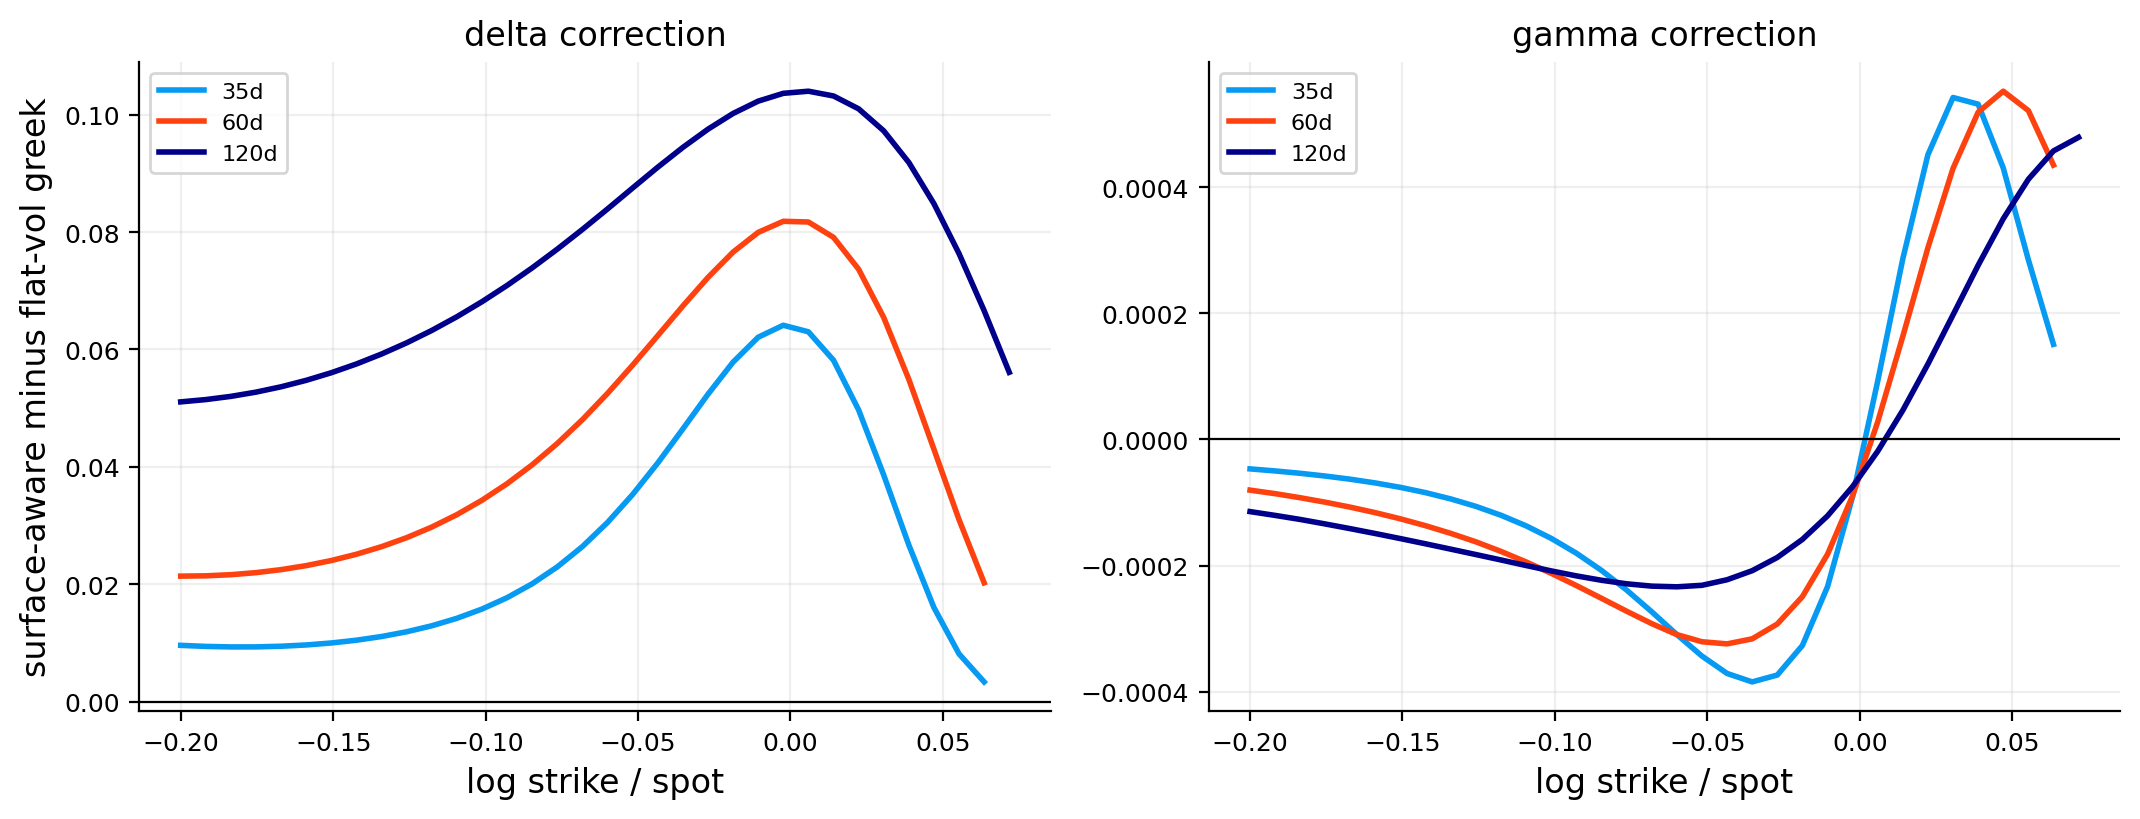

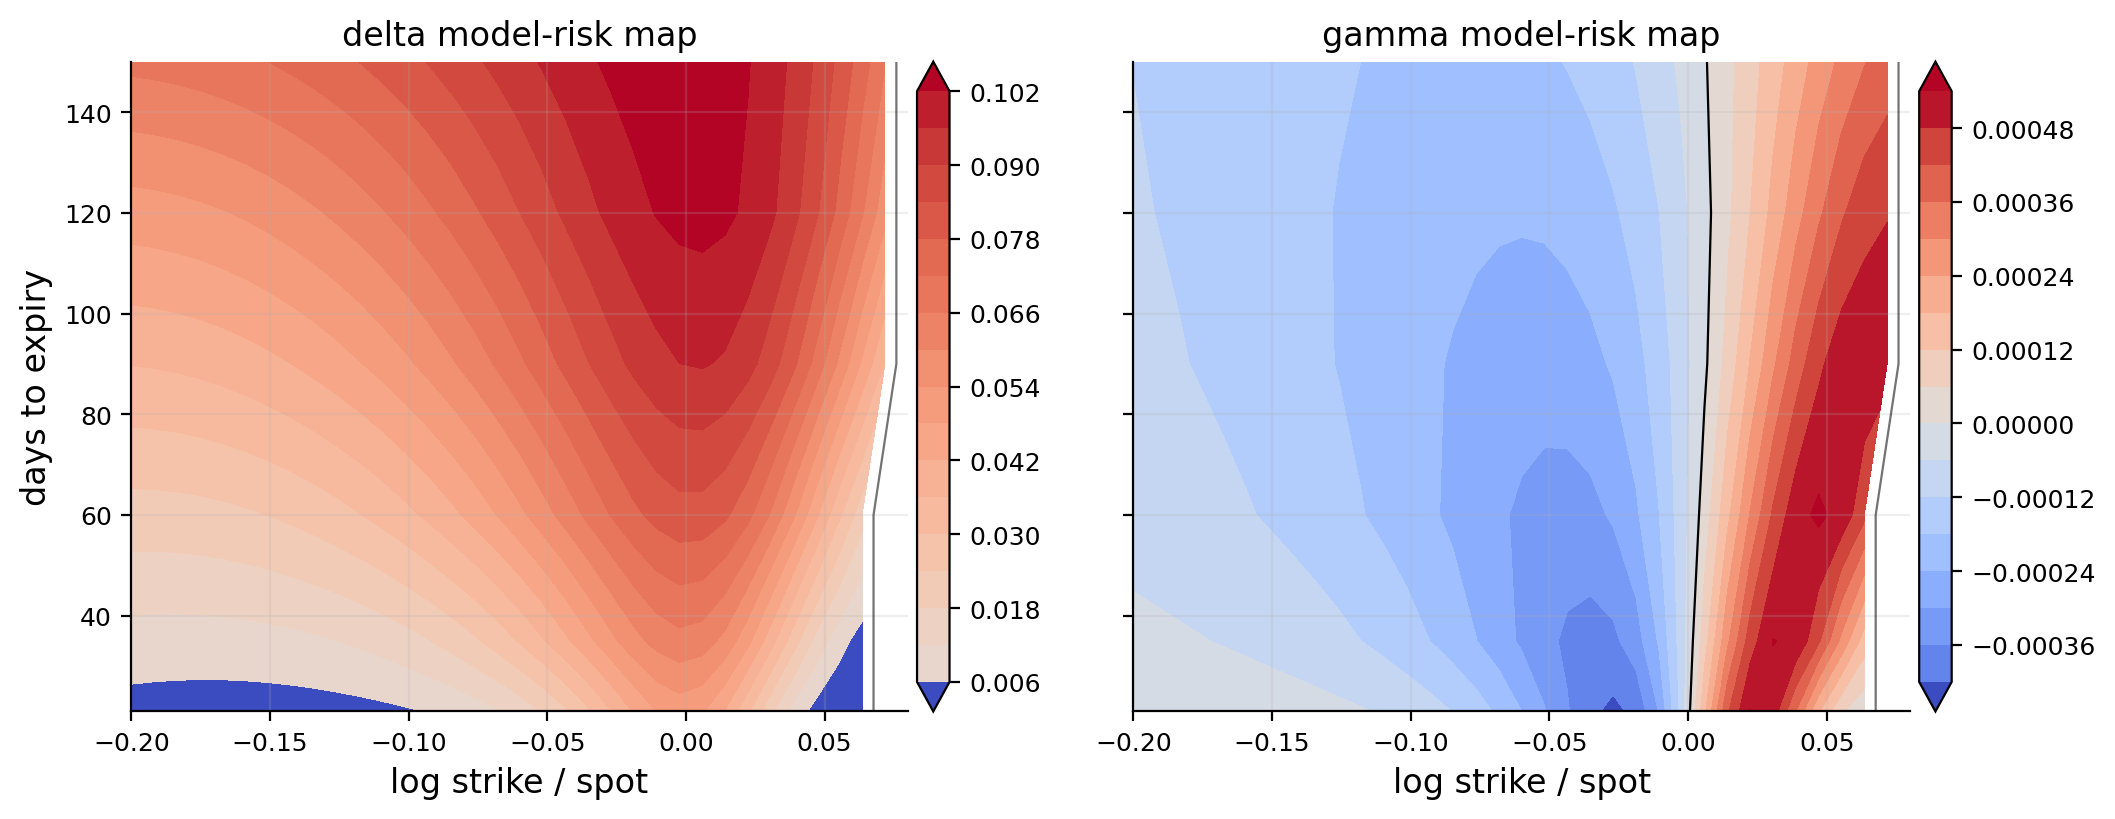

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2), sharex=True)
for ax, name in zip(axes, ["delta", "gamma"]):
    arr = main_greeks[f"{name}_diff"]
    for day in [35, 60, 120]:
        idx = int(np.argmin(np.abs(tau_risk_grid * ann_days - day)))
        ax.plot(k_risk_grid, arr[idx], lw=2.0, label=f"{tau_risk_grid[idx] * ann_days:.0f}d")
    ax.axhline(0.0, color="black", lw=0.8)
    ax.set_title(f"{name} correction")
    ax.set_xlabel("log strike / spot")
    ax.legend(fontsize=8)
axes[0].set_ylabel("surface-aware minus flat-vol greek")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2), sharey=True)
for ax, name in zip(axes, ["delta", "gamma"]):
    arr = main_greeks[f"{name}_diff"]
    lim = robust_abs_limit(arr, support_risk_main, q=0.98)
    cf = ax.contourf(k_risk_grid, tau_risk_grid * ann_days, arr, levels=17, cmap="coolwarm", norm=two_slope_norm(vcenter=0, vmin=-lim, vmax=lim), extend="both")
    ax.contour(k_risk_grid, tau_risk_grid * ann_days, arr, levels=[0.0], colors="black", linewidths=0.8)
    ax.contour(k_risk_grid, tau_risk_grid * ann_days, support_risk_main.astype(float), levels=[0.5], colors="black", linewidths=0.8, alpha=0.55)
    ax.set_title(f"{name} model-risk map")
    ax.set_xlabel("log strike / spot")
    fig.colorbar(cf, ax=ax, pad=0.01)
axes[0].set_ylabel("days to expiry")
plt.tight_layout()
plt.show()


In [41]:
greek_tic = time.perf_counter()
greek_rows = []
for n, date in enumerate(fit_dates):
    date = pd.Timestamp(date).normalize()
    fit = fit_store_dupire[date]
    q_date = surface[surface["date"].eq(date)].copy()
    spot_value = float(q_date["spot"].median())
    rate_tau = jnp.asarray(rate_on_tau(q_date, tau_risk_grid))
    carry_tau = jnp.asarray(carry_on_tau(q_date, tau_risk_grid, spot_value))
    coef = jnp.asarray(fit["coef"])
    try:
        support_risk = greek_support_mask(q_date, spot_value)
        arrs = greek_grid_jax(coef, spot_value, rate_tau, carry_tau)
        arrs[0].block_until_ready()
        diffs = greek_summary(arrs, support_risk)
        row = risk_row(date, diffs, spot_value)
        row["engine_used"] = "jax"
        row["fallback_used"] = False
        greek_rows.append(row)
    except Exception as exc:
        greek_rows.append({"date": date, "error": str(exc)[:160]})
    if (n + 1) % 50 == 0:
        print(f"greek risk dates: {n + 1}/{len(fit_dates)}")

greek_risk = pd.DataFrame(greek_rows).sort_values("date").reset_index(drop=True)
print(f"full-sample greek risk dates scored: {greek_risk['delta_rms_diff'].notna().sum():,} of {len(fit_dates):,}; seconds: {time.perf_counter() - greek_tic:,.1f}")
display(greek_risk.head())


greek risk dates: 50/505
greek risk dates: 100/505
greek risk dates: 150/505
greek risk dates: 200/505
greek risk dates: 250/505
greek risk dates: 300/505
greek risk dates: 350/505
greek risk dates: 400/505
greek risk dates: 450/505
greek risk dates: 500/505
full-sample greek risk dates scored: 505 of 505; seconds: 21.9


,date,delta_rms_diff,max_abs_delta_diff,gamma_rms_diff,max_abs_gamma_diff,delta_pnl_rms,gamma_pnl_rms,total_greek_pnl_rms,relative_greek_pnl_rms,engine_used,fallback_used
0,2022-01-03,0.121065,0.170508,0.000423,0.000916,5.805781,0.486935,5.826165,0.049142,jax,False
1,2022-01-04,0.121537,0.171008,0.000356,0.000860,5.825493,0.408723,5.839813,0.022873,jax,False
2,2022-01-05,0.131150,0.174967,0.000349,0.000847,6.164906,0.385500,6.176947,0.023520,jax,False
3,2022-01-06,0.130140,0.172380,0.000401,0.000872,6.111717,0.442743,6.127732,0.041081,jax,False
4,2022-01-07,0.126435,0.168815,0.000394,0.000860,5.912614,0.430313,5.928252,0.037936,jax,False


In [42]:
features = features.merge(greek_risk, on="date", how="left")
risk_corr_cols = [
    "short_atm_iv", "downside_skew", "curvature", "dupire_stress", "pc1", "pc2", "pc3",
    "delta_pnl_rms", "gamma_pnl_rms", "total_greek_pnl_rms",
]
risk_corr = features[risk_corr_cols].corr().loc[
    ["delta_pnl_rms", "gamma_pnl_rms", "total_greek_pnl_rms"],
    ["short_atm_iv", "downside_skew", "curvature", "dupire_stress", "pc1", "pc2", "pc3"],
]
display(features[["date", "delta_rms_diff", "gamma_rms_diff", "total_greek_pnl_rms", "relative_greek_pnl_rms", "dupire_stress", "pc1", "pc2", "pc3"]].head())
display(risk_corr)


,date,delta_rms_diff,gamma_rms_diff,total_greek_pnl_rms,relative_greek_pnl_rms,dupire_stress,pc1,pc2,pc3
0,2022-01-03,0.121065,0.000423,5.826165,0.049142,0.074317,NaN,NaN,NaN
1,2022-01-04,0.121537,0.000356,5.839813,0.022873,0.108713,2.743542,-1.439994,-1.049889
2,2022-01-05,0.131150,0.000349,6.176947,0.023520,0.075084,54.239870,9.774118,4.803114
3,2022-01-06,0.130140,0.000401,6.127732,0.041081,0.055625,0.325199,0.037653,1.125641
4,2022-01-07,0.126435,0.000394,5.928252,0.037936,0.066002,-7.078390,2.527751,-0.951070


,short_atm_iv,downside_skew,curvature,dupire_stress,pc1,pc2,pc3
delta_pnl_rms,-0.053185,0.906832,0.703933,-0.069006,0.104735,0.029496,-0.002353
gamma_pnl_rms,-0.707476,0.924725,0.979219,0.517679,0.005142,0.030798,0.029931
total_greek_pnl_rms,-0.056666,0.908246,0.706437,-0.066037,0.104417,0.029509,-0.002203


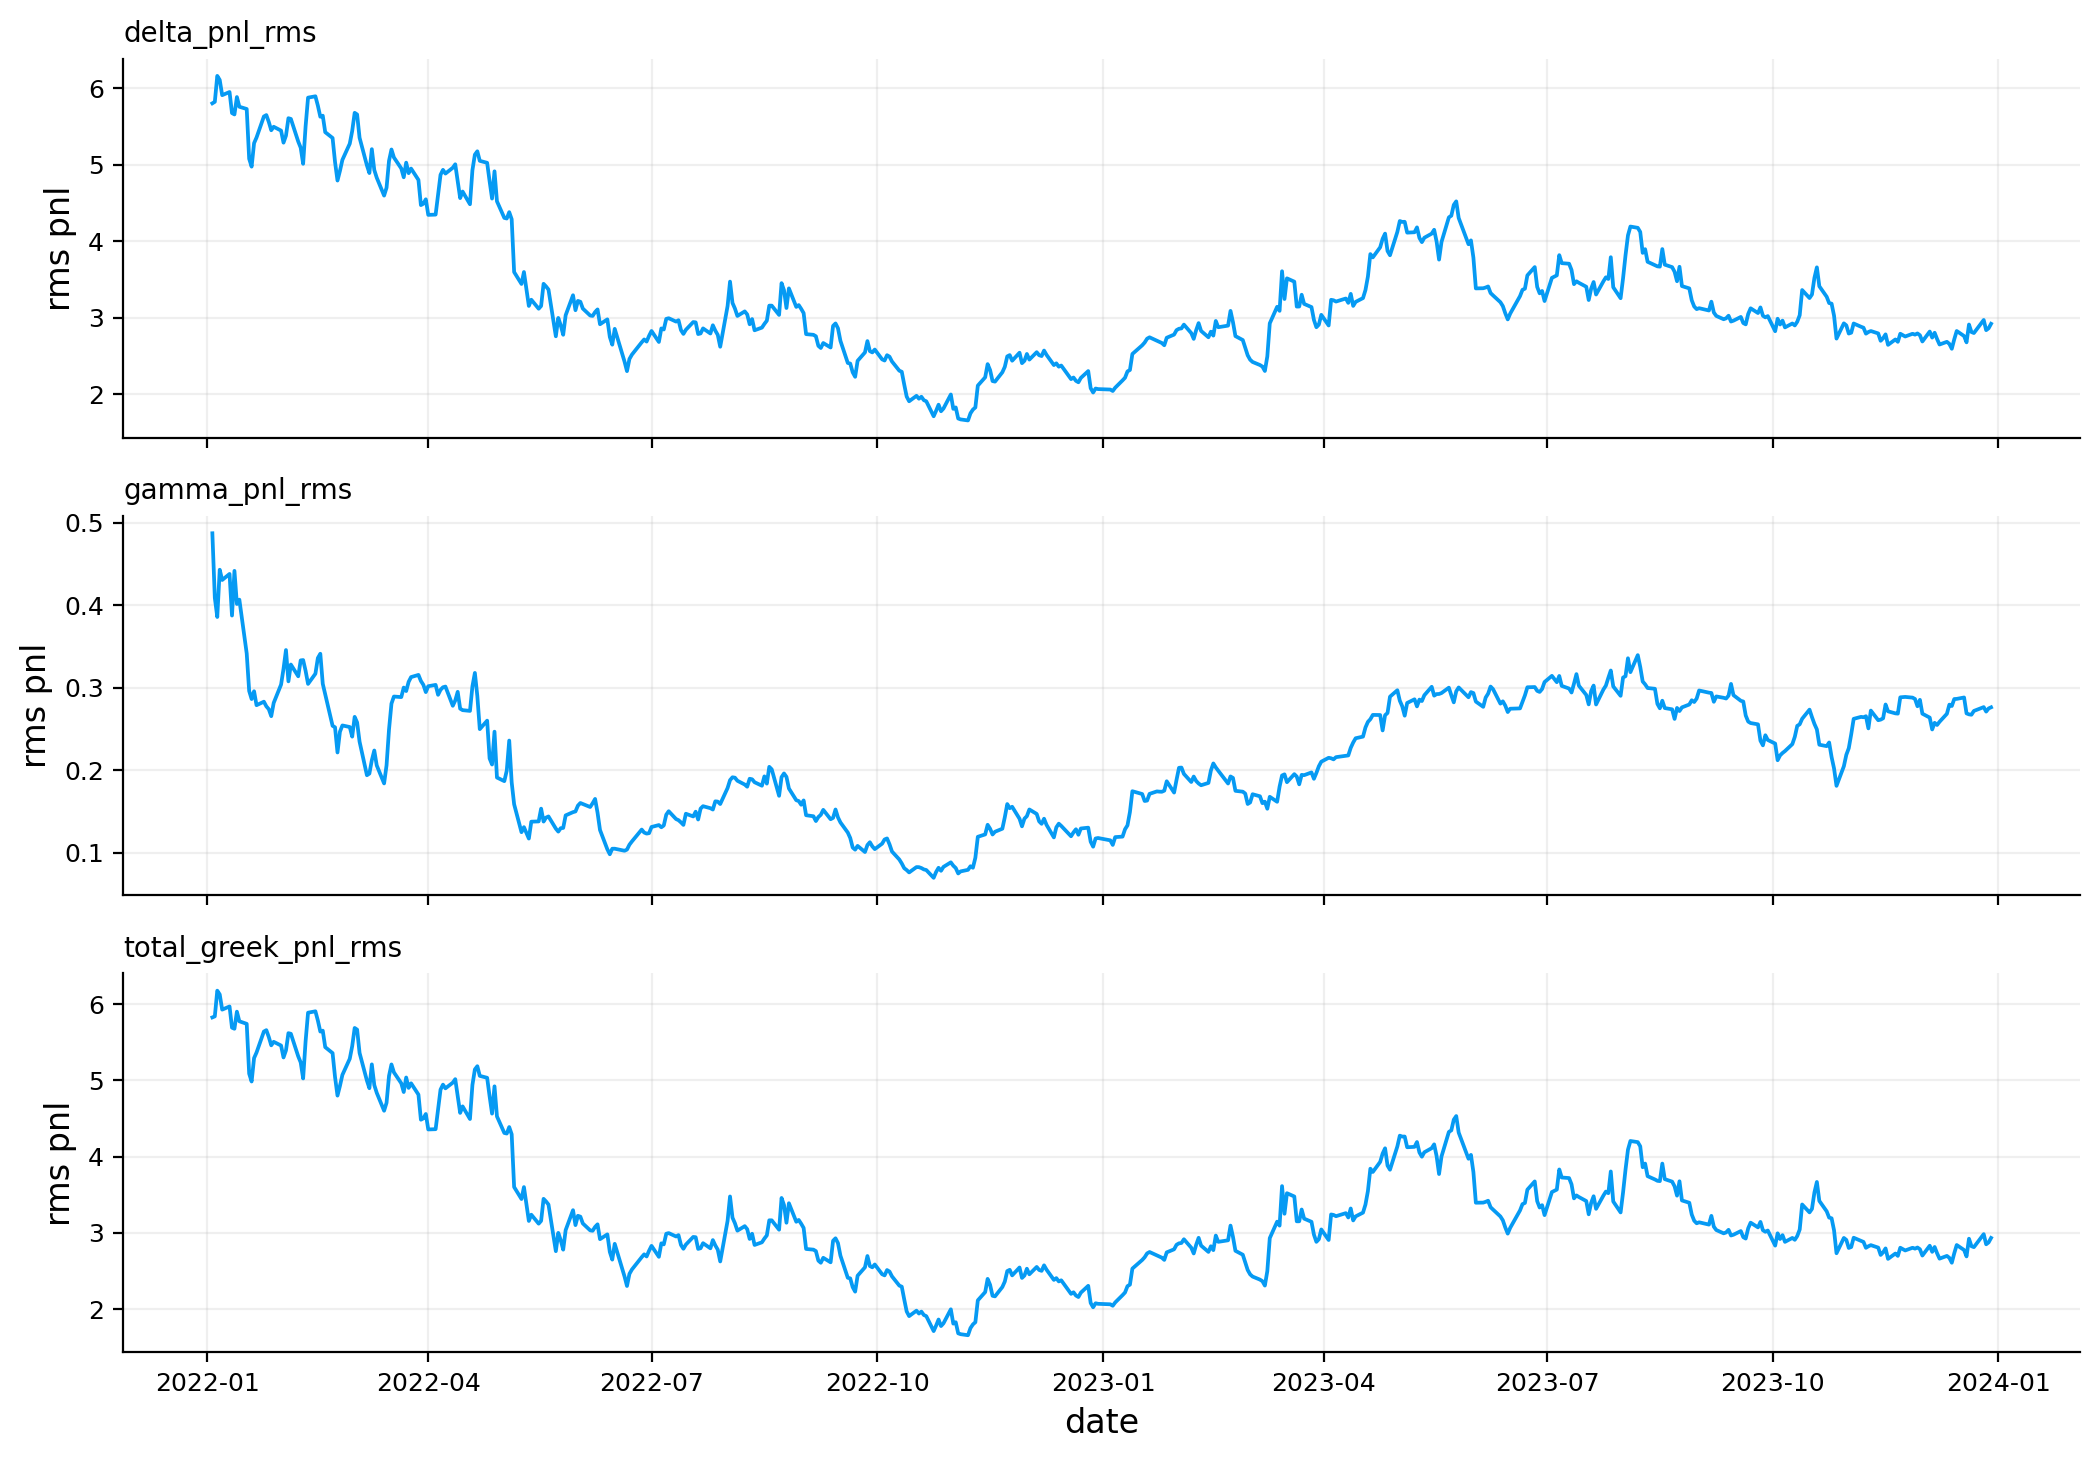

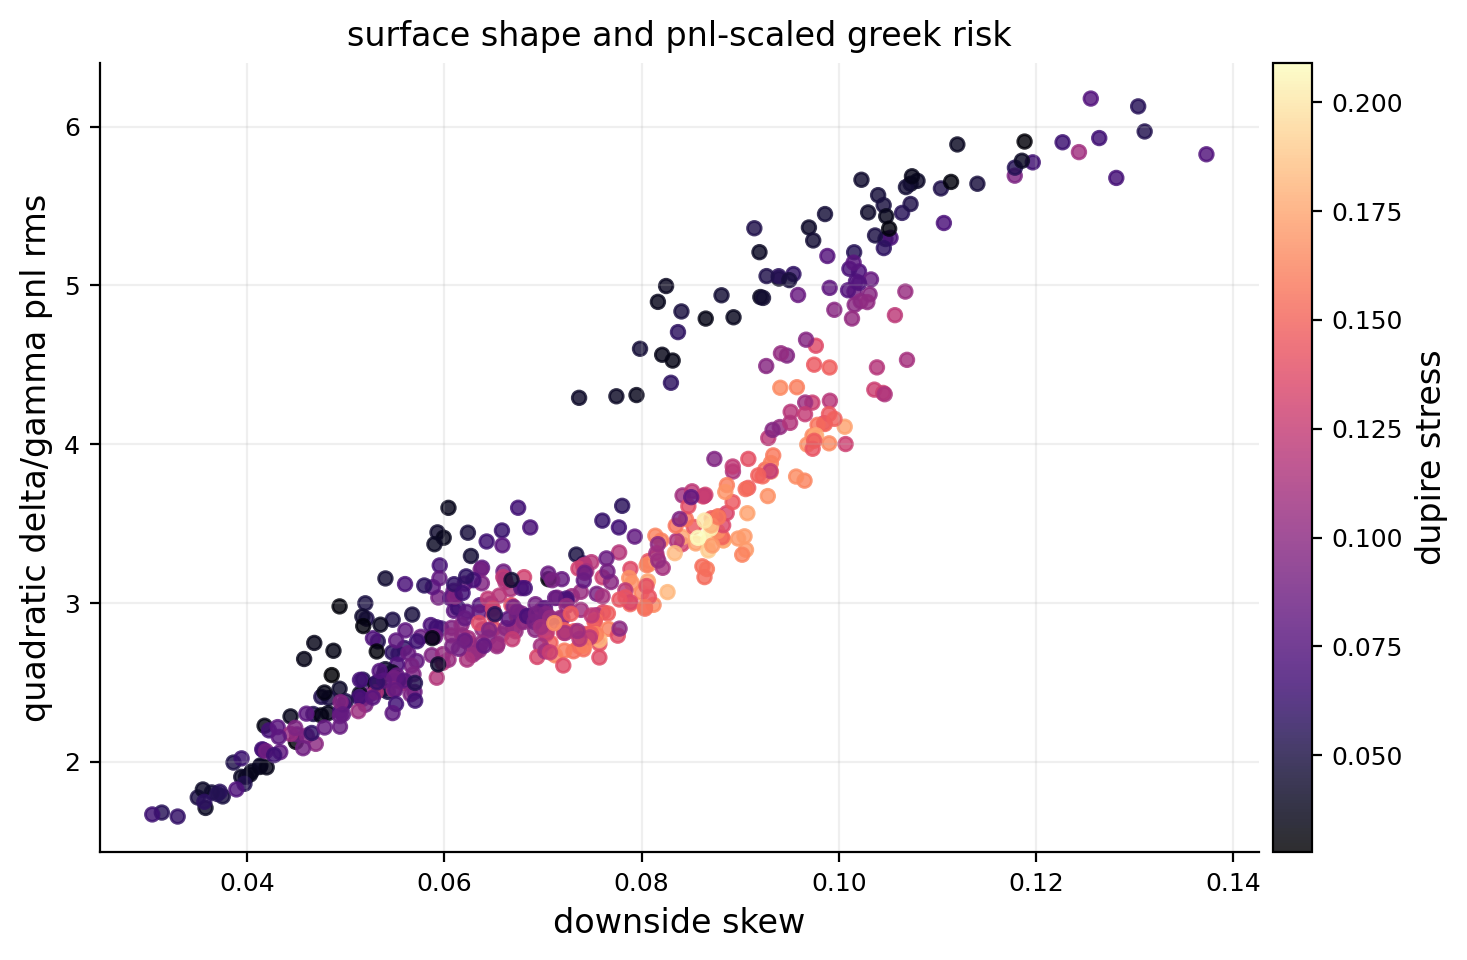

In [43]:
fig, axes = plt.subplots(3, 1, figsize=(10.6, 7.4), sharex=True)
for ax, col in zip(axes, ["delta_pnl_rms", "gamma_pnl_rms", "total_greek_pnl_rms"]):
    ax.plot(features["date"], features[col], lw=1.35)
    ax.set_title(col, loc="left", fontsize=10)
    ax.set_ylabel("rms pnl")
axes[-1].set_xlabel("date")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.6, 4.9))
sc = ax.scatter(features["downside_skew"], features["total_greek_pnl_rms"], c=features["dupire_stress"], cmap="magma", s=24, alpha=0.82)
ax.set_title("surface shape and pnl-scaled greek risk")
ax.set_xlabel("downside skew")
ax.set_ylabel("quadratic delta/gamma pnl rms")
fig.colorbar(sc, ax=ax, pad=0.01, label="dupire stress")
plt.tight_layout()
plt.show()


Main BTC date: 2024-03-22
Surface quotes: 120,736
Main-date quotes: 1,017
Main-date expiries: 6
Dupire engine used: jax | fallback: False
Greek engine used: jax | fallback: False


,step,rows,removed
0,raw rows,258234,NaN
1,after schema normalization,258234,0.000000
2,after positive price filter,218710,"39,524.000000"
3,after bid/ask/spread filter,196404,"22,306.000000"
4,after DTE filter,136262,"60,142.000000"
5,after moneyness filter,121361,"14,901.000000"
6,after ATM-pair selection,121361,0.000000
7,final rows,121361,0.000000


,fit,target,quote_count,number_of_maturities,rmse,weighted_rmse,mae,median_abs_error,p95_abs_error,mean_residual,residual_std,k_min,k_max,tau_min,tau_max
0,visual,log_total_variance,1017,6,0.039618,0.014408,0.020157,0.007912,0.078626,-0.005679,0.039209,-0.790376,0.544048,0.019178,0.268493
1,dupire,log_total_variance,1017,6,0.054246,0.025125,0.028772,0.014524,0.097726,0.003833,0.054111,-0.790376,0.544048,0.019178,0.268493


,comparison,finite_nodes,rmse,mae,median_abs_error
0,pchip_minus_spline_grid,2269,0.042287,0.021973,0.008692


,engine_used,fallback_used,dupire_hard_invalid_share,dupire_hard_invalid_other_share,dupire_extreme_ratio_share,dupire_total_flagged_share,dupire_negative_density_share,dupire_median_lv_to_iv,dupire_median_abs_lv_to_iv_minus_1,dupire_atm_local_vol_level,dupire_downside_local_vol_premium,dupire_upside_local_vol_premium,dupire_stress,date
0,jax,False,0.000000,0.000000,0.000000,0.000000,0.000000,1.015329,0.029048,0.772270,-0.019242,NaN,0.014524,2024-03-22


,date,timestamp,expiry,strike,option_type,underlying,instrument_name,spot,bid,ask,mid,volume,open_interest,iv,delta,gamma,vega,theta,rho,quote_profile,quote_unixtime,quote_readtime,quote_date,quote_time_hours,base_currency,contract_size,underlying_index,underlying_price,expiry_date,expiry_unix,expiry_time,dte,option_right,bid_size,bid_price,ask_price,ask_size,mark_iv,strike_distance_pct,source_file,spread,half_spread,rel_spread,tau,dte_calendar,k_over_s,liq_score,bid_raw,ask_raw,mid_raw,valuation_currency,price_unit_detected,moneyness,log_moneyness,rate,discount_factor,forward,implied_carry,n_pairs,parity_error_median,parity_error_mad,parity_error_iqr,implied_dividend_yield,source_index,iv_bid,iv_bid_status,iv_bid_success,iv_bid_iters,iv_bid_abs_price_error,iv_mid,iv_mid_status,iv_mid_success,iv_mid_iters,iv_mid_abs_price_error,iv_ask,iv_ask_status,iv_ask_success,iv_ask_iters,iv_ask_abs_price_error,iv_success,iv_status,iv_failure_reason,iv_iterations,iv_solver,solver,engine_used,relative_spread,k,k_spot,total_variance,log_total_variance,iv_uncertainty,surface_weight,dte_days,fit_iv_visual,residual_visual,abs_residual_visual,fit_iv_dupire,residual_dupire,abs_residual_dupire
31133,2024-03-22,2024-03-22,2024-03-29,"31,000.000000",call,BTC,BTC-29MAR24-31000-C,"66,121.260000","35,011.207170","35,242.631580","35,126.919375",0.000000,287.200000,1.535600,0.999860,0.000000,0.051280,-0.549320,6.085390,spx_optiondx,1711080058,2024-03-22 00:00,2024-03-22,0.000000,BTC,1.000000,BTC-29MAR24,"66,121.260000",2024-03-29,1711699200,4.000000,7.166000,call,70.000000,0.529500,0.533000,9.000000,153.560000,0.530230,btc_eod_202403.txt,231.424410,115.712205,0.006588,0.019178,7.000000,0.468836,0.996512,0.529500,0.533000,0.531250,USD,base,0.468836,-0.757503,0.055100,0.998944,"66,126.770974",0.004346,144.000000,1.876799,20.297190,41.421650,0.050754,31409,NaN,bounds_violation,False,0,NaN,2.270666,ok,True,5,0.000000,2.763389,ok,True,5,0.000000,True,ok,,5,lbr_lite,lbr_lite,numba,0.006588,-0.757586,-0.757503,0.098881,-2.313841,0.500000,0.259436,7.000000,2.666842,-0.396175,0.396175,2.784099,-0.513432,0.513432
31530,2024-03-22,2024-03-22,2024-04-26,"32,000.000000",put,BTC,BTC-26APR24-32000-P,"67,247.480000",60.522732,80.696976,70.609854,0.100000,373.200000,1.076700,-0.008440,0.000000,4.796660,-7.342710,-0.614720,spx_optiondx,1711080058,2024-03-22 00:00,2024-03-22,0.000000,BTC,1.000000,BTC-26APR24,"67,247.480000",2024-04-26,1714118400,4.000000,35.166000,put,8.000000,0.000900,0.001200,2.600000,107.670000,0.514740,btc_eod_202403.txt,20.174244,10.087122,0.285714,0.095890,35.000000,0.475854,0.999700,0.000900,0.001200,0.001050,USD,base,0.475854,-0.742644,0.055040,0.994736,"67,319.424765",0.011151,232.000000,7.128364,67.707528,130.449061,0.043889,31807,1.059710,ok,True,7,0.000000,1.081886,ok,True,7,0.000000,1.102034,ok,True,7,0.000000,True,ok,,7,lbr_lite,lbr_lite,numba,0.285714,-0.743713,-0.742644,0.112238,-2.187137,0.042324,0.050000,35.000000,1.348471,-0.266584,0.266584,1.296514,-0.214628,0.214628
31529,2024-03-22,2024-03-22,2024-04-26,"32,000.000000",put,BTC,BTC-26APR24-32000-P,"67,277.720000",60.549948,80.733264,70.641606,0.100000,373.200000,1.076700,-0.008410,0.000000,4.784060,-7.323390,-0.612830,spx_optiondx,1711080000,2024-03-22 00:00,2024-03-22,0.000000,BTC,1.000000,BTC-26APR24,"67,277.720000",2024-04-26,1714118400,4.000000,35.166670,put,8.000000,0.000900,0.001200,2.600000,107.670000,0.515060,btc_eod_202403.txt,20.183316,10.091658,0.285714,0.095890,35.000000,0.475640,0.999700,0.000900,0.001200,0.001050,USD,base,0.475640,-0.743093,0.055040,0.994736,"67,319.424765",0.006463,232.000000,7.128364,67.707528,130.449061,0.048577,31806,1.059773,ok,True,7,0.000000,1.081953,ok,True,7,0.000000,1.102103,ok,True,7,0.000000,True,ok,,7,lbr_lite,lbr_lite,numba,0.285714,-0.743713,-0.743093,0.112251,-2.187014,0.042330,0.050000,35.000000,1.348471,-0.266518,0.266518,1.296514,-0.214562,0.214562
31925,2024-03-22,2024-03-22,2024-05-31,"81,000.000000",put,BTC,BTC-31MAY24-81000-P,"68,40

,component,explained_variance_ratio,cumulative,score_std
0,pc1,0.900930,0.900930,0.629989
1,pc2,0.057782,0.958711,0.159545
2,pc3,0.021243,0.979954,0.096737
3,pc4,0.010478,0.990432,0.067941
4,pc5,0.004472,0.994905,0.044387


,delta_pnl_rms,gamma_pnl_rms,total_greek_pnl_rms,max_abs_delta_diff,max_abs_gamma_diff,date,engine_used,fallback_used
82,12.850974,0.416707,12.857728,0.048419,0.000003,2024-03-23,jax,False
113,12.502290,0.271610,12.505240,0.027006,0.000003,2024-04-24,jax,False
80,12.092735,0.364658,12.098232,0.039546,0.000002,2024-03-21,jax,False
199,11.896896,0.347750,11.901977,0.035351,0.000003,2024-07-23,jax,False
197,11.830294,0.367231,11.835992,0.039519,0.000003,2024-07-21,jax,False
83,11.797568,0.366499,11.803259,0.042158,0.000003,2024-03-24,jax,False
11,11.655403,0.341945,11.660418,0.036361,0.000007,2024-01-12,jax,False
62,11.589639,0.395191,11.596375,0.047880,0.000003,2024-03-03,jax,False
68,11.517260,0.389115,11.523832,0.043309,0.000002,2024-03-09,jax,False
196,11.508096,0.387951,11.514634,0.038803,0.000004,2024-07-20,jax,False


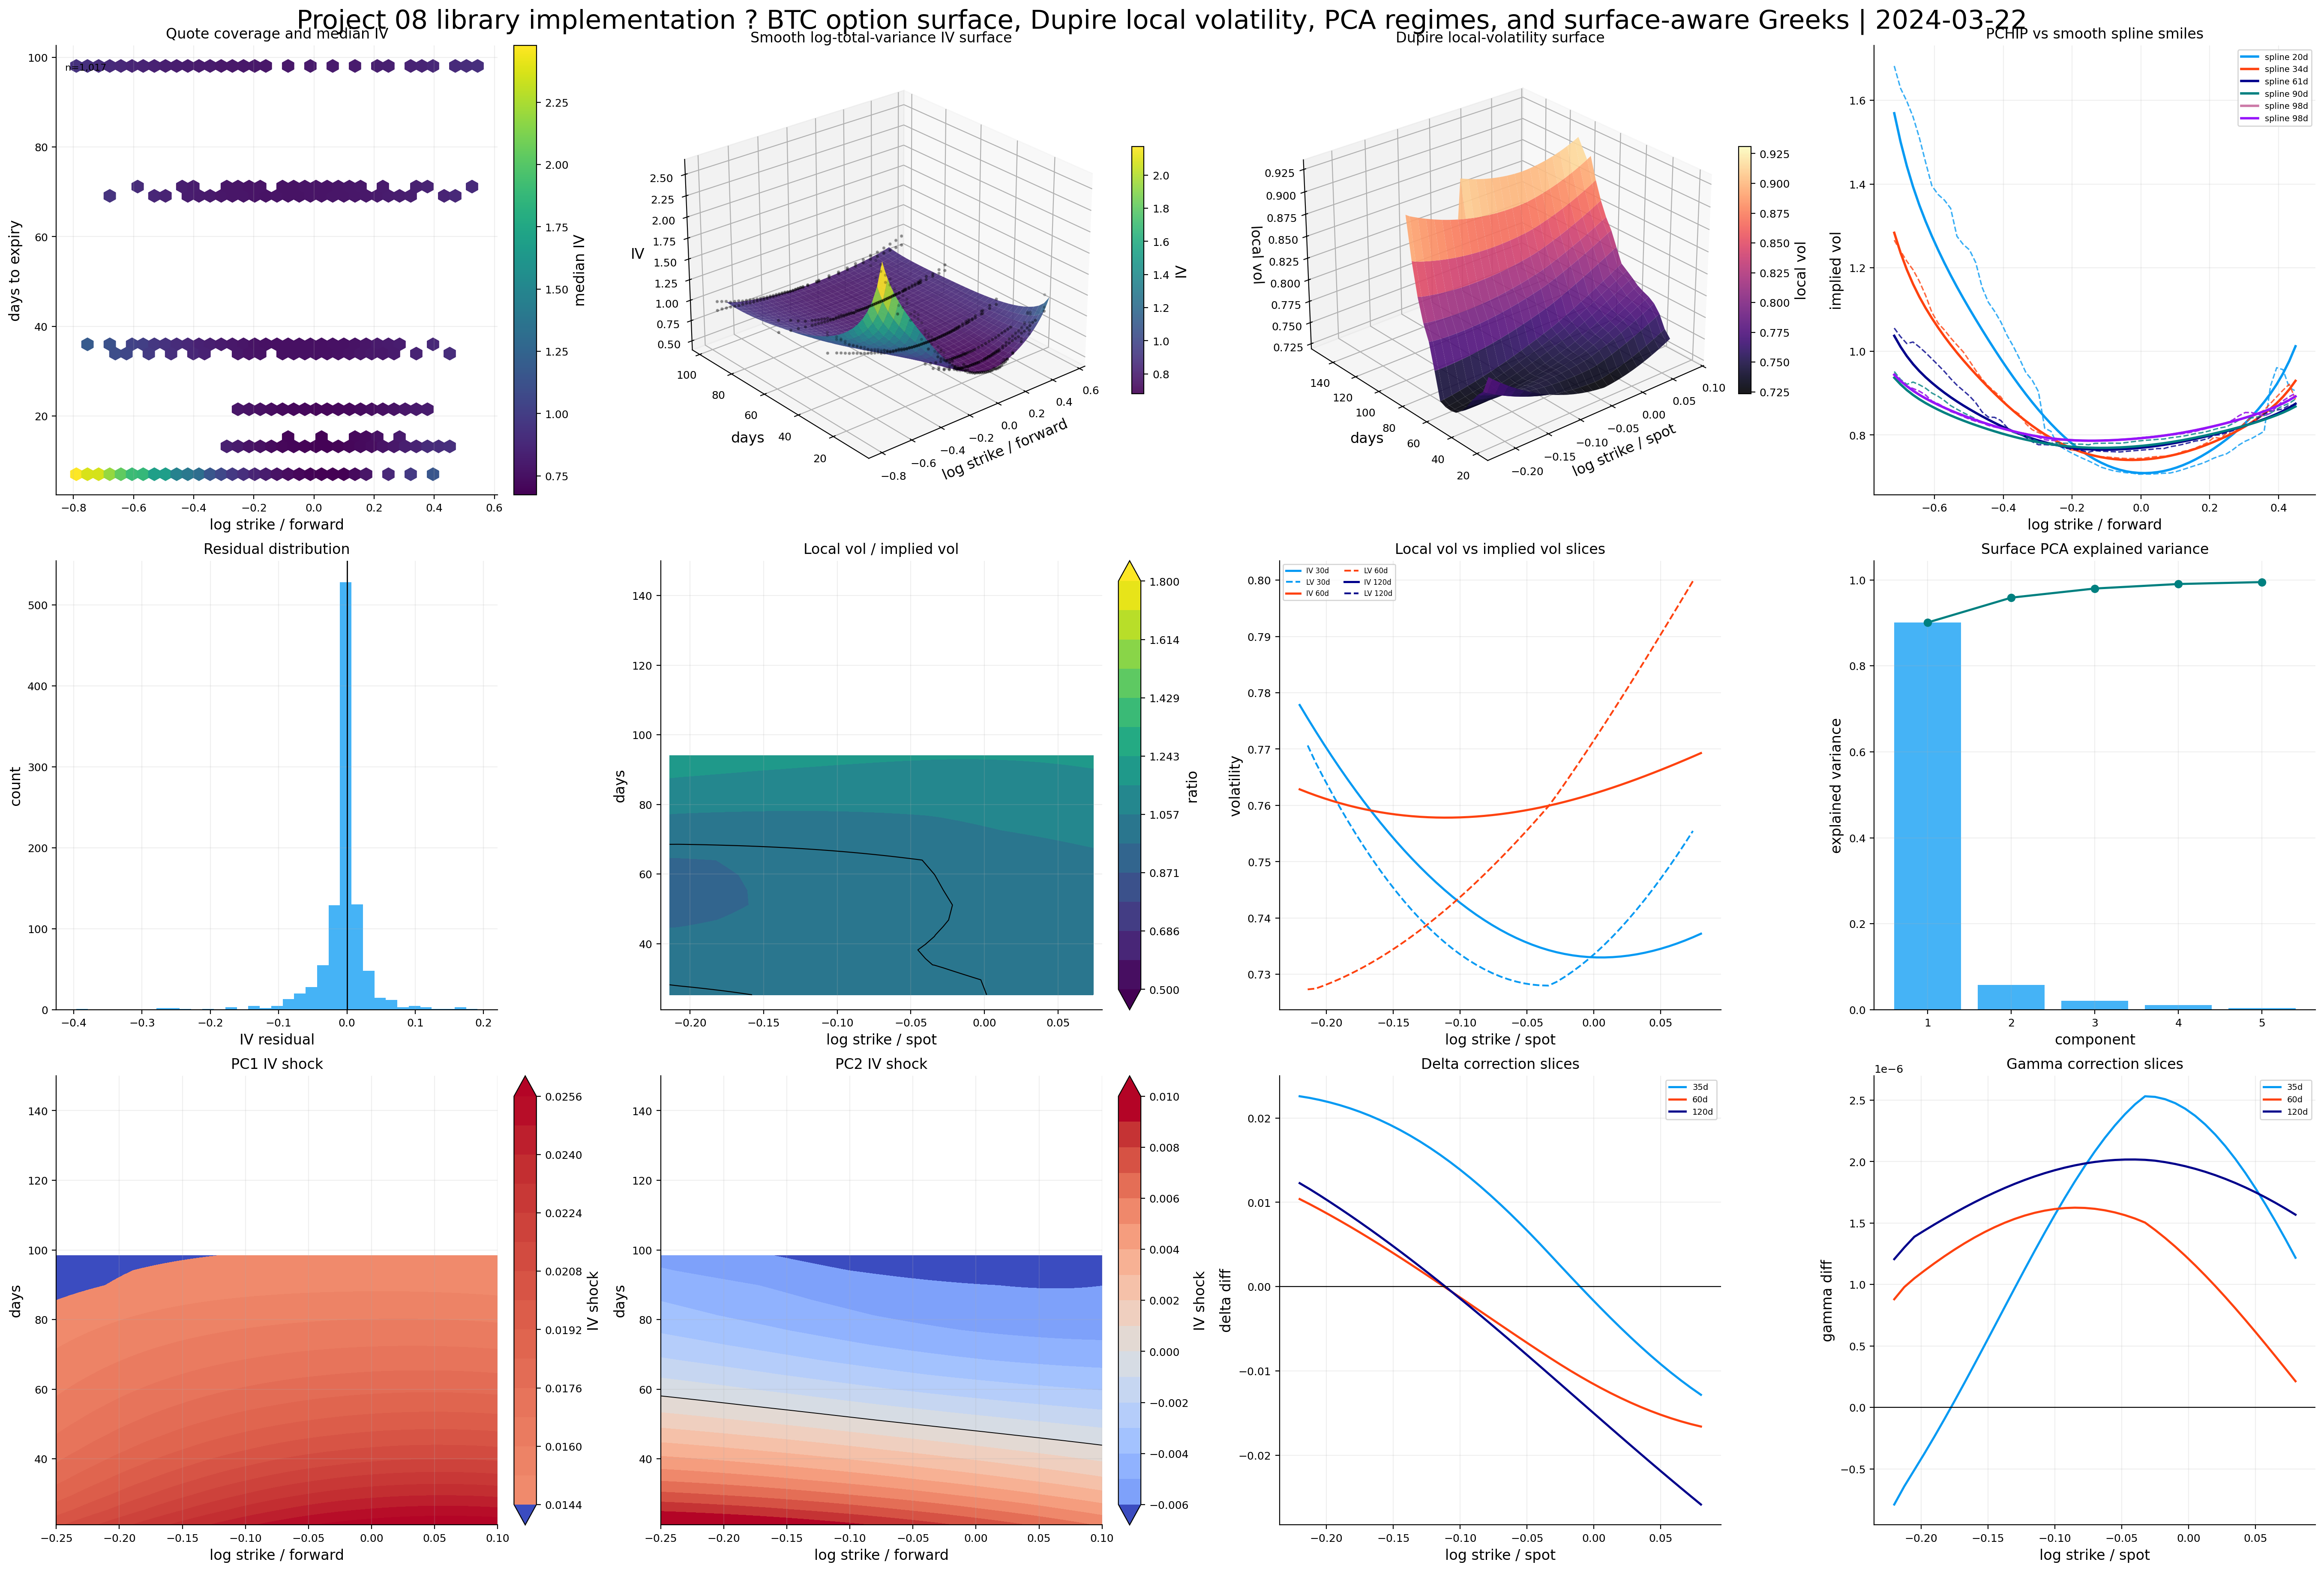

In [44]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import jax
    jax.config.update("jax_enable_x64", True)
except Exception:
    jax = None

from quantfinlab.dataio.equity_ohlcv import load_ohlcv
from quantfinlab.dataio.option_chain import load_option_chain
from quantfinlab.dataio.rates import load_par_yield_curve

from quantfinlab.options.quote_cleaning import (
    attach_spot_from_series,
    clean_option_quotes,
    convert_quotes_to_usd_equivalent,
    surface_ready_quotes,
)
from quantfinlab.options.parity import infer_forwards_from_parity
from quantfinlab.options.rates_dividends import (
    attach_rates,
    add_discount_factors,
    infer_carry_from_forward,
    infer_dividend_yield_from_forward,
)
from quantfinlab.options.iv import implied_vol_table
from quantfinlab.options.surface import (
    surface_grid,
    common_surface_grid,
    fit_surface_panel,
    surface_iv_grid,
    pchip_surface,
    pchip_spline_comparison,
    surface_fit_summary,
    surface_residuals,
    surface_cube,
    surface_pca,
    surface_pca_shocks,
    surface_features,
)
from quantfinlab.options.local_vol import (
    dupire_grid,
    dupire_stress_summary,
    dupire_stress_panel,
)
from quantfinlab.options.greeks import (
    surface_delta_gamma_grid,
    surface_greek_risk_panel,
)
from quantfinlab.plotting.options import (
    quote_coverage_map,
    smooth_surface_3d,
    local_vol_surface_3d,
    smile_slices_comparison,
    residual_histogram,
    local_vol_ratio_map,
    local_vol_slices,
    pca_variance_bars,
    pca_shock_map,
    delta_correction_slices,
    gamma_correction_slices,
)

ann_days = 365.25
random_state = 7
data_dir = Path("../data")
if not data_dir.exists():
    data_dir = Path("data")

btc_spot = load_ohlcv(
    data_dir / "btc_usd_ohlcv.csv",
    source="yfinance_csv",
    fields=("close",),
)

quotes = load_option_chain(
    data_dir / "btc_options_chain.parquet",
    source="btc_deribit",
    annualization_days=365.0,
)

us_par = load_par_yield_curve(
    data_dir / "us_treasury_yields.csv",
    source="us_treasury",
)

quotes = attach_spot_from_series(
    quotes,
    btc_spot["close"],
    date_col="date",
    spot_col="spot",
    method="previous",
    overwrite=False,
)
quotes = convert_quotes_to_usd_equivalent(quotes, unit="auto")

clean_quotes, clean_report = clean_option_quotes(
    quotes,
    min_dte=3,
    max_dte=180,
    moneyness_range=(0.45, 1.75),
    max_relative_spread=0.60,
    closest_atm_pairs=None,
    min_pairs_per_expiry=0,
    annualization_days=365.0,
)

rate_start = clean_quotes["date"].min() - pd.Timedelta(days=30)
rate_end = clean_quotes["date"].max()
us_par = us_par.loc[(us_par.index >= rate_start) & (us_par.index <= rate_end)].copy()

clean_quotes = attach_rates(
    clean_quotes,
    us_par,
    date_col="date",
    tau_col="tau",
    out_col="rate",
)
clean_quotes = add_discount_factors(
    clean_quotes,
    rate_col="rate",
    tau_col="tau",
    out_col="discount_factor",
)

clean_quotes = infer_forwards_from_parity(
    clean_quotes,
    date_col="date",
    expiry_col="expiry",
    strike_col="strike",
    option_type_col="option_type",
    mid_col="mid",
    discount_col="discount_factor",
    spot_col="spot",
    out_col="forward",
)

clean_quotes = infer_carry_from_forward(
    clean_quotes,
    spot_col="spot",
    forward_col="forward",
    tau_col="tau",
    out_col="implied_carry",
)
clean_quotes = infer_dividend_yield_from_forward(
    clean_quotes,
    rate_col="rate",
    carry_col="implied_carry",
    out_col="implied_dividend_yield",
)

iv_quotes = implied_vol_table(
    clean_quotes,
    price_cols=("bid", "mid", "ask"),
    option_type_col="option_type",
    spot_col="spot",
    forward_col="forward",
    strike_col="strike",
    tau_col="tau",
    rate_col="rate",
    discount_col="discount_factor",
    model="black76",
    engine="auto",
)

surface_quotes = surface_ready_quotes(
    iv_quotes,
    min_iv=0.05,
    max_iv=3.50,
    min_tau=3 / 365.0,
    max_tau=180 / 365.0,
    min_weight=0.05,
    max_weight=20.0,
)

main_date = surface_quotes.groupby("date").size().sort_values(ascending=False).index[0]
q_main = surface_quotes.loc[surface_quotes["date"].eq(main_date)].copy()

visual_params = dict(n_k_basis=12, n_tau_basis=8, degree=3, lambda_k=3.0, lambda_tau=2.0)
dupire_params = dict(n_k_basis=10, n_tau_basis=7, degree=3, lambda_k=12.0, lambda_tau=20.0)

fit_panel = fit_surface_panel(
    surface_quotes,
    date_col="date",
    k_col="k",
    tau_col="tau",
    iv_col="iv_mid",
    weight_col="surface_weight",
    visual_params=visual_params,
    dupire_params=dupire_params,
    min_quotes=100,
    min_expiries=4,
)

visual_fits = fit_panel["visual_fits"]
dupire_fits = fit_panel["dupire_fits"]
fit_visual = visual_fits[pd.Timestamp(main_date).normalize()]
fit_dupire = dupire_fits[pd.Timestamp(main_date).normalize()]

main_grid = surface_grid(
    q_main,
    k_col="k",
    tau_col="tau",
    k_quantiles=(0.02, 0.98),
    tau_quantiles=(0.02, 0.98),
    n_k=65,
    n_tau=35,
    annualization_days=ann_days,
)

common_grid = common_surface_grid(
    surface_quotes,
    date_col="date",
    k_col="k",
    tau_col="tau",
    k_min=-0.25,
    k_max=0.10,
    tau_min=21 / ann_days,
    tau_max=150 / ann_days,
    n_k=61,
    n_tau=31,
    min_support_share=0.85,
    annualization_days=ann_days,
)

iv_visual_grid = surface_iv_grid(fit_visual, main_grid)
iv_dupire_grid = surface_iv_grid(fit_dupire, main_grid)

pchip_grid = pchip_surface(
    q_main,
    grid=main_grid,
    k_col="k",
    tau_col="tau",
    iv_col="iv_mid",
)

pchip_cmp = pchip_spline_comparison(
    q_main,
    fit=fit_visual,
    grid=main_grid,
    k_col="k",
    tau_col="tau",
    iv_col="iv_mid",
    weight_col="surface_weight",
)

fit_summary = surface_fit_summary(
    q_main,
    fits={"visual": fit_visual, "dupire": fit_dupire},
    k_col="k",
    tau_col="tau",
    iv_col="iv_mid",
    weight_col="surface_weight",
)

residuals = surface_residuals(
    q_main,
    fits={"visual": fit_visual, "dupire": fit_dupire},
    k_col="k",
    tau_col="tau",
    iv_col="iv_mid",
)

lv_main = dupire_grid(
    fit_dupire,
    q_main,
    k_min=-0.22,
    k_max=0.08,
    tau_min=21 / ann_days,
    tau_max=150 / ann_days,
    n_k=51,
    n_tau=31,
    max_local_vol=2.50,
    ratio_bounds=(0.50, 1.80),
    annualization_days=ann_days,
    engine="jax",
    fallback=True,
)

lv_summary = dupire_stress_summary(lv_main)

lv_panel = dupire_stress_panel(
    surface_quotes,
    fits=dupire_fits,
    date_col="date",
    k_col="k",
    tau_col="tau",
    k_min=-0.22,
    k_max=0.08,
    tau_min=21 / ann_days,
    tau_max=150 / ann_days,
    n_k=51,
    n_tau=31,
    annualization_days=ann_days,
    engine="jax",
    fallback=True,
)

cube = surface_cube(
    surface_quotes,
    fits=visual_fits,
    grid=common_grid,
    date_col="date",
    output="iv",
)

pca = surface_pca(
    cube,
    n_components=5,
    mode="level_and_shape",
    standardize=False,
    random_state=random_state,
)

pca_shocks = surface_pca_shocks(
    pca,
    grid=common_grid,
    components=(1, 2, 3),
    output_units="iv_points",
)

features = surface_features(cube, pca).merge(lv_panel, on="date", how="left")

greek_main = surface_delta_gamma_grid(
    fit_dupire,
    q_main,
    k_min=-0.22,
    k_max=0.08,
    n_k=41,
    tau_days=np.array([21, 35, 60, 90, 120, 150], dtype=float),
    spot_shock=0.01,
    annualization_days=ann_days,
    engine="jax",
    fallback=True,
)

greek_panel = surface_greek_risk_panel(
    surface_quotes,
    fits=dupire_fits,
    date_col="date",
    k_min=-0.22,
    k_max=0.08,
    n_k=41,
    tau_days=np.array([21, 35, 60, 90, 120, 150], dtype=float),
    spot_shock=0.01,
    annualization_days=ann_days,
    engine="jax",
    fallback=True,
)

print(f"Main BTC date: {pd.Timestamp(main_date).date()}")
print(f"Surface quotes: {len(surface_quotes):,}")
print(f"Main-date quotes: {len(q_main):,}")
print(f"Main-date expiries: {q_main['expiry'].nunique():,}")
print(f"Dupire engine used: {lv_main['engine_used']} | fallback: {lv_main['fallback_used']}")
print(f"Greek engine used: {greek_main.attrs.get('engine_used', 'unknown')} | fallback: {greek_main.attrs.get('fallback_used', False)}")

display(clean_report)
display(fit_summary)
display(pchip_cmp)
display(pd.DataFrame([lv_summary]).assign(date=pd.Timestamp(main_date)))
display(residuals.sort_values("abs_residual_visual", ascending=False).head(10))
display(pca["explained_variance_table"])
display(greek_panel.sort_values("total_greek_pnl_rms", ascending=False).head(10))

fig = plt.figure(figsize=(27, 18), constrained_layout=True)
gs = fig.add_gridspec(3, 4)

ax_quote = fig.add_subplot(gs[0, 0])
ax_smooth3d = fig.add_subplot(gs[0, 1], projection="3d")
ax_lv3d = fig.add_subplot(gs[0, 2], projection="3d")
ax_smiles = fig.add_subplot(gs[0, 3])

ax_resid_hist = fig.add_subplot(gs[1, 0])
ax_lv_ratio = fig.add_subplot(gs[1, 1])
ax_lv_slices = fig.add_subplot(gs[1, 2])
ax_pca_var = fig.add_subplot(gs[1, 3])

ax_pc1 = fig.add_subplot(gs[2, 0])
ax_pc2 = fig.add_subplot(gs[2, 1])
ax_delta_slices = fig.add_subplot(gs[2, 2])
ax_gamma_slices = fig.add_subplot(gs[2, 3])

quote_coverage_map(ax_quote, q_main, k_col="k", tau_col="tau", iv_col="iv_mid", title="Quote coverage and median IV")
smooth_surface_3d(ax_smooth3d, grid=main_grid, iv_grid=iv_visual_grid, quotes=q_main, k_col="k", tau_col="tau", iv_col="iv_mid", title="Smooth log-total-variance IV surface", quote_sample=2500, random_state=random_state)
local_vol_surface_3d(ax_lv3d, lv_main, x_col="k_spot", z_col="local_vol", title="Dupire local-volatility surface", cap_quantile=0.98)
smile_slices_comparison(ax_smiles, grid=main_grid, pchip_grid=pchip_grid, spline_grid=iv_visual_grid, maturities_days=(21, 35, 60, 90, 120, 150), title="PCHIP vs smooth spline smiles")
residual_histogram(ax_resid_hist, residuals, residual_col="residual_visual", title="Residual distribution")
local_vol_ratio_map(ax_lv_ratio, lv_main, x_col="k_spot", title="Local vol / implied vol", ratio_bounds=(0.50, 1.80))
local_vol_slices(ax_lv_slices, lv_main, x_col="k_spot", maturities_days=(30, 60, 120), title="Local vol vs implied vol slices")
pca_variance_bars(ax_pca_var, pca, title="Surface PCA explained variance")
pca_shock_map(ax_pc1, pca_shocks, component=1, title="PC1 IV shock")
pca_shock_map(ax_pc2, pca_shocks, component=2, title="PC2 IV shock")
delta_correction_slices(ax_delta_slices, greek_main, x_col="k_spot", maturities_days=(30, 60, 120), title="Delta correction slices")
gamma_correction_slices(ax_gamma_slices, greek_main, x_col="k_spot", maturities_days=(30, 60, 120), title="Gamma correction slices")

fig.suptitle(
    f"Project 08 library implementation ? BTC option surface, Dupire local volatility, PCA regimes, and surface-aware Greeks | {pd.Timestamp(main_date).date()}",
    fontsize=22,
    y=1.01,
)
plt.show()
